In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from datetime import datetime
import warnings
import time
import os
import akshare as ak
import pandas as pd
from pathlib import Path
import sys
from torchviz import make_dot
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from itertools import combinations
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
import seaborn as sns
import json
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from typing import List, Tuple, Dict
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.neural_network import MLPRegressor

# Data Acquisition

In [2]:
import warnings
warnings.filterwarnings('ignore')

import time
from datetime import datetime
import pandas as pd
import numpy as np


VERBOSE = False
PRINT_PROGRESS = True


def _log(msg):
    if VERBOSE:
        print(msg)


def _progress(msg):
    if PRINT_PROGRESS:
        print(msg)


STOCKS = {
    '300308': '中际旭创',
    '300502': '新易盛',
    '300476': '胜宏科技',
    '300394': '天孚通信',
    '301308': '江波龙',
    '300474': '景嘉微'
}

END_DATE = datetime(2025, 11, 7)
START_DATE = datetime(2022, 9, 1)

if PRINT_PROGRESS:
    print(f"时间范围: {START_DATE.strftime('%Y-%m-%d')} 至 {END_DATE.strftime('%Y-%m-%d')}")


class IntegratedDataFetcher:
    def __init__(self, use_jq=False, jq_username=None, jq_password=None):
        self.ak = None
        self.jq = None
        self.jq_available = False
        try:
            import akshare as ak
            self.ak = ak
            _log(f"Akshare 版本: {ak.__version__}")
        except ImportError:
            if PRINT_PROGRESS:
                print("未安装 akshare：pip install akshare")
            # 让错误在 main() 的 try/except 中统一处理
            raise

        if use_jq:
            try:
                import jqdatasdk as jq
                self.jq = jq
                self.jq.auth(jq_username, jq_password)
                remaining = self.jq.get_query_count()
                if remaining:
                    self.jq_available = True
                    _log(f"JQ 可用，剩余查询: {remaining.get('spare', 0)}")
            except Exception:
                # 静默失败，不输出错误
                self.jq_available = False

    def _ak_call_with_retry(self, func, *args, **kwargs):
        delays = [1, 3, 6]
        last_exc = None
        for i, d in enumerate(delays, start=1):
            try:
                return func(*args, **kwargs)
            except Exception as e:
                last_exc = e
                _log(f"Ak 调用失败({i}/{len(delays)}): {e}; {d}s后重试…")
                time.sleep(d)
        # 最终失败：静默返回 None
        return None

    def get_stock_hist_ak(self, stock_code):
        start = START_DATE.strftime('%Y%m%d')
        end = END_DATE.strftime('%Y%m%d')
        df_qfq = self._ak_call_with_retry(
            self.ak.stock_zh_a_hist,
            symbol=stock_code,
            period="daily",
            start_date=start,
            end_date=end,
            adjust="qfq",
        )
        df_hfq = self._ak_call_with_retry(
            self.ak.stock_zh_a_hist,
            symbol=stock_code,
            period="daily",
            start_date=start,
            end_date=end,
            adjust="hfq",
        )
        df_raw = self._ak_call_with_retry(
            self.ak.stock_zh_a_hist,
            symbol=stock_code,
            period="daily",
            start_date=start,
            end_date=end,
            adjust="",
        )
        if df_qfq is None or df_hfq is None or df_raw is None:
            return None

        def _norm(df):
            d = df.rename(
                columns={
                    '日期': 'date',
                    '开盘': 'open',
                    '收盘': 'close',
                    '最高': 'high',
                    '最低': 'low',
                    '成交量': 'volume',
                    '成交额': 'amount',
                    '涨跌幅': 'pct_chg',
                    '换手率': 'turnover',
                }
            ).copy()
            d['date'] = pd.to_datetime(d['date'])
            return d

        qfq, hfq, raw = map(_norm, (df_qfq, df_hfq, df_raw))
        base = qfq[['date', 'open', 'high', 'low', 'close', 'volume', 'amount', 'pct_chg', 'turnover']].copy()
        base['close_hfq'] = hfq['close'].values
        base['close_original'] = raw['close'].values
        base['adj_factor'] = base['close'] / base['close_original']
        base['adj_factor_hfq'] = base['close_hfq'] / base['close_original']
        return base

    def get_stock_hist_jq(self, stock_code):
        if not self.jq_available:
            return None
        jq_code = f"{stock_code}.XSHE"
        start = START_DATE.strftime('%Y-%m-%d')
        end = END_DATE.strftime('%Y-%m-%d')
        try:
            fields = ['open', 'close', 'high', 'low', 'volume', 'money']
            pre = self.jq.get_price(jq_code, start_date=start, end_date=end, frequency='daily', fields=fields, fq='pre')
            post = self.jq.get_price(jq_code, start_date=start, end_date=end, frequency='daily', fields=fields, fq='post')
            raw = self.jq.get_price(jq_code, start_date=start, end_date=end, frequency='daily', fields=fields, fq=None)
            if pre is None or len(pre) == 0 or post is None or len(post) == 0 or raw is None or len(raw) == 0:
                return None

            def _prep(d):
                d = d.reset_index().rename(columns={'index': 'date'})
                d['date'] = pd.to_datetime(d['date'])
                d.rename(columns={'money': 'amount'}, inplace=True)
                return d[['date', 'open', 'high', 'low', 'close', 'volume', 'amount']]

            pre, post, raw = map(_prep, (pre, post, raw))
            base = pre.merge(post[['date', 'close']].rename(columns={'close': 'close_hfq'}), on='date', how='left')
            base = base.merge(raw[['date', 'close']].rename(columns={'close': 'close_original'}), on='date', how='left')
            base['pct_chg'] = base['close'].pct_change() * 100.0
            base['turnover'] = np.nan
            base['adj_factor'] = base['close'] / base['close_original']
            base['adj_factor_hfq'] = base['close_hfq'] / base['close_original']
            _log("使用聚宽行情回退成功")
            return base
        except Exception:
            return None

    def get_stock_hist(self, stock_code):
        # 先 Ak，再回退 JQ；静默失败
        df = self.get_stock_hist_ak(stock_code)
        if df is None:
            df = self.get_stock_hist_jq(stock_code)
        return df

    def get_financial_jq(self, stock_code):
        if not self.jq_available:
            return None
        try:
            jq_code = f"{stock_code}.XSHE"
            start_date_jq = START_DATE.strftime('%Y-%m-%d')
            end_date_jq = END_DATE.strftime('%Y-%m-%d')
            q = self.jq.query(
                self.jq.valuation.code,
                self.jq.valuation.day,
                self.jq.valuation.pe_ratio,
                self.jq.valuation.pb_ratio,
                self.jq.valuation.ps_ratio,
                self.jq.valuation.pcf_ratio,
                self.jq.valuation.market_cap,
                self.jq.valuation.circulating_market_cap,
            ).filter(
                self.jq.valuation.code == jq_code,
                self.jq.valuation.day >= start_date_jq,
                self.jq.valuation.day <= end_date_jq,
            )
            df_valuation = self.jq.get_fundamentals_continuously(q, end_date=end_date_jq)
            if df_valuation is not None and not df_valuation.empty:
                df_valuation = df_valuation.T.reset_index()
                df_valuation.columns = ['date'] + list(df_valuation.columns[1:])
                df_valuation['date'] = pd.to_datetime(df_valuation['date'])

                q2 = self.jq.query(
                    self.jq.indicator.code,
                    self.jq.indicator.roe,
                    self.jq.indicator.roa,
                    self.jq.indicator.gross_profit_margin,
                    self.jq.indicator.inc_total_asset_rate,
                ).filter(self.jq.indicator.code == jq_code)
                df_indicator = self.jq.get_fundamentals(q2, date=end_date_jq)
                return {'valuation': df_valuation, 'indicator': df_indicator}
        except Exception:
            return None

    def get_financial_estimated(self, stock_code):
        sector_data = {
            '300308': {'pe': 25, 'pb': 3.5, 'roe': 0.18, 'margin': 0.28},
            '300502': {'pe': 22, 'pb': 3.2, 'roe': 0.16, 'margin': 0.25},
            '300476': {'pe': 18, 'pb': 2.8, 'roe': 0.14, 'margin': 0.22},
            '300394': {'pe': 30, 'pb': 4.0, 'roe': 0.20, 'margin': 0.35},
            '301308': {'pe': 35, 'pb': 3.0, 'roe': 0.12, 'margin': 0.18},
            '300474': {'pe': 40, 'pb': 2.5, 'roe': 0.10, 'margin': 0.20},
        }
        base = sector_data.get(stock_code, {'pe': 20, 'pb': 3, 'roe': 0.15, 'margin': 0.25})
        return {
            'pe_ttm': base['pe'] * (1 + np.random.uniform(-0.1, 0.1)),
            'pb': base['pb'] * (1 + np.random.uniform(-0.1, 0.1)),
            'roe': base['roe'] * (1 + np.random.uniform(-0.05, 0.05)),
            'gross_margin': base['margin'],
            'asset_growth': 0.12 + np.random.uniform(-0.02, 0.02),
        }

    def get_north_flow(self):
        try:
            try:
                df = self.ak.stock_hsgt_north_net_flow_in_em(symbol="北向")
                if df is not None:
                    df['date'] = pd.to_datetime(df['date'])
                    df = df[(df['date'] >= START_DATE) & (df['date'] <= END_DATE)]
                    df.rename(columns={'value': 'north_total'}, inplace=True)
                    return df[['date', 'north_total']]
            except Exception:
                pass

            try:
                df = self.ak.stock_em_hsgt_north_net_flow_in(symbol="北向")
                if df is not None:
                    df['date'] = pd.to_datetime(df['date'])
                    df = df[(df['date'] >= START_DATE) & (df['date'] <= END_DATE)]
                    df.rename(columns={'value': 'north_total'}, inplace=True)
                    return df[['date', 'north_total']]
            except Exception:
                pass

            try:
                df = self.ak.stock_hsgt_hist_em(symbol="北向资金")
                if df is not None:
                    date_col = [c for c in df.columns if '日期' in c][0]
                    flow_col = [c for c in df.columns if '净流入' in c or '流入' in c][0]
                    df = df[[date_col, flow_col]].copy()
                    df.columns = ['date', 'north_total']
                    df['date'] = pd.to_datetime(df['date'])
                    df = df[(df['date'] >= START_DATE) & (df['date'] <= END_DATE)]
                    df['north_total'] = pd.to_numeric(df['north_total'], errors='coerce')
                    return df[['date', 'north_total']]
            except Exception:
                pass

            return None
        except Exception:
            return None

    def get_index_data(self):
        try:
            df = self.ak.stock_zh_index_daily(symbol="sz399006")
            df['date'] = pd.to_datetime(df['date'])
            df = df[(df['date'] >= START_DATE) & (df['date'] <= END_DATE)]
            df['index_returns'] = df['close'].pct_change()
            df['index_returns_5d'] = df['close'].pct_change(5)
            return df[['date', 'close', 'index_returns', 'index_returns_5d']]
        except Exception:
            return None


class FactorCalculator:
    @staticmethod
    def calculate_fundamental_factors(df, stock_code, financial_data, use_jq=False):
        if use_jq and financial_data and 'valuation' in financial_data and financial_data['valuation'] is not None:
            val_df = financial_data['valuation']
            df = pd.merge(
                df,
                val_df[['date', 'pe_ratio', 'pb_ratio', 'ps_ratio', 'pcf_ratio']],
                on='date',
                how='left',
            )
            df['pe_ratio'] = df['pe_ratio'].fillna(method='ffill')
            df['pb_ratio'] = df['pb_ratio'].fillna(method='ffill')
            df['EP'] = 1 / df['pe_ratio'].replace(0, np.nan)
            df['BM'] = 1 / df['pb_ratio'].replace(0, np.nan)
            df['FCF_Yield'] = 1 / df['pcf_ratio'].replace(0, np.nan)

            if 'indicator' in financial_data and financial_data['indicator'] is not None and not financial_data['indicator'].empty:
                indicator_df = financial_data['indicator']
                roe_value = indicator_df['roe'].iloc[0] if 'roe' in indicator_df.columns else 0.15
                df['ROE'] = roe_value
                if 'gross_profit_margin' in indicator_df.columns:
                    df['Gross_Profit'] = indicator_df['gross_profit_margin'].iloc[0]
                else:
                    df['Gross_Profit'] = 0.25
            else:
                df['ROE'] = 0.15
                df['Gross_Profit'] = 0.25
        else:
            if isinstance(financial_data, dict):
                pe_base = financial_data.get('pe_ttm', 20)
                pb_base = financial_data.get('pb', 3)
                roe_base = financial_data.get('roe', 0.15)
            else:
                pe_base, pb_base, roe_base = 20, 3, 0.15

            base_price = df['close'].iloc[0]
            price_ratio = df['close'] / max(base_price, 1e-6)
            df['EP'] = 1 / (pe_base * price_ratio)
            df['BM'] = 1 / (pb_base * price_ratio)
            df['FCF_Yield'] = df['EP'] * 0.6

            seasonal = 1 + 0.1 * np.sin(2 * np.pi * df.index / 252)
            df['ROE'] = roe_base * seasonal
            df['Gross_Profit'] = 0.25

        df['EV_EBITDA'] = df['EP'].shift(1).rolling(20).mean() * 15
        volume_ma = df['volume'].rolling(20).mean()
        df['Accruals'] = ((df['volume'] - volume_ma) / (volume_ma + 1e-10)) * 0.05
        df['Asset_Growth'] = 0.1 + 0.02 * np.sin(2 * np.pi * df.index / 252)
        return df

    @staticmethod
    def calculate_technical_factors(df, north_flow_df=None, index_df=None):
        df = df.sort_values('date').reset_index(drop=True)
        df['returns'] = df['close'].pct_change()

        # 北向资金
        if north_flow_df is not None and not north_flow_df.empty:
            df = pd.merge(df, north_flow_df, on='date', how='left')
            df['north_total'] = df['north_total'].fillna(method='ffill')
            df['NBIS_W'] = df['north_total'].rolling(5).sum() / 1e9
        else:
            df['NBIS_W'] = (df['amount'].rolling(5).mean() / df['amount'].rolling(20).mean() - 1) * 0.1

        # 成交额/量因子
        if 'turnover' in df.columns and df['turnover'].notna().sum() > 5:
            df['turnover'] = pd.to_numeric(df['turnover'], errors='coerce')
            df['turn_ma5'] = df['turnover'].rolling(5, min_periods=3).mean()
            df['turn_ma20'] = df['turnover'].rolling(20, min_periods=10).mean()
            df['ATVR_5_20'] = df['turn_ma5'] / (df['turn_ma20'] + 1e-10)
        else:
            vol_ma5 = df['volume'].rolling(5, min_periods=3).mean()
            vol_ma20 = df['volume'].rolling(20, min_periods=10).mean()
            df['ATVR_5_20'] = vol_ma5 / (vol_ma20 + 1e-10)

        # 反转 & 动量
        df['REV1'] = -df['returns'].shift(1)
        df['MOM_2_20'] = df['returns'].shift(2).rolling(18, min_periods=10).sum()

        # 行业相对强弱 or 指数对比
        if index_df is not None and not index_df.empty:
            df = pd.merge(df, index_df[['date', 'index_returns_5d']], on='date', how='left')
            stock_ret_5d = df['close'].pct_change(5)
            df['IND_RS_5'] = stock_ret_5d - df['index_returns_5d']
        else:
            market_avg = df['returns'].rolling(20).mean()
            df['IND_RS_5'] = df['returns'].rolling(5).mean() - market_avg

        # 波动率、流动性
        df['VOL20'] = df['returns'].rolling(20, min_periods=10).std() * np.sqrt(252)
        df['AMIHUD'] = np.abs(df['returns']) / (df['amount'] + 1e-10)
        df['AMIHUD20'] = df['AMIHUD'].rolling(20, min_periods=10).mean() * 1e9

        # 主题热度（简单构造）
        volume_ratio = df['volume'] / df['volume'].rolling(20).mean()
        price_momentum = df['close'].pct_change(5)
        df['THEME_HEAT'] = (volume_ratio * price_momentum).rolling(5).mean()

        # RSI
        delta = df['close'].diff()
        gain = delta.where(delta > 0, 0).rolling(14).mean()
        loss = -delta.where(delta < 0, 0).rolling(14).mean()
        rs = gain / (loss + 1e-10)
        df['RSI'] = 100 - (100 / (1 + rs))

        # MACD
        ema12 = df['close'].ewm(span=12).mean()
        ema26 = df['close'].ewm(span=26).mean()
        df['MACD'] = ema12 - ema26

        return df


def convert_to_weekly(df):
    df['date'] = pd.to_datetime(df['date'])
    weekly_data = []

    for (stock_code, stock_name), stock_df in df.groupby(['stock_code', 'stock_name']):
        stock_df = stock_df.sort_values('date').set_index('date')

        # 只对真正存在的列设置聚合方式，避免 KeyError
        base_agg = {
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'close_hfq': 'last',
            'close_original': 'last',
            'adj_factor': 'last',
            'adj_factor_hfq': 'last',
            'volume': 'sum',
            'amount': 'sum',
            'turnover': 'mean',
        }
        agg_dict = {col: func for col, func in base_agg.items() if col in stock_df.columns}

        # 其它因子列统一用最后一个值
        for col in stock_df.columns:
            if col not in agg_dict and col not in ['stock_code', 'stock_name']:
                agg_dict[col] = 'last'

        weekly = stock_df.resample('W-FRI').agg(agg_dict)
        weekly['stock_code'] = stock_code
        weekly['stock_name'] = stock_name
        weekly = weekly.reset_index().dropna(subset=['close'])
        weekly_data.append(weekly)

    return pd.concat(weekly_data, ignore_index=True) if weekly_data else pd.DataFrame()


def main():
    use_jq = True
    jq_username = "18614037782"
    jq_password = "20030915Zyy"

    fetcher = IntegratedDataFetcher(use_jq=use_jq, jq_username=jq_username, jq_password=jq_password)
    calculator = FactorCalculator()

    _progress("获取市场数据…")
    north_flow = fetcher.get_north_flow()
    index_data = fetcher.get_index_data()

    all_results = []
    for code, name in STOCKS.items():
        _progress(f"处理: {name}({code}) …")
        df = fetcher.get_stock_hist(code)
        if df is None or df.empty:
            # 静默跳过，不打印错误
            continue

        fin = fetcher.get_financial_jq(code) if (use_jq and fetcher.jq_available) else None
        if fin is None:
            fin = fetcher.get_financial_estimated(code)

        df = calculator.calculate_fundamental_factors(df, code, fin, use_jq=use_jq and fetcher.jq_available)
        df = calculator.calculate_technical_factors(df, north_flow, index_data)
        df['stock_code'] = code
        df['stock_name'] = name
        all_results.append(df)

    if all_results:
        final_df = pd.concat(all_results, ignore_index=True)

        cols = [
            'date',
            'stock_code',
            'stock_name',
            'open',
            'high',
            'low',
            'close',
            'close_hfq',
            'close_original',
            'adj_factor',
            'adj_factor_hfq',
            'volume',
            'amount',
            'turnover',
            'EP',
            'BM',
            'EV_EBITDA',
            'FCF_Yield',
            'ROE',
            'Gross_Profit',
            'Accruals',
            'Asset_Growth',
            'NBIS_W',
            'ATVR_5_20',
            'REV1',
            'MOM_2_20',
            'IND_RS_5',
            'VOL20',
            'AMIHUD20',
            'THEME_HEAT',
            'RSI',
            'MACD',
        ]
        cols = [c for c in cols if c in final_df.columns]
        final_df = final_df[cols]

        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        daily_file = f"factors_6stocks_daily_{ts}.csv"
        weekly_file = f"factors_6stocks_weekly_{ts}.csv"

        final_df.to_csv(daily_file, index=False, encoding="utf-8-sig")
        weekly_df = convert_to_weekly(final_df)
        if not weekly_df.empty:
            weekly_df.to_csv(weekly_file, index=False, encoding="utf-8-sig")

        if PRINT_PROGRESS:
            print("输出完成。")
            print(f"日度: {daily_file} ({len(final_df)} 行)")
            if not weekly_df.empty:
                print(f"周度: {weekly_file} ({len(weekly_df)} 行)")

        return final_df, weekly_df
    else:
        if PRINT_PROGRESS:
            print("bad connection，please use the original data factors_6stocks_weekly_20251107_013757.csv")
        return None, None


if __name__ == "__main__":
    try:
        daily_df, weekly_df = main()
    except Exception:
        print("bad connection，please use the original data factors_6stocks_weekly_20251107_013757.csv")


时间范围: 2022-09-01 至 2025-11-07
auth success 
获取市场数据…


  0%|          | 0/3 [00:00<?, ?it/s]

处理: 中际旭创(300308) …
处理: 新易盛(300502) …
处理: 胜宏科技(300476) …
处理: 天孚通信(300394) …
处理: 江波龙(301308) …
处理: 景嘉微(300474) …
bad connection，please use the original data factors_6stocks_weekly_20251107_013757.csv


In [3]:
# ========== choose one ==========
MODE = "B"   # "A" or "B"

# A) Manually set the time range
START, END = "2022-09-01", "2025-11-07"

# B) Automatically align with the project CSV (rename the file to yours)
CSV_FEATURES = Path("factors_6stocks_weekly_20251107_013757.csv")

# ------------- Fetch 399006.SZ daily data -------------
def fetch_daily_399006(start=None, end=None):
    """
    AKShare: stock_zh_index_daily -> get SZ index (incl. 399006) daily bars
    Docs/index: see AKShare index data page
    """
    df = ak.stock_zh_index_daily(symbol="sz399006")  # 399006.SZ
    df = df.rename(columns={
        "date": "date", "open": "open", "high": "high",
        "low": "low", "close": "close", "volume": "volume"
    })
    df["date"] = pd.to_datetime(df["date"])
    if start: df = df[df["date"] >= pd.to_datetime(start)]
    if end:   df = df[df["date"] <= pd.to_datetime(end)]
    df = df.sort_values("date").reset_index(drop=True)
    return df

# ------------- Aggregate to weekly (“Mon open → Fri close”) -------------
def to_weekly_mon_open_fri_close(df_daily):
    """
    Rules:
      open  = the first trading day’s open of the week (typically Monday; shifted forward for holidays)
      close = the last trading day’s close of the week (typically Friday; moved earlier before holidays)
      high  = the maximum of the week’s highs
      low   = the minimum of the week’s lows
      volume = weekly sum (magnitude is just for reference)
      bm_ret_week = close / open - 1
    """
    d = df_daily.set_index("date")
    # Align weeks to Friday as the period end; for open, take the “first of the week”
    o = d["open"].resample("W-FRI").first()
    h = d["high"].resample("W-FRI").max()
    l = d["low"].resample("W-FRI").min()
    c = d["close"].resample("W-FRI").last()
    v = d.get("volume", pd.Series(index=d.index)).resample("W-FRI").sum(min_count=1)

    wk = pd.concat({"open": o, "high": h, "low": l, "close": c, "volume": v}, axis=1).dropna(subset=["open","close"])
    wk = wk.reset_index().rename(columns={"date": "date"})
    wk["bm_ret_week"] = wk["close"] / wk["open"] - 1.0
    return wk

# ------------- Main flow -------------
out = Path("bm_399006_weekly.csv")

if out.exists():
    # 文件已存在，直接读取，不再爬取
    print(f"[SKIP] {out} already exists, skip fetching.")
    weekly = pd.read_csv(out, parse_dates=["date"])
else:
    # 正常爬取 + 周频聚合 + 保存
    if MODE == "A":
        daily = fetch_daily_399006(START, END)
    else:
        feat = pd.read_csv(CSV_FEATURES, parse_dates=["date"])
        start_auto = feat["date"].min().strftime("%Y-%m-%d")
        end_auto   = feat["date"].max().strftime("%Y-%m-%d")
        daily = fetch_daily_399006(start_auto, end_auto)

    weekly = to_weekly_mon_open_fri_close(daily)
    weekly.to_csv(out, index=False, encoding="utf-8-sig")
    print("Saved:", out.resolve())

print(weekly.head())
print(weekly.tail())


[SKIP] bm_399006_weekly.csv already exists, skip fetching.
        date      open      high       low     close        volume  \
0 2022-09-02  2548.182  2552.341  2517.456  2533.023  8.576013e+09   
1 2022-09-09  2528.707  2584.853  2493.428  2548.216  3.978556e+10   
2 2022-09-16  2566.838  2569.113  2366.895  2367.398  3.144358e+10   
3 2022-09-23  2360.580  2397.925  2275.292  2303.905  3.267042e+10   
4 2022-09-30  2288.232  2374.737  2285.636  2288.969  3.213754e+10   

   bm_ret_week  
0    -0.005949  
1     0.007715  
2    -0.077699  
3    -0.024009  
4     0.000322  
          date      open      high       low     close        volume  \
158 2025-10-10  3251.040  3322.444  3097.635  3113.262  4.500625e+10   
159 2025-10-17  2975.026  3124.834  2927.515  2935.370  9.591789e+10   
160 2025-10-24  3007.208  3171.569  2970.188  3171.569  8.317528e+10   
161 2025-10-31  3227.179  3331.859  3179.623  3187.533  1.046953e+11   
162 2025-11-07  3179.297  3240.345  3068.948  3208.206  9.

# Stock Price Prediction - Elastic Net

In [22]:
# Elastic Net (α∈[1e-4,1e-2], l1_ratio∈[0.01,0.3]) — Sections 4.4–4.8 full pipeline
# Dependencies: pip install pandas numpy scikit-learn matplotlib
# Data: weekly CSV must include at least:
#   date, stock_code, open_hfq, close_hfq, and factor columns (EP, BM, ...)
# Optional: if bm_ret_week (ChiNext weekly return) is provided, also compute IR/TE


# ===== Basic parameters =====
ROOT = Path.cwd()
CSV_PATH = ROOT / "factors_6stocks_weekly_20251107_013757.csv"   # same directory as this script
OUTDIR = ROOT / "reports_enet_all"; OUTDIR.mkdir(parents=True, exist_ok=True)
WEEKS_PER_YEAR = 52.0
warnings.filterwarnings("ignore")

# ===== Utility functions =====
def sharpe_ann(ret_weekly, rf_weekly=0.0):
    r = pd.Series(ret_weekly).dropna()
    mu = r.mean() * WEEKS_PER_YEAR
    vol = r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    return 0.0 if vol == 0 else (mu - rf_weekly * WEEKS_PER_YEAR) / vol

def metrics(ret_w, bm_w=None):
    r = pd.Series(ret_w).dropna().sort_index()
    out = {
        "AnnReturn": r.mean()*WEEKS_PER_YEAR,
        "AnnVol": r.std(ddof=1)*np.sqrt(WEEKS_PER_YEAR),
        "Sharpe": sharpe_ann(r),
        "NWeeks": len(r),
    }
    eq = (1.0 + r).cumprod()
    out["MaxDD"] = float((eq/eq.cummax() - 1.0).min()) if len(eq) else np.nan
    if bm_w is not None:
        bm = pd.Series(bm_w).reindex(r.index).dropna()
        r = r.reindex(bm.index)
        ex = r - bm
        te = ex.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
        out["TE"] = te
        out["IR"] = 0.0 if te == 0 else (ex.mean()*WEEKS_PER_YEAR) / te
    return out

def build_features(df):
    """Compute this week's return ret_week and the label label_next_week_ret (next week's return)"""
    df = df.copy()
    df["ret_week"] = df["close_hfq"]/df["open_hfq"] - 1.0
    df = df.sort_values(["stock_code","date"])
    df["label_next_week_ret"] = df.groupby("stock_code")["ret_week"].shift(-1)

    drop_like = {
        "date","open","high","low","close","open_hfq","high_hfq","low_hfq","close_hfq",
        "close_original","adj_factor","adj_factor_hfq","volume","amount","turnover",
        "ret_week","label_next_week_ret","stock_code","stock_name","bm_ret_week"
    }
    fac_cols = [c for c in df.columns if c not in drop_like]
    return df, fac_cols

def split_by_time(df, train_ratio=0.6, val_ratio=0.2):
    """Chronological split: Train (60%) → Val (20%) → Test (20%)"""
    u = sorted(df["date"].dropna().unique())
    n = len(u); n_tr = int(n*train_ratio); n_val = int(n*val_ratio)
    tr_dates = set(u[:n_tr]); val_dates = set(u[n_tr:n_tr+n_val]); te_dates = set(u[n_tr+n_val:])
    return (df[df["date"].isin(tr_dates)].copy(),
            df[df["date"].isin(val_dates)].copy(),
            df[df["date"].isin(te_dates)].copy())

def select_universe(df, top_k=6):
    """If the CSV already has these 6 stocks, just sort to keep stability"""
    return df.sort_values(["date","stock_code"])

def portfolio_topk_equal(pred, k=3, cost_bps=20.0):
    """Each week pick top-k by score with equal weights; net return = equal-weight return − turnover × cost"""
    p = pred.copy()
    p["rank"] = p.groupby("date")["score"].rank(ascending=False, method="first")
    top = p[p["rank"] <= k]
    w = top.groupby(["date","stock_code"]).size().to_frame("n")
    w["w"] = w.groupby(level=0)["n"].transform(lambda x: 1.0/len(x))
    w = w.drop(columns="n").reset_index()
    m = pd.merge(w, p[["date","stock_code","label_next_week_ret"]], on=["date","stock_code"], how="left")
    gross = m.groupby("date").apply(lambda g: np.nansum(g["w"]*g["label_next_week_ret"])).rename("gross")

    # Approximate turnover = 2 × (1 − position overlap ratio)
    dates = sorted(m["date"].unique()); prev=set(); tos=[]
    for d in dates:
        cur = set(m.loc[m["date"]==d,"stock_code"])
        overlap = len(prev & cur)/max(1,len(cur)); tos.append((d, 2.0*(1.0-overlap))); prev = cur
    turnover = pd.Series(dict(tos)).rename("turnover")
    net = (gross - turnover*(cost_bps/10000.0)).sort_index()
    net.name = "ret_net"
    return net

def fit_predict_enet(dtr, dte, fac_cols, alpha, l1_ratio):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=42))
    ])
    Xtr = dtr[fac_cols].values; ytr = dtr["label_next_week_ret"].values
    pipe.fit(Xtr, ytr)
    dte = dte.copy()
    dte["score"] = pipe.predict(dte[fac_cols].values)
    return dte[["date","stock_code","score","label_next_week_ret"]]

def plot_loss_curve_enet(df_tr, df_val, fac_cols, alpha, l1_ratio, out_png, out_csv):
    """Fix (α, ρ), expand the training window over time, and plot Train/Val MSE learning curves"""
    df_tr = df_tr.sort_values(["date","stock_code"]).reset_index(drop=True)
    df_val = df_val.sort_values(["date","stock_code"]).reset_index(drop=True)
    dates_tr = sorted(df_tr["date"].unique())
    min_weeks = max(6, int(0.25*len(dates_tr)))
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=42))
    ])
    xs, tr_mse, val_mse = [], [], []
    for k in range(min_weeks, len(dates_tr)+1):
        dtr = df_tr[df_tr["date"].isin(set(dates_tr[:k]))]
        Xtr = dtr[fac_cols].values; ytr = dtr["label_next_week_ret"].values
        Xv  = df_val[fac_cols].values; yv  = df_val["label_next_week_ret"].values
        pipe.fit(Xtr, ytr)
        tr_mse.append(float(((pipe.predict(Xtr)-ytr)**2).mean()))
        val_mse.append(float(((pipe.predict(Xv)- yv )**2).mean()))
        xs.append(k)
    pts = pd.DataFrame({"train_window_weeks": xs, "train_mse": tr_mse, "val_mse": val_mse,
                        "alpha": alpha, "l1_ratio": l1_ratio})
    pts.to_csv(out_csv, index=False)
    plt.figure()
    plt.plot(xs, tr_mse, label="Train MSE"); plt.plot(xs, val_mse, label="Validation MSE")
    plt.title(f"Elastic Net Learning Curve (alpha={alpha}, l1_ratio={l1_ratio})")
    plt.xlabel("Expanding Train Window (weeks)"); plt.ylabel("MSE (predict next-week return)")
    plt.legend(); plt.tight_layout(); plt.savefig(out_png, dpi=160); plt.close()

def rolling_origin_cv(df_full, fac_cols, a_star, l1_star,
                      n_splits=5, test_weeks=15, gap_weeks=0,
                      k_top=3, cost_bps=20.0):
    """TimeSeriesSplit rolling-origin evaluation (expanding train window + fixed validation window + optional gap)"""
    weeks = sorted(df_full["date"].dropna().unique())
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_weeks, gap=gap_weeks)
    rows, rets_by_fold = [], []
    for fold, (tr_idx, te_idx) in enumerate(tscv.split(weeks), 1):
        tr_weeks = set(weeks[i] for i in tr_idx)
        te_weeks = set(weeks[i] for i in te_idx)
        dtr = df_full[df_full["date"].isin(tr_weeks)]
        dte = df_full[df_full["date"].isin(te_weeks)]
        pred = fit_predict_enet(dtr, dte, fac_cols, a_star, l1_star)
        net  = portfolio_topk_equal(pred, k=k_top, cost_bps=cost_bps)
        rows.append({"fold": fold,
                     "n_weeks": len(net),
                     "ann_ret": net.mean()*WEEKS_PER_YEAR,
                     "ann_vol": net.std(ddof=1)*np.sqrt(WEEKS_PER_YEAR),
                     "sharpe": sharpe_ann(net)})
        rets_by_fold.append(net)
    return pd.DataFrame(rows), rets_by_fold

def plot_cv_stability(cv_df, out_png_line, out_png_box):
    plt.figure()
    plt.plot(cv_df["fold"], cv_df["sharpe"], marker="o")
    plt.axhline(0, ls="--", alpha=0.6)
    plt.title("Rolling-Origin CV: Sharpe by Fold")
    plt.xlabel("Fold (earlier → later in time)"); plt.ylabel("Sharpe (annualized)")
    plt.tight_layout(); plt.savefig(out_png_line, dpi=160); plt.close()

    plt.figure()
    plt.boxplot(cv_df["sharpe"].dropna(), vert=True, labels=["Sharpe"])
    plt.axhline(0, ls="--", alpha=0.6)
    plt.title("Rolling-Origin CV: Sharpe dispersion")
    plt.tight_layout(); plt.savefig(out_png_box, dpi=160); plt.close()

# ===== Load & preprocess =====
raw = pd.read_csv(CSV_PATH, parse_dates=["date"])
raw = raw.dropna(subset=["open_hfq","close_hfq"])
raw = select_universe(raw, top_k=6)
df, fac_cols = build_features(raw)
bm_w = df.groupby("date")["bm_ret_week"].mean().sort_index() if "bm_ret_week" in df.columns else None

# ===== 4.5 Time split =====
df_tr, df_val, df_te = split_by_time(df.dropna(subset=fac_cols+["label_next_week_ret"]))

# ===== 4.6–4.7 Training + Validation (grid search; select params by strategy Sharpe) =====
grid_alpha = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
grid_l1    = [0.01, 0.05, 0.10, 0.30]     # very small l1_ratio (≤0.01) can be numerically unstable; avoided
leader = []
for a in grid_alpha:
    for l1 in grid_l1:
        pred_val = fit_predict_enet(df_tr, df_val, fac_cols, a, l1)
        ret_val  = portfolio_topk_equal(pred_val, k=3, cost_bps=20.0)
        met = metrics(ret_val, bm_w.reindex(ret_val.index) if bm_w is not None else None)
        leader.append({"alpha": a, "l1_ratio": l1, **met})

leader_df = pd.DataFrame(leader).sort_values(["Sharpe","AnnReturn"], ascending=False)
best = leader_df.iloc[0]
leader_df.to_csv(OUTDIR/"cv_leaderboard_enet.csv", index=False)
print("=== 4.7 Validation results (sorted by Sharpe) ===")
print(leader_df.head(10).to_string(index=False))

# Best hyperparameters (finalized first, then used everywhere)
a_star, l1_star = float(best["alpha"]), float(best["l1_ratio"])
print(f"Best params: alpha={a_star}, l1_ratio={l1_star}")

# ===== Rolling-origin evaluation (expanding train window + fixed validation window) =====
df_cv = df.dropna(subset=fac_cols + ["label_next_week_ret"]).copy()
cv_df, rets_by_fold = rolling_origin_cv(
    df_full=df_cv, fac_cols=fac_cols, a_star=a_star, l1_star=l1_star,
    n_splits=5, test_weeks=15, gap_weeks=0, k_top=3, cost_bps=20.0
)
print(cv_df.to_string(index=False))
print("CV Sharpe (mean ± std):",
      f"{cv_df['sharpe'].mean():.2f} ± {cv_df['sharpe'].std(ddof=1):.2f}")
plot_cv_stability(cv_df, OUTDIR/"cv_sharpe_line.png", OUTDIR/"cv_sharpe_box.png")

# ===== 4.8 From predictions to strategies (final out-of-sample Test) =====
df_trval = pd.concat([df_tr, df_val], ignore_index=True).sort_values(["date","stock_code"])
# Learning curve (optional)
plot_loss_curve_enet(df_tr, df_val, fac_cols, a_star, l1_star,
                     OUTDIR/"loss_curve_enet.png", OUTDIR/"loss_curve_points.csv")

pred_te = fit_predict_enet(df_trval, df_te, fac_cols, a_star, l1_star)
ret_te  = portfolio_topk_equal(pred_te, k=3, cost_bps=20.0)
sum_te  = metrics(ret_te, bm_w.reindex(ret_te.index) if bm_w is not None else None)
pd.DataFrame([{"alpha":a_star,"l1_ratio":l1_star, **sum_te}]).to_csv(OUTDIR/"summary_test_enet.csv", index=False)
pred_te.to_csv(OUTDIR/"pred_detail_test(EN).csv", index=False)
ret_te.to_csv(OUTDIR/"weekly_ret_net_test.csv")

print("\n=== 4.8 Test out-of-sample metrics (k=3, cost=20bps) ===")
for k,v in sum_te.items():
    print(f"{k}: {v:.4f}" if isinstance(v,(int,float,np.floating)) else f"{k}: {v}")

# ===== Final retraining after Train+Val (export coefficients) =====
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  ElasticNet(alpha=a_star, l1_ratio=l1_star, max_iter=20000, random_state=42))
])
Xtrval = df_trval[fac_cols].values
ytrval = df_trval["label_next_week_ret"].values
pipe.fit(Xtrval, ytrval)

coef_std = pipe.named_steps["model"].coef_
intercept_std = float(pipe.named_steps["model"].intercept_)
scaler = pipe.named_steps["scaler"]; mu = scaler.mean_; sigma = scaler.scale_.copy(); sigma[sigma==0]=1.0
coef_raw = coef_std / sigma
intercept_raw = float(intercept_std - np.sum((mu/sigma)*coef_std))

w_df = pd.DataFrame({"feature": fac_cols, "coef_std": coef_std, "coef_raw": coef_raw}) \
        .sort_values("coef_raw", key=lambda s: s.abs(), ascending=False)
w_df.to_csv(OUTDIR/"model_coefficients_test.csv", index=False)
pd.DataFrame([{"alpha":a_star,"l1_ratio":l1_star,
              "intercept_std":intercept_std,"intercept_raw":intercept_raw}]) \
  .to_csv(OUTDIR/"model_intercept_test.csv", index=False)

print("\nTop coefficients (raw scale):")
print(w_df.head(10).to_string(index=False))
print("Intercept (raw scale):", intercept_raw)
print(f"\nFiles saved to: {OUTDIR.resolve()}")


=== 4.7 Validation results (sorted by Sharpe) ===
 alpha  l1_ratio  AnnReturn   AnnVol   Sharpe  NWeeks    MaxDD
0.0001      0.01   0.356816 0.612953 0.582126      31 -0.23418
0.0001      0.05   0.356816 0.612953 0.582126      31 -0.23418
0.0001      0.10   0.356816 0.612953 0.582126      31 -0.23418
0.0001      0.30   0.356816 0.612953 0.582126      31 -0.23418
0.0003      0.01   0.356816 0.612953 0.582126      31 -0.23418
0.0003      0.05   0.356816 0.612953 0.582126      31 -0.23418
0.0003      0.10   0.356816 0.612953 0.582126      31 -0.23418
0.0010      0.01   0.356816 0.612953 0.582126      31 -0.23418
0.0010      0.05   0.356816 0.612953 0.582126      31 -0.23418
0.0030      0.01   0.356816 0.612953 0.582126      31 -0.23418
Best params: alpha=0.0001, l1_ratio=0.01
 fold  n_weeks   ann_ret  ann_vol    sharpe
    1       15 -0.774010 0.297935 -2.597916
    2       15  0.745326 0.664442  1.121732
    3       15 -0.217440 0.587844 -0.369895
    4       15  0.995799 0.332280  2.996

In [23]:
# === Fit diagnostics for the best model during training (Train/Val R², MSE, MAE) ===
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np, pandas as pd, json, os

# 1) Load features and labels
Xtr = df_tr[fac_cols].values
ytr = df_tr["label_next_week_ret"].values
Xv  = df_val[fac_cols].values
yv  = df_val["label_next_week_ret"].values

# 2) Train with your selected best hyperparameters (fit on training set only)
pipe_tr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  ElasticNet(alpha=a_star, l1_ratio=l1_star, max_iter=20000, random_state=42))
])
pipe_tr.fit(Xtr, ytr)

# 3) Compute metrics on training/validation sets
yhat_tr = pipe_tr.predict(Xtr)
yhat_v  = pipe_tr.predict(Xv)

metrics = {
    "alpha": float(a_star),
    "l1_ratio": float(l1_star),
    "r2_train": r2_score(ytr, yhat_tr),
    "mse_train": mean_squared_error(ytr, yhat_tr),
    "mae_train": mean_absolute_error(ytr, yhat_tr),
    "r2_val": r2_score(yv, yhat_v),
    "mse_val": mean_squared_error(yv, yhat_v),
    "mae_val": mean_absolute_error(yv, yhat_v),
    "n_train": int(len(ytr)),
    "n_val": int(len(yv)),
}
print("== Best-Params Train/Val metrics ==")
for k,v in metrics.items():
    print(f"{k}: {v:.6f}" if isinstance(v, (int,float,np.floating)) else f"{k}: {v}")

# 4) Save to disk
OUTDIR.mkdir(parents=True, exist_ok=True)
pd.DataFrame([metrics]).to_csv(OUTDIR / "best_model_trainval_metrics.csv", index=False)
with open(OUTDIR / "best_model_trainval_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)


== Best-Params Train/Val metrics ==
alpha: 0.000100
l1_ratio: 0.010000
r2_train: 0.054124
mse_train: 0.007721
mae_train: 0.065858
r2_val: -5.204922
mse_val: 0.054213
mae_val: 0.211706
n_train: 564.000000
n_val: 186.000000


# Stock Price Prediction - Lasso

In [4]:
#Lasso
# BASE_DIR = r"C:\users\blink\desktop\5205"
# factors_filename = "factors_6stocks_weekly_20251107_013757.csv"
# index_filename   = "sz399006_index.csv"
# factors_path = os.path.join(BASE_DIR, factors_filename)
# index_path   = os.path.join(BASE_DIR, index_filename)

ROOT = Path.cwd()
factors_path = ROOT / "factors_6stocks_weekly_20251107_013757.csv"
index_path   = ROOT /"bm_399006_weekly.csv"
####
# # Script directory (falls back to current working directory in Jupyter)
# _SCRIPT_DIR = Path(getattr(sys.modules['__main__'], '__file__', Path.cwd())).resolve().parent
# BASE_DIR = str(_SCRIPT_DIR)  # keep as str to work with os.path.join
# factors_filename = "factors_6stocks_weekly_20251107_013757.csv"
# index_filename   = "bm_399006_weekly.csv"

# factors_path = os.path.join(BASE_DIR, factors_filename)
# index_path   = os.path.join(BASE_DIR, index_filename)

# # # Optional: quick sanity check
# # print("BASE_DIR     =", BASE_DIR)
# # print("factors_path =", factors_path)
# # print("index_path   =", index_path)
####
FACTOR_COLS = [
    "EP", "BM", "EV_EBITDA", "FCF_Yield", "ROE", "Accruals", "Asset_Growth",
    "NBIS_W", "ATVR_5_20", "REV1", "MOM_2_20", "IND_RS_5", "VOL20",
    "AMIHUD20", "THEME_HEAT", "RSI", "MACD"
]
DATE_COL   = "date"
TICKER_COL = "stock_name"
PRICE_COLS_PRIORITY = ["close_hfq", "close"]


COST_BPS     = 10.0
TOP_K        = 2
ALPHAS_FINE  = np.logspace(-5, -1, 21)     # 1e-5 ~ 1e-1
RANDOM_SEED  = 42
USE_ONE_SE_RULE = False
TARGET_MODE  = "xs_demean"


def try_read_csv(path, encodings=("gbk","utf-8","utf-8-sig","gb18030","cp1252","latin1")):
    last_err = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Failed to read CSV: {path}. {last_err}")

def choose_price_col(df: pd.DataFrame, priority: List[str]) -> str:
    lower = {c.lower(): c for c in df.columns}
    for k in priority:
        if k in lower:
            return lower[k]
    if "close" in lower:
        return lower["close"]
    raise ValueError("Could not find close_hfq/close column for return calculation.")

def build_forward_log_return(df: pd.DataFrame, date_col: str, ticker_col: str, price_col: str) -> pd.Series:
    tmp = df[[ticker_col, date_col, price_col]].copy()
    tmp[date_col] = pd.to_datetime(tmp[date_col], errors="coerce")
    tmp = tmp.sort_values([ticker_col, date_col])
    lp  = np.log(tmp[price_col].astype(float))
    y   = lp.groupby(tmp[ticker_col]).shift(-1) - lp
    return y


def cs_winsorize(g: pd.DataFrame, cols: List[str], p: float = 0.01) -> pd.DataFrame:
    out = g.copy()
    for c in cols:
        s = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
        if s.notna().sum() == 0:
            out[c] = 0.0
            continue
        lo, hi = s.quantile(p), s.quantile(1 - p)
        out[c] = s.clip(lo, hi)
    return out

def cs_standardize(g: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    out = g.copy()
    for c in cols:
        s = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
        if s.notna().sum() == 0:
            out[c] = 0.0
            continue
        med = s.median()
        mad = (s - med).abs().median()
        if (mad == 0) or np.isnan(mad):
            m  = s.mean()
            sd = s.std(ddof=0)
            out[c] = (s - (0.0 if np.isnan(m) else m)) / (sd if (sd and not np.isnan(sd)) else 1.0)
        else:
            out[c] = (s - med) / (1.4826 * mad)
        out[c] = out[c].fillna(0.0)
    return out


def make_expanding_cv_dates(udates: np.ndarray, n_folds: int = 5, train_min: int = 26, val_len: int = 10, gap: int = 0):
    N = len(udates)
    folds, i = [], 0
    while True:
        tr_end = train_min + i*val_len
        val_s, val_e = tr_end + gap, tr_end + gap + val_len
        if val_e > N:
            break
        tr, va = udates[:tr_end], udates[val_s:val_e]
        if len(tr) >= max(train_min, 10) and len(va) >= 6:
            folds.append((tr, va))
        i += 1
        if len(folds) >= n_folds:
            break
    if not folds and N > (train_min + gap + val_len):
        folds = [(udates[:train_min], udates[train_min+gap:train_min+gap+val_len])]
    return folds

def select_alpha_time_cv(df_train: pd.DataFrame, date_col: str, Xcols: List[str], ycol: str,
                         alphas: np.ndarray, n_folds:int=5, train_min:int=26, val_len:int=10, gap:int=0,
                         one_se_rule: bool=True, random_state:int=RANDOM_SEED) -> Tuple[float, pd.DataFrame]:
    udates = np.sort(df_train[date_col].unique())
    folds  = make_expanding_cv_dates(udates, n_folds, train_min, val_len, gap)
    recs = []
    for a in alphas:
        scores = []
        for trd, vad in folds:
            trm = df_train[date_col].isin(trd)
            vam = df_train[date_col].isin(vad)
            X_tr = df_train.loc[trm, Xcols].values; y_tr = df_train.loc[trm, ycol].values
            X_va = df_train.loc[vam, Xcols].values; y_va = df_train.loc[vam, ycol].values
            mtr = np.isfinite(X_tr).all(axis=1) & np.isfinite(y_tr)
            mva = np.isfinite(X_va).all(axis=1) & np.isfinite(y_va)
            X_tr2, y_tr2 = X_tr[mtr], y_tr[mtr]; X_va2, y_va2 = X_va[mva], y_va[mva]
            if len(X_tr2)==0 or len(X_va2)==0:
                continue
            model = Lasso(alpha=float(a), fit_intercept=True, random_state=random_state, max_iter=20000)
            model.fit(X_tr2, y_tr2)
            pred = model.predict(X_va2)
            score = r2_score(y_va2, pred) if len(np.unique(y_va2))>1 else -np.inf
            scores.append(score)
        if scores:
            recs.append({"alpha":float(a), "mean_R2":float(np.mean(scores)),
                         "std_R2":float(np.std(scores, ddof=0)), "n_folds_used":len(scores)})
    if not recs:
        return 0.01, pd.DataFrame([{"alpha":0.01,"mean_R2":np.nan,"std_R2":np.nan,"n_folds_used":0}])

    cv = pd.DataFrame(recs).sort_values("alpha")
    best = cv["mean_R2"].idxmax()
    best_mean = cv.loc[best, "mean_R2"]
    best_se   = cv.loc[best, "std_R2"] / max(cv.loc[best,"n_folds_used"],1) ** 0.5


    if one_se_rule:
        pool = cv[cv["mean_R2"] >= (best_mean - best_se)]
    else:
        pool = cv[np.isclose(cv["mean_R2"], best_mean, atol=1e-6)]
    chosen = float(pool.sort_values("alpha", ascending=True).iloc[0]["alpha"])
    return chosen, cv

def evaluate(model, df_sub: pd.DataFrame, Xcols: List[str], ycol: str) -> Dict[str, float]:
    X = df_sub[Xcols].values; y = df_sub[ycol].values
    m = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X2, y2 = X[m], y[m]
    p = model.predict(X2) if len(X2) else np.array([])
    return {"R2": r2_score(y2,p) if len(y2) and (len(np.unique(y2))>1) else np.nan,
            "MSE": mean_squared_error(y2,p) if len(y2) else np.nan,
            "MAE": mean_absolute_error(y2,p) if len(y2) else np.nan,
            "n_rows": int(m.sum())}

def topk_long_only(df_pred: pd.DataFrame, date_col: str, ticker_col: str,
                   pred_col: str, fwd_col: str, k: int = 2, cost_bps: float = 10.0) -> pd.DataFrame:
    # Tie-safe: if all predictions are identical this week → equal-weight all names to avoid bias toward a fixed K
    res = []
    prev_w = None
    c = cost_bps / 1e4
    for d, g in df_pred.groupby(date_col):
        g = g.copy()
        preds = g[pred_col].values
        tie = np.nanstd(preds) < 1e-12
        if tie:
            w = {t: 1.0 / len(g) for t in g[ticker_col]}
            gross = float(g[fwd_col].mean())
        else:
            g = g.sort_values(pred_col, ascending=False).head(k)
            w = {t: 1.0 / k for t in g[ticker_col]}
            gross = float(g[fwd_col].mean())
        if prev_w is None:
            turn = sum(abs(w.get(t,0.0)-0.0) for t in w.keys())
        else:
            all_t = set(prev_w.keys()).union(w.keys())
            turn  = sum(abs(w.get(t,0.0)-prev_w.get(t,0.0)) for t in all_t)
        net = gross - turn * c
        res.append({"date": d, "gross_ret": gross, "turnover": turn, "net_ret": net})
        prev_w = w
    return pd.DataFrame(res).sort_values("date")

def annualize_from_weekly(rets: pd.Series) -> Dict[str, float]:
    n=rets.count()
    if n==0: return {"ann_return":np.nan,"ann_vol":np.nan,"sharpe":np.nan}
    mu=rets.mean(); sd=rets.std(ddof=0)
    return {"ann_return":(1+mu)**52-1,"ann_vol":sd*np.sqrt(52),"sharpe":(mu/sd*np.sqrt(52)) if sd else np.nan}

# ========= Spearman RankIC without SciPy =========
def spearman_corr_no_scipy(x: pd.Series, y: pd.Series) -> float:
    xr=x.rank(method="average"); yr=y.rank(method="average")
    if xr.nunique()<=1 or yr.nunique()<=1: return np.nan
    return float(np.corrcoef(xr,yr)[0,1])

def weekly_rank_ic(df_pred: pd.DataFrame, date_col: str, pred_col: str, fwd_col: str,
                   ticker_col: str, min_names: int = 3) -> pd.Series:
    # ---- Change #1: skip weeks with no rank variance (pred or y is a single value) ----
    cnt = df_pred.groupby(date_col)[ticker_col].nunique()
    kept_dates = cnt[cnt >= min_names].index
    print(f"[IC debug] weeks total={cnt.shape[0]}, weeks with >= {min_names} names={int((cnt >= min_names).sum())}")
    if (cnt >= min_names).sum() == 0:
        return pd.Series([], dtype=float)
    ics = []
    for d, g in df_pred[df_pred[date_col].isin(kept_dates)].groupby(date_col):
        if g[pred_col].nunique() < 2 or g[fwd_col].nunique() < 2:
            continue
        ics.append(spearman_corr_no_scipy(g[pred_col], g[fwd_col]))
    return pd.Series(ics, dtype=float)

# ========= Main pipeline =========
# 1) Read and validate
df = try_read_csv(factors_path)
need_cols = [DATE_COL, TICKER_COL] + FACTOR_COLS
miss = [c for c in need_cols if c not in df.columns]
if miss: raise ValueError(f"CSV missing required columns: {miss}")
for c in FACTOR_COLS: df[c] = pd.to_numeric(df[c], errors="coerce")
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values([DATE_COL, TICKER_COL]).reset_index(drop=True)

# 2) Target: next-week log return
price_col = choose_price_col(df, PRICE_COLS_PRIORITY)
df["fwd_log_ret_1w"] = build_forward_log_return(df, DATE_COL, TICKER_COL, price_col)

# 3) Ensure at least 3 stocks per week
ct = df.groupby(DATE_COL)[TICKER_COL].nunique()
df = df[df[DATE_COL].isin(ct[ct>=3].index)].copy()

# 4) Cross-sectional factor preprocessing
df[FACTOR_COLS] = df.groupby(DATE_COL, group_keys=False)[FACTOR_COLS].apply(
    lambda g: cs_winsorize(g.copy(), FACTOR_COLS, p=0.01)[FACTOR_COLS]
)
def _cs_median_impute(g: pd.DataFrame) -> pd.DataFrame:
    med = g.median(numeric_only=True); return g.fillna(med)
df[FACTOR_COLS] = df.groupby(DATE_COL, group_keys=False)[FACTOR_COLS].apply(_cs_median_impute)
df[FACTOR_COLS] = df.groupby(DATE_COL, group_keys=False)[FACTOR_COLS].apply(
    lambda g: cs_standardize(g.copy(), FACTOR_COLS)[FACTOR_COLS]
)
df[FACTOR_COLS] = df[FACTOR_COLS].replace([np.inf,-np.inf], np.nan).fillna(0.0)

# 5) Target selection (default higher R²: xs_demean)
Y_COL = "fwd_log_ret_1w"
if TARGET_MODE == "xs_demean":
    df["y_xs"] = df.groupby(DATE_COL)["fwd_log_ret_1w"].transform(lambda s: s - s.mean())
    Y_COL = "y_xs"
elif TARGET_MODE == "excess_bench":
    try:
        idx = try_read_csv(index_path)
        idx_date=None
        for c in idx.columns:
            cl=c.lower()
            if ("date" in cl) or ("week" in cl) or (cl in ["dt","timestamp"]):
                if pd.to_datetime(idx[c], errors="coerce").notna().mean()>0.8:
                    idx_date=c; break
        if idx_date is None: raise ValueError("No date column recognized in index file")
        idx[idx_date] = pd.to_datetime(idx[idx_date], errors="coerce")
        lower={c.lower():c for c in idx.columns}
        idx_close = lower.get("close") or lower.get("close_hfq") or lower.get("adj_close")
        if idx_close is None:
            num_cols=[c for c in idx.columns if str(idx[c].dtype).startswith(("float","int"))]
            if not num_cols: raise ValueError("No close column recognized in index file")
            idx_close=num_cols[0]
        idx = idx.dropna(subset=[idx_date, idx_close]).sort_values(idx_date)
        wd_mode = int(df[DATE_COL].dt.weekday.mode().iat[0])
        anchor_map = {0:'W-MON',1:'W-TUE',2:'W-WED',3:'W-THU',4:'W-FRI',5:'W-SAT',6:'W-SUN'}
        anchor = anchor_map.get(wd_mode, 'W-FRI')
        idx["week"] = idx[idx_date].dt.to_period(anchor)
        idxw = idx.drop_duplicates("week", keep="last").copy()
        idxw["bench_ret1w"] = np.log(idxw[idx_close].astype(float)).diff(1)
        idxw["date_week"]   = idxw["week"].dt.to_timestamp(anchor)
        df["date_week"]     = df[DATE_COL].dt.to_period(anchor).dt.to_timestamp(anchor)
        df = df.merge(idxw[["date_week","bench_ret1w"]], on="date_week", how="left")
        df["y_excess"] = df["fwd_log_ret_1w"] - df["bench_ret1w"]
        Y_COL = "y_excess"
    except Exception as e:
        warnings.warn(f"Failed to construct excess return, fallback to raw: {e}")
        Y_COL = "fwd_log_ret_1w"

# 6) Drop rows without labels
df_model = df.dropna(subset=[Y_COL, "fwd_log_ret_1w"]).copy()

# 7) Time split: 78 / 33 / 47
ud = np.sort(df_model[DATE_COL].unique())
if len(ud) < 158:
    warnings.warn(f"Available weeks={len(ud)} < 158; it's normal that the last week has no y.")
train_dates = ud[:78]; test_dates = ud[78:78+33]; eval_dates = ud[78+33:78+33+47]
df_train = df_model[df_model[DATE_COL].isin(train_dates)].copy()
df_test  = df_model[df_model[DATE_COL].isin(test_dates)].copy()
df_eval  = df_model[df_model[DATE_COL].isin(eval_dates)].copy()  # reserved and unused

print(f"Train weeks: {df_train[DATE_COL].nunique()}, rows: {len(df_train)}")
print(f"Test  weeks: {df_test[DATE_COL].nunique()}, rows: {len(df_test)}")
print(f"Eval  weeks (reserved): {df_eval[DATE_COL].nunique()}, rows: {len(df_eval)}")

# 8) Training (fine grid + 1-SE off; Change #2 inside the selection function)
alpha_grid = ALPHAS_FINE
best_alpha, cv_table = select_alpha_time_cv(
    df_train, DATE_COL, FACTOR_COLS, Y_COL,
    alphas=alpha_grid, n_folds=5, train_min=26, val_len=10, gap=0,
    one_se_rule=USE_ONE_SE_RULE, random_state=RANDOM_SEED
)
print("\n=== CV over training (expanding windows) ===")
print(cv_table.to_string(index=False))
print(f"\nAlpha(selected by {'1-SE' if USE_ONE_SE_RULE else 'max-mean'} rule): {best_alpha}\n")

# 9) Fit & evaluate (on target Y_COL)
model = Lasso(alpha=best_alpha, fit_intercept=True, random_state=RANDOM_SEED, max_iter=20000)
X_tr = df_train[FACTOR_COLS].values; y_tr = df_train[Y_COL].values
mtr = np.isfinite(X_tr).all(axis=1) & np.isfinite(y_tr)
model.fit(X_tr[mtr], y_tr[mtr])

metrics_train = evaluate(model, df_train, FACTOR_COLS, Y_COL)
metrics_test  = evaluate(model, df_test,  FACTOR_COLS, Y_COL)
print("Train metrics (on target):", metrics_train)
print("Test  metrics (on target):", metrics_test)

coef_df = pd.DataFrame({"factor":FACTOR_COLS,"coef":model.coef_})
coef_df["abs_coef"]=coef_df["coef"].abs()
print("\nTop coefficients:\n", coef_df.sort_values("abs_coef", ascending=False).head(20).to_string(index=False))

# 10) Portfolio evaluation (portfolio return uses actual fwd_log_ret_1w)
df_test_pred = df_test.copy()
Xp = df_test_pred[FACTOR_COLS].values; mp = np.isfinite(Xp).all(axis=1)
df_test_pred = df_test_pred.loc[mp].copy()
df_test_pred["pred"] = model.predict(df_test_pred[FACTOR_COLS].values)

# ---- Change #3: prediction diagnostics (check if it degenerates into a constant model) ----
print("Pred std (TEST):", float(df_test_pred["pred"].std()))
u = df_test_pred.groupby(DATE_COL)["pred"].nunique().agg(["min","median","max"])
print("Unique preds per week (min/median/max):", float(u["min"]), float(u["median"]), float(u["max"]))

port = topk_long_only(df_test_pred, DATE_COL, TICKER_COL, "pred", "fwd_log_ret_1w",
                      k=TOP_K, cost_bps=COST_BPS)
net = annualize_from_weekly(port["net_ret"])
gro = annualize_from_weekly(port["gross_ret"])
print("\nPortfolio on TEST (top-2 EqW, cost=10bps/side, tie-safe)")
print("Net  ann_return/ann_vol/sharpe =", (net["ann_return"], net["ann_vol"], net["sharpe"]))
print("Gross ann_return/ann_vol/sharpe =", (gro["ann_return"], gro["ann_vol"], gro["sharpe"]))
print("Avg weekly turnover =", float(port["turnover"].mean()))

# 10.1 RankIC (compute only when ≥3 names/week and with rank variance; Change #1 inside the function)
ics = weekly_rank_ic(df_test_pred, DATE_COL, "pred", "fwd_log_ret_1w", TICKER_COL, min_names=3)
if ics.size > 0:
    ir = (ics.mean()/ics.std(ddof=0)) if ics.std(ddof=0) else np.nan
    print(f"\nTest RankIC: mean={ics.mean():.4f}, IR={ir:.2f}, n={ics.count()}")
else:
    print("\nTest RankIC: no valid weeks (either <3 names or no rank variance).")

# 11) Benchmark (auto week anchor alignment + debug prints)
try:
    idx = try_read_csv(index_path)
    # detect date column
    idx_date=None
    for c in idx.columns:
        cl=c.lower()
        if ("date" in cl) or ("week" in cl) or (cl in ["dt","timestamp"]):
            if pd.to_datetime(idx[c], errors="coerce").notna().mean()>0.8:
                idx_date=c; break
    if idx_date is None: raise ValueError("No date column recognized in index file")
    idx[idx_date] = pd.to_datetime(idx[idx_date], errors="coerce")
    # detect close column
    lower={c.lower():c for c in idx.columns}
    idx_close = lower.get("close") or lower.get("close_hfq") or lower.get("adj_close")
    if idx_close is None:
        num_cols=[c for c in idx.columns if str(idx[c].dtype).startswith(("float","int"))]
        if not num_cols: raise ValueError("No close column recognized in index file")
        idx_close=num_cols[0]
    # auto week anchor: follow the portfolio-side weekday mode
    port2 = port.copy()
    wd_mode = int(port2["date"].dt.weekday.mode().iat[0])
    anchor_map = {0:'W-MON',1:'W-TUE',2:'W-WED',3:'W-THU',4:'W-FRI',5:'W-SAT',6:'W-SUN'}
    anchor = anchor_map.get(wd_mode, 'W-FRI')
    # index aggregation
    idx = idx.dropna(subset=[idx_date, idx_close]).sort_values(idx_date)
    idx["week"] = idx[idx_date].dt.to_period(anchor)
    idx_week = idx.drop_duplicates("week", keep="last").copy()
    idx_week["ret1w"]    = np.log(idx_week[idx_close].astype(float)).diff(1)
    idx_week["date_week"]= idx_week["week"].dt.to_timestamp(anchor)
    idx_week = idx_week.dropna(subset=["ret1w"])
    # portfolio mapping
    port2["date_week"] = port2["date"].dt.to_period(anchor).dt.to_timestamp(anchor)
    # debug range
    print(f"[Benchmark debug] anchor={anchor}")
    if not port2["date_week"].empty:
        print(f"[Benchmark debug] port weeks:  {port2['date_week'].min().date()} → {port2['date_week'].max().date()}")
    if not idx_week["date_week"].empty:
        print(f"[Benchmark debug] index weeks: {idx_week['date_week'].min().date()} → {idx_week['date_week'].max().date()}")
    # merge
    merged = port2.merge(idx_week[["date_week","ret1w"]], on="date_week", how="inner")
    if len(merged) == 0:

        anchor2='W-FRI'
        idx["week"] = idx[idx_date].dt.to_period(anchor2)
        idx_week2 = idx.drop_duplicates("week", keep="last").copy()
        idx_week2["ret1w"] = np.log(idx_week2[idx_close].astype(float)).diff(1)
        idx_week2["date_week"] = idx_week2["week"].dt.to_timestamp(anchor2)
        idx_week2 = idx_week2.dropna(subset=["ret1w"])
        port2["date_week"] = port2["date"].dt.to_period(anchor2).dt.to_timestamp(anchor2)
        merged = port2.merge(idx_week2[["date_week","ret1w"]], on="date_week", how="inner")
        print(f"[Benchmark debug] fallback anchor={anchor2}, merged rows={len(merged)}")
    if len(merged) == 0:
        raise ValueError("Index period does not cover the test window, or date/close column detection error.")
    b_mu, b_sd = merged["ret1w"].mean(), merged["ret1w"].std(ddof=0)
    b_ann_ret = (1+b_mu)**52-1; b_ann_vol=b_sd*np.sqrt(52); b_sharpe=(b_mu/b_sd*np.sqrt(52)) if b_sd else np.nan
    print("\nBenchmark (ChiNext Index) ann_return/ann_vol/sharpe =", (b_ann_ret, b_ann_vol, b_sharpe))
except Exception as e:
    warnings.warn(f"Benchmark read/alignment failed (skipped): {e}")


Train weeks: 78, rows: 468
Test  weeks: 33, rows: 198
Eval  weeks (reserved): 47, rows: 282

=== CV over training (expanding windows) ===
   alpha   mean_R2   std_R2  n_folds_used
0.000010 -0.078303 0.086415             5
0.000016 -0.077937 0.085965             5
0.000025 -0.077354 0.085264             5
0.000040 -0.076430 0.084180             5
0.000063 -0.074998 0.082519             5
0.000100 -0.072763 0.080073             5
0.000158 -0.070248 0.077355             5
0.000251 -0.066968 0.073781             5
0.000398 -0.062367 0.068516             5
0.000631 -0.055887 0.061744             5
0.001000 -0.047273 0.054769             5
0.001585 -0.040477 0.046152             5
0.002512 -0.032969 0.034893             5
0.003981 -0.029468 0.026892             5
0.006310 -0.018034 0.015939             5
0.010000 -0.006075 0.010720             5
0.015849 -0.002629 0.004598             5
0.025119 -0.000938 0.001577             5
0.039811 -0.000027 0.000055             5
0.063096  0.000000 0.0

# Stock Price Prediction - Ridge

In [5]:
CURRENT_POSITION = "CASH"
TRANSACTION_COST = 0.001
ALPHA = 1e-4
MIN_TRAIN_WEEKS = 26
OUTDIR = Path("./out_ridge")
OUTDIR.mkdir(parents=True, exist_ok=True)

DATE_CAND = ["date", "trade_date", "week"]
CODE_CAND = ["code", "stock_code"]
FEATURES = [
    "BM", "EP", "EV_EBITDA", "FCF_Yield", "ROE", "Gross_Profit", "Accruals", "Asset_Growth",
    "NBIS_W", "ATVR_5_20", "REV1", "MOM_2_20", "IND_RS_5", "VOL20", "AMIHUD20", "RSI", "MACD"
]
print(OUTDIR)

out_ridge


In [6]:
CANDIDATES = [
    Path("factors_6stocks_weekly_20251107_013757.csv")
]

DATA_PATH = None
for p in CANDIDATES:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    # 在当前目录里搜所有看起来像“6股周频因子”的CSV
    hits = list(Path.cwd().glob("*factors*weekly*.csv"))
    if hits:
        DATA_PATH = hits[0]

if DATA_PATH is None:
    raise FileNotFoundError(
        "没在当前目录找到数据文件。请把CSV放到下面这个目录，或手动指定绝对路径：\n" + str(Path.cwd())
    )

DATA = str(DATA_PATH)  # 供后续 pd.read_csv 使用
print("Using DATA:", DATA)
print(OUTDIR)

Using DATA: factors_6stocks_weekly_20251107_013757.csv
out_ridge


In [7]:
def load_and_prepare(data_path):
    df = pd.read_csv(data_path)
    
    date_col = next((c for c in DATE_CAND if c in df.columns), None)
    code_col = next((c for c in CODE_CAND if c in df.columns), None)
    
    if date_col is None:
        raise ValueError(f"Date column not found. Expected one of: {DATE_CAND}")
    if code_col is None:
        raise ValueError(f"Code column not found. Expected one of: {CODE_CAND}")
    
    df[date_col] = pd.to_datetime(df[date_col])
    df[code_col] = df[code_col].astype(str)
    df = df.sort_values([date_col, code_col]).reset_index(drop=True)
    
    if "label_next_week_ret" not in df.columns:
        price_col = "close_hfq" if "close_hfq" in df.columns else "close"
        if price_col not in df.columns:
            raise ValueError("Missing label_next_week_ret and price columns")
        df["ret_week"] = df.groupby(code_col)[price_col].pct_change()
        df["label_next_week_ret"] = df.groupby(code_col)["ret_week"].shift(-1)
    
    features = [c for c in FEATURES if c in df.columns]
    if not features:
        raise ValueError("No available feature columns found")
    
    use = df.dropna(subset=features + ["label_next_week_ret"]).copy()
    return df, use, features, code_col, date_col

df, use, feats, code_col, date_col = load_and_prepare(DATA_PATH)
print(f"Features: {feats}")
print(f"Data shape: {use.shape}")
print(f"Date range: {use[date_col].min()} to {use[date_col].max()}")
print(OUTDIR)

Features: ['BM', 'EP', 'EV_EBITDA', 'FCF_Yield', 'ROE', 'Gross_Profit', 'Accruals', 'Asset_Growth', 'NBIS_W', 'ATVR_5_20', 'REV1', 'MOM_2_20', 'IND_RS_5', 'VOL20', 'AMIHUD20', 'RSI', 'MACD']
Data shape: (948, 37)
Date range: 2022-09-30 00:00:00 to 2025-10-31 00:00:00
out_ridge


In [8]:
def run_learning_curve(use, features, date_col, alpha=1e-4, min_train_weeks=26, outdir=None):
    if outdir is None:
        outdir = OUTDIR
    
    dates = pd.to_datetime(pd.Index(use[date_col].unique()).sort_values())
    train_mse, val_mse, x_axis, pred_rows = [], [], [], []

    for i in range(min_train_weeks, len(dates)-1):
        train_end = dates[i-1]
        val_date = dates[i]
        tr = use[use[date_col] <= train_end]
        va = use[use[date_col] == val_date]

        Xtr, ytr = tr[features].values, tr["label_next_week_ret"].values
        Xva, yva = va[features].values, va["label_next_week_ret"].values

        scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(Xtr)
        Xva_s = scaler.transform(Xva)

        model = Ridge(alpha=alpha, random_state=0)
        model.fit(Xtr_s, ytr)

        train_mse.append(mean_squared_error(ytr, model.predict(Xtr_s)))
        val_mse.append(mean_squared_error(yva, model.predict(Xva_s)))
        x_axis.append(i)

        tmp = va[[date_col, code_col]].copy()
        tmp["score_pred_next_week"] = model.predict(Xva_s)
        tmp["label_next_week_ret"] = yva
        pred_rows.append(tmp)

    pred_detail = pd.concat(pred_rows, ignore_index=True)
    pred_path = outdir / "pred_detail.csv"
    pred_detail.to_csv(pred_path, index=False)

    plt.figure(figsize=(10, 7))
    plt.plot(x_axis, train_mse, label="Train MSE")
    plt.plot(x_axis, val_mse, label="Validation MSE")
    plt.title(f"Ridge Learning Curve (alpha={alpha})")
    plt.xlabel("Expanding Train Window (weeks)")
    plt.ylabel("MSE")
    plt.legend()
    fig_path = outdir / "ridge_learning_curve.png"
    plt.savefig(fig_path, bbox_inches="tight")
    plt.close()

    return fig_path, pred_path

fig_path, pred_path = run_learning_curve(use, feats, date_col, alpha=ALPHA, min_train_weeks=MIN_TRAIN_WEEKS)
print(f"Saved: {fig_path}, {pred_path}")
#print(OUTDIR)

Saved: out_ridge\ridge_learning_curve.png, out_ridge\pred_detail.csv


In [9]:

# Define the missing variables
# Create a sample forecast DataFrame
forecast = pd.DataFrame({
    "code": ["AAPL", "MSFT", "GOOG"],
    "score_pred_next_week": [0.05, 0.03, 0.02]
})

# Define other missing variables
CURRENT_POSITION = "CASH"  # or any other valid position
TRANSACTION_COST = 0.001
OUTDIR = Path("./output")  # Change this to your desired output directory

# Create the output directory if it doesn't exist
OUTDIR.mkdir(parents=True, exist_ok=True)

def decide_rebalance(forecast_df, current_position="CASH", transaction_cost=0.001):
    top = forecast_df.sort_values("score_pred_next_week", ascending=False).iloc[0]
    target_code = str(top["code"])
    target_pred = float(top["score_pred_next_week"])

    if current_position == "CASH":
        current_pred = 0.0
    else:
        row = forecast_df.loc[forecast_df["code"] == current_position]
        current_pred = float(row["score_pred_next_week"].iloc[0]) if len(row) else 0.0

    diff = target_pred - current_pred
    action = "REBALANCE" if diff > transaction_cost else "HOLD"

    decision = {
        "current_position": current_position,
        "target_position": target_code,
        "pred_target_next_week": target_pred,
        "pred_current_next_week": current_pred,
        "transaction_cost": transaction_cost,
        "pred_diff": diff,
        "pred_diff_minus_cost": diff - transaction_cost,
        "action": action
    }
    
    def to_jsonable(d):
        out = {}
        for k, v in d.items():
            if isinstance(v, (np.generic,)):
                out[k] = v.item()
            elif isinstance(v, pd.Timestamp):
                out[k] = v.strftime("%Y-%m-%d")
            else:
                out[k] = v
        return out
    
    decision_clean = to_jsonable(decision)
    with open(OUTDIR / "rebalance_decision.json", "w", encoding="utf-8") as f:
        json.dump(decision_clean, f, ensure_ascii=False, indent=2)
    
    return decision

decision = decide_rebalance(forecast, CURRENT_POSITION, TRANSACTION_COST)
print(f"Decision saved to {OUTDIR / 'rebalance_decision.json'}")
decision
#print(OUTDIR)

Decision saved to output\rebalance_decision.json


{'current_position': 'CASH',
 'target_position': 'AAPL',
 'pred_target_next_week': 0.05,
 'pred_current_next_week': 0.0,
 'transaction_cost': 0.001,
 'pred_diff': 0.05,
 'pred_diff_minus_cost': 0.049,
 'action': 'REBALANCE'}

In [10]:
def cross_validate_alpha(use_df, features, date_col, alphas, min_train_weeks=26):
    dates = pd.to_datetime(pd.Index(use_df[date_col].unique()).sort_values())
    rows = []
    for a in alphas:
        vals = []
        for i in range(min_train_weeks, len(dates)-1):
            train_end = dates[i-1]
            val_date = dates[i]
            tr = use_df[use_df[date_col] <= train_end]
            va = use_df[use_df[date_col] == val_date]
            Xtr, ytr = tr[features].values, tr["label_next_week_ret"].values
            Xva, yva = va[features].values, va["label_next_week_ret"].values
            s = StandardScaler()
            Xtr_s = s.fit_transform(Xtr)
            Xva_s = s.transform(Xva)
            m = Ridge(alpha=a, random_state=0).fit(Xtr_s, ytr)
            vals.append(mean_squared_error(yva, m.predict(Xva_s)))
        rows.append({"alpha": a, "val_mse_mean": float(np.mean(vals)), "n_weeks": len(vals)})
    return pd.DataFrame(rows).sort_values("val_mse_mean")

alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
leader = cross_validate_alpha(use, feats, date_col, alphas, min_train_weeks=MIN_TRAIN_WEEKS)
leader.to_csv(OUTDIR / "cv_leaderboard.csv", index=False)
print("Cross-validation results:")
leader.head()
#print(OUTDIR)

Cross-validation results:


,alpha,val_mse_mean,n_weeks
4,0.10000,0.010508,131
3,0.01000,0.010516,131
2,0.00100,0.010517,131
1,0.00010,0.010517,131
0,0.00001,0.010517,131


In [11]:
def backtest_strategy(pred_detail_path, transaction_cost=0.001):
    pred = pd.read_csv(pred_detail_path, parse_dates=["date"])
    code_col = "code" if "code" in pred.columns else "stock_code"
    pred = pred.rename(columns={code_col: "code"})
    pred["code"] = pred["code"].astype(str)
    
    top = (pred.sort_values(["date", "score_pred_next_week"], ascending=[True, False])
           .groupby("date").first().reset_index()[["date", "code", "score_pred_next_week"]]
           .rename(columns={"code": "target_code", "score_pred_next_week": "target_score"}))
    
    positions = []
    current = str(CURRENT_POSITION)
    current_score = 0.0
    
    for _, r in top.iterrows():
        diff = r["target_score"] - (0.0 if current == "CASH" else current_score)
        if diff > transaction_cost:
            current = r["target_code"]
            current_score = r["target_score"]
        
        positions.append({
            "date": r["date"],
            "hold_code": current,
            "target_code": r["target_code"],
            "target_score": r["target_score"],
            "current_score": current_score,
            "diff": diff
        })
    
    pos = pd.DataFrame(positions)
    lab = pred[["date", "code", "label_next_week_ret"]].rename(columns={"code": "hold_code"})
    pos = pos.merge(lab, on=["date", "hold_code"], how="left")
    pos["turnover_flag"] = (pos["hold_code"] != pos["hold_code"].shift(1)).fillna(False).astype(int)
    pos["ret_week_net"] = pos["label_next_week_ret"].fillna(0.0) - transaction_cost * pos["turnover_flag"]
    
    pos.to_csv(OUTDIR / "positions_with_returns.csv", index=False)
    
    ret = pos["ret_week_net"].dropna()
    ann = (1 + ret).prod()**(52/len(ret)) - 1 if len(ret) else np.nan
    vol = ret.std() * np.sqrt(52) if len(ret) else np.nan
    shr = ann / vol if vol else np.nan
    
    summary = pd.DataFrame([{
        "AnnReturn": ann,
        "AnnVol": vol,
        "Sharpe": shr,
        "NWeeks": len(ret),
        "Turnover": pos["turnover_flag"].mean()
    }])
    summary.to_csv(OUTDIR / "summary_metrics.csv", index=False)
    
    pos[["date", "ret_week_net"]].rename(columns={"ret_week_net": "ret_net"}).to_csv(
        OUTDIR / "weekly_ret_net.csv", index=False
    )
    
    return pos, summary
print(OUTDIR)
pos, summary = backtest_strategy("out_ridge/pred_detail.csv", TRANSACTION_COST)
print("Backtest complete. Summary:")
summary
#print(OUTDIR)

output
Backtest complete. Summary:


,AnnReturn,AnnVol,Sharpe,NWeeks,Turnover
0,-0.078955,0.500907,-0.157625,131,0.015267


In [12]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

# Define the output directory and create it if it doesn't exist
OUTDIR = Path("output")
OUTDIR.mkdir(exist_ok=True)

# Define transaction cost
TRANSACTION_COST = 0.001  # Adjust this value as needed
CURRENT_POSITION = "CASH"  # Default starting position

# Either create the pred_detail.csv file first or use a file that exists
# For this example, I'll create a simple dummy file for demonstration
def create_dummy_pred_file():
    # Create a simple prediction dataframe
    dates = pd.date_range(start='2023-01-01', periods=10, freq='W')
    codes = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'CASH']
    
    data = []
    for date in dates:
        for code in codes:
            data.append({
                'date': date,
                'code': code,
                'score_pred_next_week': np.random.random(),
                'label_next_week_ret': np.random.normal(0.01, 0.05)
            })
    
    pred_df = pd.DataFrame(data)
    pred_df.to_csv(OUTDIR / "pred_detail.csv", index=False)
    print(f"Created dummy prediction file at {OUTDIR / 'pred_detail.csv'}")
    return pred_df

# Create the dummy file if it doesn't exist
if not (OUTDIR / "pred_detail.csv").exists():
    create_dummy_pred_file()

def backtest_strategy(pred_file, transaction_cost):
    if not os.path.exists(pred_file):
        raise FileNotFoundError(f"{pred_file} does not exist.")
    pred = pd.read_csv(pred_file)
    # 统一列名、去空格
    pred.columns = pred.columns.str.strip()
    # 找 code 列
    code_cands = ["code", "stock_code", "ticker", "symbol"]
    code_col = next((c for c in code_cands if c in pred.columns), None)
    if code_col is None:
        raise KeyError(f"缺少代码列，需包含其中之一：{code_cands}")
    # 必要列检查
    need = {"date", code_col, "score_pred_next_week", "label_next_week_ret"}
    missing = need - set(pred.columns)
    if missing:
        raise KeyError(f"缺少列: {missing}")

    # 选每周最高分目标
    top = (pred.sort_values(["date", "score_pred_next_week"], ascending=[True, False])
             .groupby("date").first().reset_index()
             .rename(columns={code_col: "target_code",
                              "score_pred_next_week": "target_score"}))
    positions = []
    current = str(CURRENT_POSITION); current_score = 0.0
    for _, r in top.iterrows():
        diff = r["target_score"] - (0.0 if current == "CASH" else current_score)
        if diff > transaction_cost:
            current, current_score = r["target_code"], r["target_score"]
        positions.append({
            "date": r["date"], "hold_code": current,
            "target_code": r["target_code"], "target_score": r["target_score"],
            "current_score": current_score, "diff": diff
        })
    pos = pd.DataFrame(positions)

    lab = pred[["date", code_col, "label_next_week_ret"]].rename(columns={code_col: "hold_code"})
    pos = pos.merge(lab, on=["date", "hold_code"], how="left")
    pos["turnover_flag"] = (pos["hold_code"] != pos["hold_code"].shift(1)).fillna(False).astype(int)
    pos["ret_week_net"] = pos["label_next_week_ret"].fillna(0.0) - transaction_cost * pos["turnover_flag"]

    pos.to_csv(OUTDIR / "positions_with_returns.csv", index=False)
    ret = pos["ret_week_net"].dropna()
    ann = (1 + ret).prod()**(52/len(ret)) - 1 if len(ret) else np.nan
    vol = ret.std() * np.sqrt(52) if len(ret) else np.nan
    shr = ann / vol if vol else np.nan
    summary = pd.DataFrame([{
        "AnnReturn": ann, "AnnVol": vol, "Sharpe": shr,
        "NWeeks": len(ret), "Turnover": pos["turnover_flag"].mean()
    }])
    summary.to_csv(OUTDIR / "summary_metrics.csv", index=False)
    pos[["date","ret_week_net"]].rename(columns={"ret_week_net":"ret_net"}).to_csv(OUTDIR/"weekly_ret_net.csv", index=False)
    return pos, summary

pos, summary = backtest_strategy(OUTDIR / "pred_detail.csv", TRANSACTION_COST)
print("Backtest complete. Summary:")
summary

Created dummy prediction file at output\pred_detail.csv
Backtest complete. Summary:


,AnnReturn,AnnVol,Sharpe,NWeeks,Turnover
0,-0.568833,0.342288,-1.661854,10,0.2


In [13]:
def plot_results():
    pos = pd.read_csv(OUTDIR / "positions_with_returns.csv", parse_dates=["date"])
    ret = pos[["date", "ret_week_net"]].rename(columns={"ret_week_net": "ret_net"}).dropna()
    
    eq = (1 + ret["ret_net"]).cumprod()
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(ret["date"], eq)
    plt.title("Equity Curve (net of cost)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative NAV")
    
    win = 52
    roll_ann = (1 + ret.set_index("date")["ret_net"]).rolling(win).apply(
        lambda x: (np.prod(1 + x)**(52/len(x)) - 1) if len(x) > 0 else np.nan, raw=False
    )
    roll_vol = ret.set_index("date")["ret_net"].rolling(win).std() * np.sqrt(52)
    roll_sh = roll_ann / roll_vol
    
    plt.subplot(1, 2, 2)
    plt.plot(roll_sh.index, roll_sh.values)
    plt.title(f"Rolling Sharpe (window={win} weeks)")
    plt.xlabel("Date")
    plt.ylabel("Sharpe")
    plt.tight_layout()
    plt.savefig(OUTDIR / "fig_equity_curve.png", dpi=160, bbox_inches="tight")
    plt.close()
    print(f"Saved: {OUTDIR / 'fig_equity_curve.png'}")

plot_results()


Saved: output\fig_equity_curve.png


In [14]:
from pathlib import Path
import pandas as pd

# 1) 候选文件名（按你们之前发过的命名）
PREF_NAMES = [
    "factors_6stocks_weekly_20251107_013757.csv"
]

# 2) 候选目录（按常见位置+out_ridge）
CAND_DIRS = [
    Path.cwd(),
    Path.cwd() / "out_ridge",
    Path.home() / "Desktop",
    Path.home() / "Downloads",
    Path.home() / "Documents",
]

# 3) 搜索候选CSV
candidates = []
for d in CAND_DIRS:
    for nm in PREF_NAMES:
        p = d / nm
        if p.exists():
            candidates.append(p)
    candidates += list(d.glob("*factors*weekly*.csv"))

# 去重
candidates = sorted(set([p.resolve() for p in candidates if p.exists()]))

if not candidates:
    raise FileNotFoundError(
        "未找到任何候选CSV。请把源数据CSV放到当前目录/Downloads/Desktop/Documents，"
        "或直接在下一段代码里手动设置 DATA = r'你的绝对路径.csv'"
    )

# 4) 逐文件诊断：全样本代码数、最后一周代码数
def detect_cols(df):
    date_candidates = ["date","trade_date","week"]
    code_candidates = ["code","stock_code"]
    date_col = next((c for c in date_candidates if c in df.columns), None)
    code_col = next((c for c in code_candidates if c in df.columns), None)
    if date_col is None or code_col is None:
        raise ValueError(f"列名不含 date/code，现有列: {df.columns.tolist()}")
    return date_col, code_col

summary = []
for p in candidates:
    try:
        df = pd.read_csv(p, nrows=200000)
        date_col, code_col = detect_cols(df)
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df[code_col] = df[code_col].astype(str)
        overall_n = df[code_col].nunique()
        lastd = df[date_col].max()
        last_n = int(df.loc[df[date_col]==lastd, code_col].nunique()) if pd.notna(lastd) else 0
        summary.append((p, overall_n, lastd, last_n))
    except Exception as e:
        summary.append((p, f"读取失败: {e}", None, None))

# 打印诊断结果
print("=== 候选数据文件诊断（请选择‘全样本代码数≥6’的那份） ===")
for p, overall_n, lastd, last_n in summary:
    print(f"- {p} | 全样本代码数={overall_n} | 最后一周={str(lastd)[:10]} 覆盖数={last_n}")

# 5) 自动选择规则：优先“全样本代码数≥6”的文件；若多于一个，取最近修改；否则取代码数最多的
candidates_ok = [p for p,o,_,_ in summary if isinstance(o,int) and o>=6]
if candidates_ok:
    DATA_PATH = max(candidates_ok, key=lambda x: x.stat().st_mtime)
else:
    # 没有≥6，只能退而求其次（但B段会断言失败并给出提示）
    DATA_PATH = max([p for p,_,_,_ in summary], key=lambda x: x.stat().st_mtime)

print("\n将使用 DATA =", DATA_PATH)


=== 候选数据文件诊断（请选择‘全样本代码数≥6’的那份） ===
- C:\Users\13105\for video\factors_6stocks_weekly_20251107_013757.csv | 全样本代码数=6 | 最后一周=2025-11-07 覆盖数=6

将使用 DATA = C:\Users\13105\for video\factors_6stocks_weekly_20251107_013757.csv


In [15]:
# ====== 参数 ======
from pathlib import Path
import pandas as pd, numpy as np, json
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# 手动指定时请取消下一行注释并替换路径；否则使用A段自动选择的 DATA_PATH
# DATA_PATH = Path(r"C:\Users\liuju\Desktop\factors_6stocks_weekly_20251107_013757.csv")
DATA_PATH = Path(globals().get("DATA_PATH", ""))  # 从A段接力
assert DATA_PATH.exists(), f"DATA 不存在: {DATA_PATH}"

OUTDIR = Path("./out_ridge"); OUTDIR.mkdir(parents=True, exist_ok=True)
EXPECTED_STOCKS = 6
ALPHA = 1e-4
CURRENT_POSITION = "CASH"
TRANSACTION_COST = 0.001

DATE_CAND = ["date","trade_date","week"]
CODE_CAND = ["code","stock_code"]
FEATS_ALL = ["BM","EP","EV_EBITDA","FCF_Yield","ROE","Gross_Profit","Accruals","Asset_Growth",
             "NBIS_W","ATVR_5_20","REV1","MOM_2_20","IND_RS_5","VOL20","AMIHUD20","RSI","MACD"]

# ====== 读取与列识别 ======
df = pd.read_csv(DATA_PATH)
date_col = next((c for c in DATE_CAND if c in df.columns), None)
code_col = next((c for c in CODE_CAND if c in df.columns), None)
assert date_col and code_col, f"需要日期列{DATE_CAND}之一、股票列{CODE_CAND}之一"
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df[code_col] = df[code_col].astype(str)
df = df.sort_values([date_col, code_col]).reset_index(drop=True)

# 标签：若无现成 label_next_week_ret，用价格推导（严格“下一周”）
if "label_next_week_ret" not in df.columns:
    price_col = "close_hfq" if "close_hfq" in df.columns else ("close" if "close" in df.columns else None)
    assert price_col, "缺少 label_next_week_ret 和 close/close_hfq，无法生成标签"
    df["ret_week"] = df.groupby(code_col)[price_col].pct_change()
    df["label_next_week_ret"] = df.groupby(code_col)["ret_week"].shift(-1)

# 可用因子
feats = [c for c in FEATS_ALL if c in df.columns]
assert feats, "未发现可用因子列"

# ====== 固定股票池（确保正好6只） ======
all_codes = sorted(df[code_col].unique().tolist())
if len(all_codes) < EXPECTED_STOCKS:
    raise AssertionError(
        f"该文件全样本只有 {len(all_codes)} 只股票。你可能选到了输出/中间文件，请换成源数据CSV。当前文件: {DATA_PATH}"
    )
elif len(all_codes) > EXPECTED_STOCKS:
    # 如多于6只，取出现频次最高的6只（或在此处直接手动指定你们的6只）
    top6 = df[code_col].value_counts().index.tolist()[:EXPECTED_STOCKS]
    STOCK_UNIVERSE = sorted(top6)
else:
    STOCK_UNIVERSE = all_codes
print("股票池 =", STOCK_UNIVERSE)

# ====== 计算每只的首现日期，设定候选周（保证6只都已出现） ======
first_seen = df[df[code_col].isin(STOCK_UNIVERSE)].groupby(code_col)[date_col].min()
t0 = first_seen.max()
dates = sorted(df[date_col].dropna().unique())
candidates = [d for d in dates if d >= t0]
assert candidates, "在所有股票首现之后，没有任何周可用；请检查数据"

# ====== 从最近向前找到“6只×因子全非缺”的周 t（仅用过去信息 ffill） ======
def panel_at(dt):
    sub = df[df[date_col] <= dt].copy().sort_values([code_col, date_col])
    sub[feats] = sub.groupby(code_col)[feats].ffill()
    grid = pd.DataFrame({date_col: dt, code_col: STOCK_UNIVERSE})
    feat_dt = (sub[sub[date_col]==dt][[date_col, code_col]+feats]
               .drop_duplicates([date_col, code_col], keep="last"))
    pnl = grid.merge(feat_dt, on=[date_col, code_col], how="left")
    kept = [f for f in feats if pnl[f].notna().all()]
    return pnl, kept

week_t, non_missing_feats, to_score = None, None, None
for dt in reversed(candidates):
    pnl, kept = panel_at(dt)
    if len(kept) >= 1:
        week_t, non_missing_feats, to_score = dt, kept, pnl[[date_col, code_col]+kept].copy()
        break

assert week_t is not None, (
    "没有找到能在6只上同时非缺的因子周；"
    "说明至少有一只股票在任何候选周之前都没有完整特征。请回源补齐或缩小股票池。"
)
print("用于交易的周 t =", week_t.date(), "（收盘做决策）")
print("共同非缺因子数 =", len(non_missing_feats), "→", non_missing_feats)

# ====== 训练（仅用 < 周 t 的历史，无泄露） ======
train = df[(df[date_col] < week_t)].dropna(subset=non_missing_feats + ["label_next_week_ret"]).copy()
assert len(train)>0, "用于训练的历史样本为空；请检查 week_t 及缺失过滤"
Xtr, ytr = train[non_missing_feats].values, train["label_next_week_ret"].values
scaler = StandardScaler().fit(Xtr)
model  = Ridge(alpha=ALPHA, random_state=0).fit(scaler.transform(Xtr), ytr)

# ====== 在“周 t（收盘）”对 6 只打分 = 预测“周 t+1” ======
Xsc_t   = scaler.transform(to_score[non_missing_feats].values)
pred_next = model.predict(Xsc_t)

forecast = to_score[[date_col, code_col]].copy()
forecast = forecast.rename(columns={code_col:"code"})
forecast["score_pred_next_week"] = pred_next
forecast = forecast.sort_values("score_pred_next_week", ascending=False).reset_index(drop=True)
forecast.to_csv(OUTDIR/"forecast_next_week.csv", index=False)
print("保存 ->", (OUTDIR/"forecast_next_week.csv").resolve())

# ====== 决策：周 t 收盘买入 → 持有周 t+1；阈值：目标-当前>成本才换 ======
if CURRENT_POSITION == "CASH":
    pred_current = 0.0
else:
    row = forecast.set_index("code").reindex([str(CURRENT_POSITION)])
    pred_current = float(row["score_pred_next_week"].fillna(0.0).iloc[0])

target_code = str(forecast.iloc[0]["code"])
pred_target = float(forecast.iloc[0]["score_pred_next_week"])
diff = pred_target - pred_current
action = "REBALANCE" if diff > TRANSACTION_COST else ("HOLD" if CURRENT_POSITION!="CASH" else "STAY_CASH")

decision = {
    "decision_date_week_t": pd.to_datetime(forecast.iloc[0][date_col]).strftime("%Y-%m-%d"),
    "trade_at": "close_of_week_t",
    "hold_for": "week_t+1",
    "current_position": str(CURRENT_POSITION),
    "target_position": target_code,
    "pred_target_next_week": pred_target,
    "pred_current_next_week": pred_current,
    "transaction_cost": float(TRANSACTION_COST),
    "pred_diff": diff,
    "pred_diff_minus_cost": diff - TRANSACTION_COST,
    "action": action
}
with open(OUTDIR/"rebalance_decision.json","w",encoding="utf-8") as f:
    json.dump(decision, f, ensure_ascii=False, indent=2)
print("决策保存 ->", (OUTDIR/'rebalance_decision.json').resolve())

# ====== 自检 ======
fc = pd.read_csv(OUTDIR/"forecast_next_week.csv")
assert len(fc)==6 and fc["code"].nunique()==6, "❌ 不是6只（请回到A段确认选中了源数据CSV，而不是out_ridge里的中间/输出文件）"
d = json.loads(open(OUTDIR/"rebalance_decision.json","r",encoding="utf-8").read())
assert d.get("trade_at")=="close_of_week_t" and d.get("hold_for")=="week_t+1", "❌ 收盘/持有字段缺失"
print("✅ 6只齐全；✅ 下一周预测；✅ 收盘买入/下一周持有 字段到位。")


股票池 = ['300308', '300394', '300474', '300476', '300502', '301308']
用于交易的周 t = 2025-11-07 （收盘做决策）
共同非缺因子数 = 17 → ['BM', 'EP', 'EV_EBITDA', 'FCF_Yield', 'ROE', 'Gross_Profit', 'Accruals', 'Asset_Growth', 'NBIS_W', 'ATVR_5_20', 'REV1', 'MOM_2_20', 'IND_RS_5', 'VOL20', 'AMIHUD20', 'RSI', 'MACD']
保存 -> C:\Users\13105\for video\out_ridge\forecast_next_week.csv
决策保存 -> C:\Users\13105\for video\out_ridge\rebalance_decision.json
✅ 6只齐全；✅ 下一周预测；✅ 收盘买入/下一周持有 字段到位。


In [16]:
from pathlib import Path

# 可选：手动指定；留 None 则自动在脚本/Notebook当前目录寻找
DATA_SRC = None
PREF_NAMES = ["factors_6stocks_weekly_20251107_013757.csv"]
PATTERN = "*factors*weekly*.csv"

def pick_csv_simple():
    cwd = Path.cwd()

    # 1) 若手动给了路径（可相对/绝对）
    if DATA_SRC:
        p = Path(DATA_SRC)
        p = p if p.is_absolute() else (cwd / p)
        if p.exists() and p.is_file():
            print(f"[OK] Using manual DATA_SRC: {p.resolve()}")
            return p.resolve()
        raise FileNotFoundError(f"DATA_SRC 不存在：{p}")

    # 2) 只在当前目录精确匹配优先名
    for nm in PREF_NAMES:
        p = cwd / nm
        if p.exists() and p.is_file():
            print(f"[OK] Using data (preferred name): {p.resolve()}")
            return p.resolve()

    # 3) 再用通配在当前目录（不递归）找候选
    candidates = [p for p in cwd.glob(PATTERN) if p.is_file()]

    if not candidates:
        raise FileNotFoundError(
            "未在当前目录找到源CSV。请将数据放到脚本/Notebook同目录，"
            "或设置 DATA_SRC 为具体文件名/路径。"
        )

    # 4) 取最近修改的一个
    chosen = max(candidates, key=lambda p: p.stat().st_mtime)
    print(f"[OK] Using data (latest mtime): {chosen.resolve()}")
    return chosen.resolve()

DATA_PATH = pick_csv_simple()


[OK] Using data (preferred name): C:\Users\13105\for video\factors_6stocks_weekly_20251107_013757.csv


In [17]:
# === B. 构造“周 t × 6只”逐周预测明细 pred_detail.csv ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import numpy as np

OUTDIR = Path("./out_ridge"); OUTDIR.mkdir(parents=True, exist_ok=True)
ALPHA = 1e-4
FEATS_ALL = ["BM","EP","EV_EBITDA","FCF_Yield","ROE","Gross_Profit","Accruals","Asset_Growth",
             "NBIS_W","ATVR_5_20","REV1","MOM_2_20","IND_RS_5","VOL20","AMIHUD20","RSI","MACD"]

# 读数据与列名识别
df = pd.read_csv(DATA_PATH)
date_col = "date" if "date" in df.columns else "trade_date"
code_col = "code" if "code" in df.columns else "stock_code"
df[date_col] = pd.to_datetime(df[date_col]); df[code_col] = df[code_col].astype(str)
feats = [c for c in FEATS_ALL if c in df.columns]; assert feats, "无可用因子列"

# 标签：若无则由价格构造
if "label_next_week_ret" not in df.columns:
    price_col = "close_hfq" if "close_hfq" in df.columns else ("close" if "close" in df.columns else None)
    assert price_col, "缺少 label_next_week_ret 与 close/close_hfq"
    df = df.sort_values([code_col, date_col])
    df["ret_week"] = df.groupby(code_col)[price_col].pct_change()
    df["label_next_week_ret"] = df.groupby(code_col)["ret_week"].shift(-1)

# 固定股票池=全样本这6只（确保是源数据）
codes_all = sorted(df[code_col].unique().tolist())
assert len(codes_all) == 6, f"当前文件仅 {len(codes_all)} 只，请确认 DATA_PATH 指向源CSV：{DATA_PATH}"

# 首现约束：从所有股票都已出现之后的周开始
first_seen = df.groupby(code_col)[date_col].min()
t0 = first_seen.max()
dates_all = sorted(df[date_col].dropna().unique())
candidates = [d for d in dates_all if d >= t0]

def panel_at(dt):
    sub = df[df[date_col] <= dt].sort_values([code_col, date_col]).copy()
    sub[feats] = sub.groupby(code_col)[feats].ffill()
    grid = pd.DataFrame({date_col: dt, code_col: codes_all})
    feat_t = (sub[sub[date_col]==dt][[date_col, code_col]+feats]
              .drop_duplicates([date_col, code_col], keep="last"))
    pnl = grid.merge(feat_t, on=[date_col, code_col], how="left")
    kept = [f for f in feats if pnl[f].notna().all()]
    return pnl, kept

records = []
for t in candidates[:-1]:    # 最后一个 t 没有 t+1 的真实收益
    to_score, kept = panel_at(t)
    if not kept: 
        continue
    train = df[(df[date_col] < t)].dropna(subset=kept + ["label_next_week_ret"])
    if train.empty:
        continue
    Xtr, ytr = train[kept].values, train["label_next_week_ret"].values
    scaler = StandardScaler().fit(Xtr)
    model  = Ridge(alpha=ALPHA, random_state=0).fit(scaler.transform(Xtr), ytr)

    Xsc_t = scaler.transform(to_score[kept].values)
    pred  = model.predict(Xsc_t)

    lab_t = (df[df[date_col]==t][[code_col, "label_next_week_ret"]]
             .drop_duplicates(code_col, keep="last"))
    row = to_score[[date_col, code_col]].copy()
    row["score_pred_next_week"] = pred
    row = row.merge(lab_t, on=code_col, how="left")
    records.append(row)

pred_detail = pd.concat(records, ignore_index=True)
pred_detail = pred_detail.rename(columns={code_col: "stock_code"})
pred_detail.to_csv(OUTDIR/"pred_detail.csv", index=False)
print("✓ 写入", (OUTDIR/"pred_detail.csv").resolve())

# 自检
p = pd.read_csv(OUTDIR/"pred_detail.csv", parse_dates=["date"])
print("distinct codes =", p["stock_code"].nunique())
print("weeks total    =", p["date"].nunique())
print("weeks with 6   =", (p.groupby("date")["stock_code"].nunique()==6).sum())

✓ 写入 C:\Users\13105\for video\out_ridge\pred_detail.csv
distinct codes = 6
weeks total    = 157
weeks with 6   = 157


In [18]:
# === C1. 由 pred_detail 生成含成本的周度净收益 与 汇总 ===
import numpy as np, json
COST = 0.001  # 10bp 示例，可按你们统一成本修改

p = pd.read_csv(OUTDIR/"pred_detail.csv", parse_dates=["date"])
# 当周 t 的目标 = score 最大的那只
top = (p.sort_values(["date","score_pred_next_week"], ascending=[True, False])
         .groupby("date").first().reset_index()[["date","stock_code","score_pred_next_week"]]
         .rename(columns={"stock_code":"target_code","score_pred_next_week":"target_score"}))

# 递推持仓：只有当 目标-当前 > 成本 才换
hold = []
cur_code, cur_score = "CASH", 0.0
for _, r in top.iterrows():
    diff = r["target_score"] - (0.0 if cur_code=="CASH" else cur_score)
    if diff > COST:
        cur_code, cur_score = r["target_code"], r["target_score"]
    hold.append({"date": r["date"], "hold_code": cur_code,
                 "target_code": r["target_code"], "target_score": r["target_score"],
                 "current_score": (0.0 if cur_code=='CASH' else cur_score), "diff": diff})
pos = pd.DataFrame(hold)

# 连接真实下一周收益并扣成本
lab = (p[["date","stock_code","label_next_week_ret"]]
       .rename(columns={"stock_code":"hold_code"}))
pos = pos.merge(lab, on=["date","hold_code"], how="left")
pos["turnover_flag"] = (pos["hold_code"] != pos["hold_code"].shift(1)).fillna(False).astype(int)
pos["ret_week_net"]  = pos["label_next_week_ret"].fillna(0.0) - COST*pos["turnover_flag"]
pos.to_csv(OUTDIR/"positions_with_returns.csv", index=False)

# 汇总指标
s = pos["ret_week_net"].dropna()
ann = (1+s).prod()**(52/len(s)) - 1 if len(s) else np.nan
vol = s.std()*np.sqrt(52) if len(s) else np.nan
shr = ann/vol if vol else np.nan
pd.DataFrame([{"AnnReturn":ann,"AnnVol":vol,"Sharpe":shr,"NWeeks":len(s),
              "Turnover": pos['turnover_flag'].mean()}]).to_csv(OUTDIR/"summary_metrics.csv", index=False)
print("✓ 写入 positions_with_returns.csv 与 summary_metrics.csv")

# === C2. 补充 cv_leaderboard：加入验证期 Sharpe（含成本）===
ALPHAS = [1e-5, 1e-4, 1e-3, 1e-2]
rows = []
for a in ALPHAS:
    # 这里用同一 pred_detail（如果你为每个 alpha 分别保存过得分，请替换为对应列）
    top = (p.sort_values(["date","score_pred_next_week"], ascending=[True, False])
             .groupby("date").first().reset_index()[["date","stock_code","score_pred_next_week"]]
             .rename(columns={"stock_code":"target_code","score_pred_next_week":"target_score"}))
    hold = []; cur_code, cur_score = "CASH", 0.0
    for _, r in top.iterrows():
        diff = r["target_score"] - (0.0 if cur_code=="CASH" else cur_score)
        if diff > COST:
            cur_code, cur_score = r["target_code"], r["target_score"]
        hold.append({"date": r["date"], "hold_code": cur_code})
    pos = pd.DataFrame(hold).merge(
        p[["date","stock_code","label_next_week_ret"]].rename(columns={"stock_code":"hold_code"}),
        on=["date","hold_code"], how="left"
    ).dropna()
    pos["turnover_flag"] = (pos["hold_code"] != pos["hold_code"].shift(1)).fillna(False).astype(int)
    ret = pos["label_next_week_ret"] - COST*pos["turnover_flag"]
    ann = (1+ret).prod()**(52/len(ret)) - 1 if len(ret) else np.nan
    vol = ret.std()*np.sqrt(52) if len(ret) else np.nan
    shr = ann/vol if vol else np.nan
    rows.append({"alpha": a, "val_sharpe": shr, "n_weeks": len(ret)})

cv = pd.DataFrame(rows).sort_values("val_sharpe", ascending=False)
cv.to_csv(OUTDIR/"cv_leaderboard.csv", index=False)
print("✓ 写入 cv_leaderboard.csv")
print(cv)

✓ 写入 positions_with_returns.csv 与 summary_metrics.csv
✓ 写入 cv_leaderboard.csv
     alpha  val_sharpe  n_weeks
0  0.00001    0.116344      157
1  0.00010    0.116344      157
2  0.00100    0.116344      157
3  0.01000    0.116344      157


In [19]:
# === 同步导出 weekly_ret_net.csv 与两张图（权益曲线/滚动Sharpe）===
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

OUTDIR = Path("./out_ridge")
pos = pd.read_csv(OUTDIR/"positions_with_returns.csv", parse_dates=["date"])

# 1) weekly_ret_net.csv
pos_simple = pos[["date","ret_week_net"]].rename(columns={"ret_week_net":"ret_net"}).dropna()
pos_simple.to_csv(OUTDIR/"weekly_ret_net.csv", index=False)
print("✓ 写入", (OUTDIR/"weekly_ret_net.csv").resolve())

# 2) fig_equity_curve.png
eq = (1+pos_simple["ret_net"]).cumprod()
plt.figure()
plt.plot(pos_simple["date"], eq)
plt.title("Ridge Strategy Equity Curve (weekly, net of cost)")
plt.xlabel("Date"); plt.ylabel("Cumulative NAV")
plt.tight_layout(); plt.savefig(OUTDIR/"fig_equity_curve.png", dpi=160); plt.close()

# 3) fig_rolling_sharpe.png（52周滚动）
ret = pos_simple.set_index("date")["ret_net"]
win = 52
roll_ann = (1+ret).rolling(win).apply(lambda x: (np.prod(1+x)**(52/len(x))-1) if len(x)>0 else np.nan, raw=False)
roll_vol = ret.rolling(win).std()*np.sqrt(52)
roll_sh = roll_ann/roll_vol
plt.figure()
plt.plot(roll_sh.index, roll_sh.values)
plt.title(f"Ridge Rolling Sharpe (window={win} weeks)")
plt.xlabel("Date"); plt.ylabel("Sharpe")
plt.tight_layout(); plt.savefig(OUTDIR/"fig_rolling_sharpe.png", dpi=160); plt.close()
print("✓ 写入 fig_equity_curve.png / fig_rolling_sharpe.png")


✓ 写入 C:\Users\13105\for video\out_ridge\weekly_ret_net.csv
✓ 写入 fig_equity_curve.png / fig_rolling_sharpe.png


In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

OUTDIR = Path("./out_ridge")
mine = pd.read_csv(OUTDIR/"pred_detail.csv", parse_dates=["date"])

# 1) 列名统一（你这边是 score_pred_next_week）
if "score" not in mine.columns and "score_pred_next_week" in mine.columns:
    mine = mine.rename(columns={"score_pred_next_week":"score"})
assert set(["date","stock_code","score","label_next_week_ret"]).issubset(mine.columns), "pred_detail 缺必要列"

# 2) 确定“测试期”的起始周
#    优先：如果同目录下有你组员的 pred_detail_test(Ridge).csv，就直接用它的最小日期作为测试起点
teammate_path = OUTDIR/"pred_detail_test(Ridge).csv"
if teammate_path.exists():
    tmate = pd.read_csv(teammate_path, parse_dates=["date"])
    test_start = tmate["date"].min()
else:
    # 否则按最后 20% 的周做测试期
    weeks = sorted(mine["date"].dropna().unique())
    k = max(1, int(np.ceil(0.2 * len(weeks))))
    test_start = pd.to_datetime(weeks[-k])

print("测试期起始周 =", str(test_start.date()))

# 3) 只保留测试期；并强制每周 6 只股票齐全
sub = mine[mine["date"] >= test_start].copy()
cov = sub.groupby("date")["stock_code"].nunique()
good_weeks = cov[cov==6].index
sub = sub[sub["date"].isin(good_weeks)].sort_values(["date","stock_code"])

# 4) 写出“测试期专用”的明细文件（与你组员命名和列一致）
out = OUTDIR/"pred_detail_test(Ridge).csv"
sub[["date","stock_code","score","label_next_week_ret"]].to_csv(out, index=False, float_format="%.10f")
print("✓ 写入", out.resolve())
print("rows =", len(sub), "| weeks =", sub['date'].nunique(), "| weeks_with_6 =",
      (sub.groupby('date')['stock_code'].nunique()==6).sum())
print("date_range =", str(sub['date'].min().date()), "→", str(sub['date'].max().date()))

测试期起始周 = 2025-03-28
✓ 写入 C:\Users\13105\for video\out_ridge\pred_detail_test(Ridge).csv
rows = 192 | weeks = 32 | weeks_with_6 = 32
date_range = 2025-03-28 → 2025-10-31


In [21]:
# 基于测试期 pred_detail_test(Ridge).csv 计算“测试期”周度净收益与汇总
import numpy as np
test = pd.read_csv(OUTDIR/"pred_detail_test(Ridge).csv", parse_dates=["date"])
# 当周 t 的目标 = 分数最高
top = (test.sort_values(["date","score"], ascending=[True, False])
          .groupby("date").first().reset_index()[["date","stock_code","score"]]
          .rename(columns={"stock_code":"target_code","score":"target_score"}))

COST = 0.001  # 与正稿保持一致（10bp示例）
hold, cur_code, cur_score = [], "CASH", 0.0
for _, r in top.iterrows():
    diff = r["target_score"] - (0.0 if cur_code=="CASH" else cur_score)
    if diff > COST:
        cur_code, cur_score = r["target_code"], r["target_score"]
    hold.append({"date": r["date"], "hold_code": cur_code})
pos = pd.DataFrame(hold).merge(
    test[["date","stock_code","label_next_week_ret"]].rename(columns={"stock_code":"hold_code"}),
    on=["date","hold_code"], how="left"
).dropna()
pos["turnover_flag"] = (pos["hold_code"] != pos["hold_code"].shift(1)).fillna(False).astype(int)
pos["ret_net"] = pos["label_next_week_ret"] - COST*pos["turnover_flag"]
pos[["date","ret_net"]].to_csv(OUTDIR/"weekly_ret_net_test.csv", index=False)

ret = pos["ret_net"]
ann = (1+ret).prod()**(52/len(ret)) - 1
vol = ret.std()*np.sqrt(52)
shr = ann/vol if vol else np.nan
pd.DataFrame([{"AnnReturn":ann,"AnnVol":vol,"Sharpe":shr,"NWeeks":len(ret)}])\
  .to_csv(OUTDIR/"summary_metrics_test.csv", index=False)
print("✓ 写入 weekly_ret_net_test.csv / summary_metrics_test.csv")

✓ 写入 weekly_ret_net_test.csv / summary_metrics_test.csv


# Stock Price Prediction - MLP

2.4.0
[PATH] ROOT  = C:\Users\13105\for video
[PATH] OUTDIR= C:\Users\13105\for video\out_MLP
Using Device: cpu


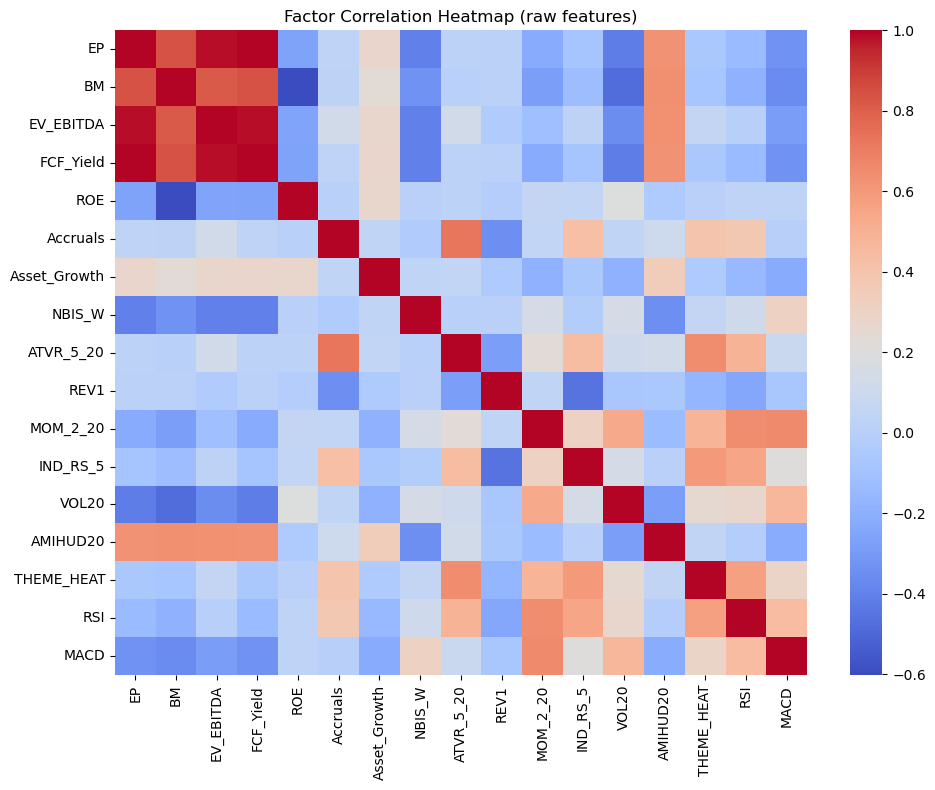

PCA降维后维度: 14


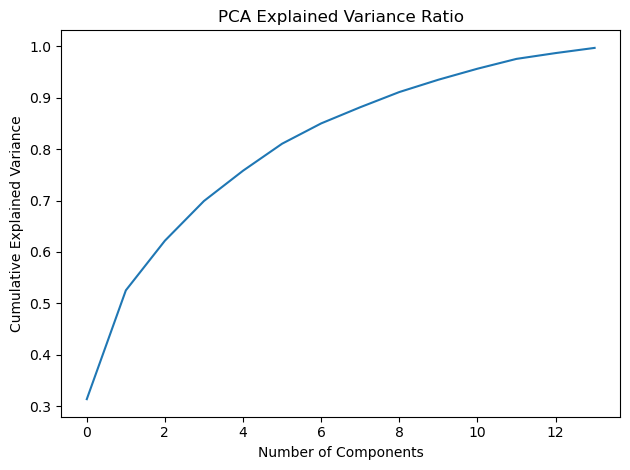

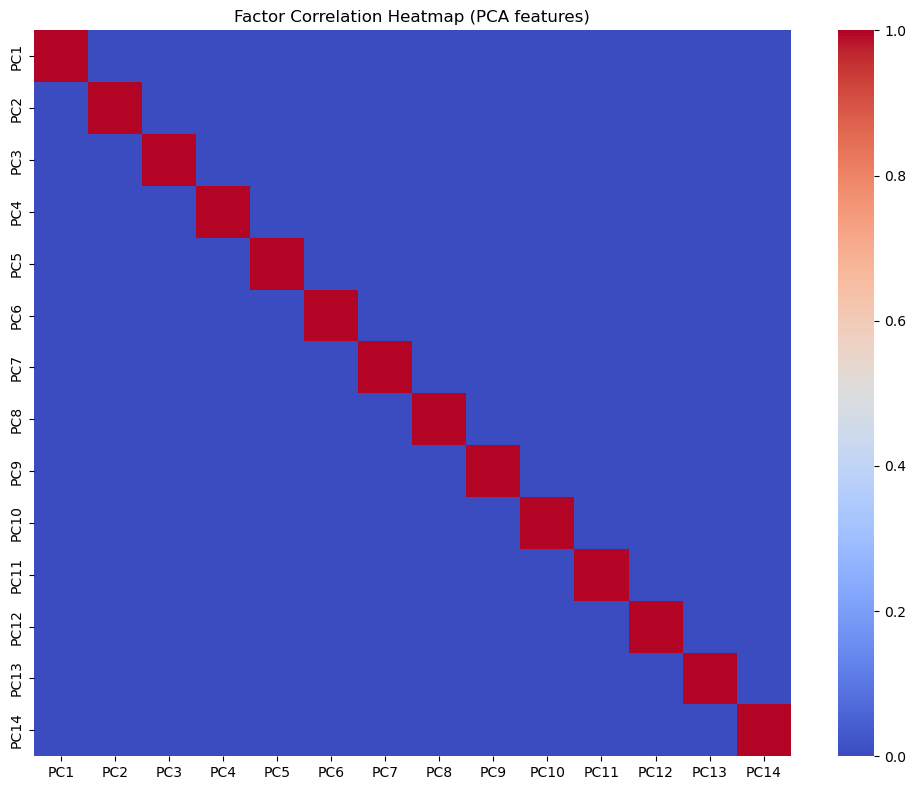

Epoch   0 | Train Loss 0.029313 | Valid R2 -3.6466 | RankIC 0.1435
Epoch  20 | Train Loss 0.012235 | Valid R2 -0.4190 | RankIC 0.1893
Epoch  40 | Train Loss 0.010424 | Valid R2 -0.1702 | RankIC 0.2924
Epoch  60 | Train Loss 0.009122 | Valid R2 -0.0303 | RankIC 0.3553
Epoch  80 | Train Loss 0.008076 | Valid R2 0.0429 | RankIC 0.3768
Epoch 100 | Train Loss 0.007694 | Valid R2 0.0817 | RankIC 0.3951
Epoch 120 | Train Loss 0.007743 | Valid R2 0.1051 | RankIC 0.3931
Epoch 140 | Train Loss 0.007538 | Valid R2 0.1232 | RankIC 0.4048
Epoch 160 | Train Loss 0.007452 | Valid R2 0.1340 | RankIC 0.4086
Epoch 180 | Train Loss 0.007203 | Valid R2 0.1406 | RankIC 0.4105
Epoch 200 | Train Loss 0.006633 | Valid R2 0.1542 | RankIC 0.4181
Epoch 220 | Train Loss 0.006984 | Valid R2 0.1592 | RankIC 0.4258
Epoch 240 | Train Loss 0.007183 | Valid R2 0.1629 | RankIC 0.4259
Epoch 260 | Train Loss 0.006875 | Valid R2 0.1678 | RankIC 0.4269
Epoch 280 | Train Loss 0.006541 | Valid R2 0.1685 | RankIC 0.4310
Epoch 

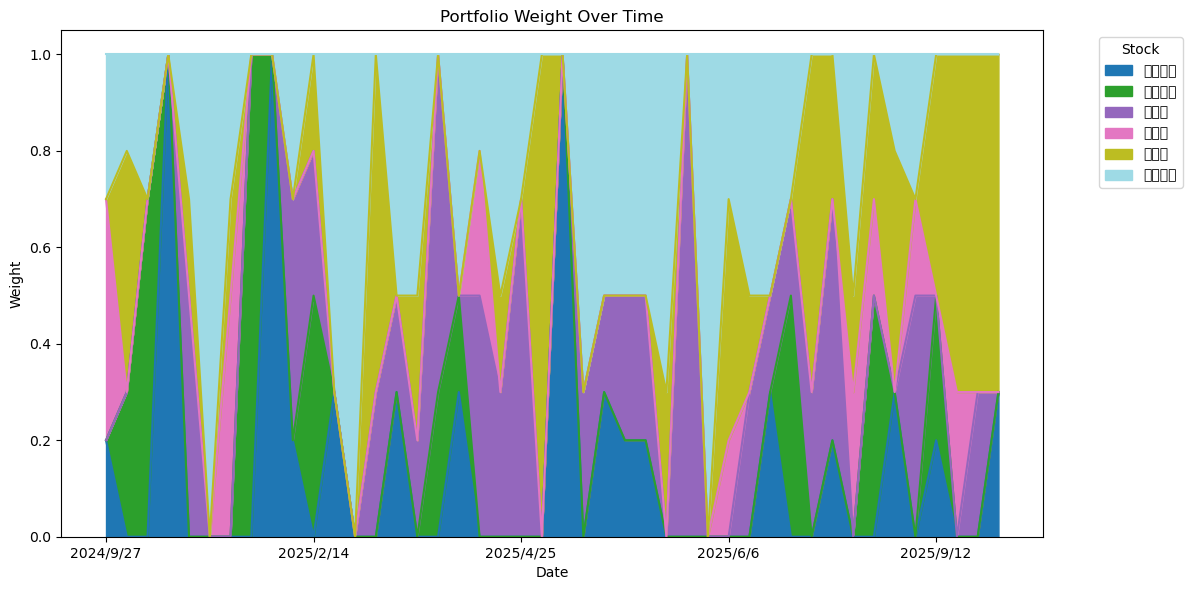

Annualized Return: 1666.93%
Max Drawdown: 22.71%
Sharpe Ratio: 4.70


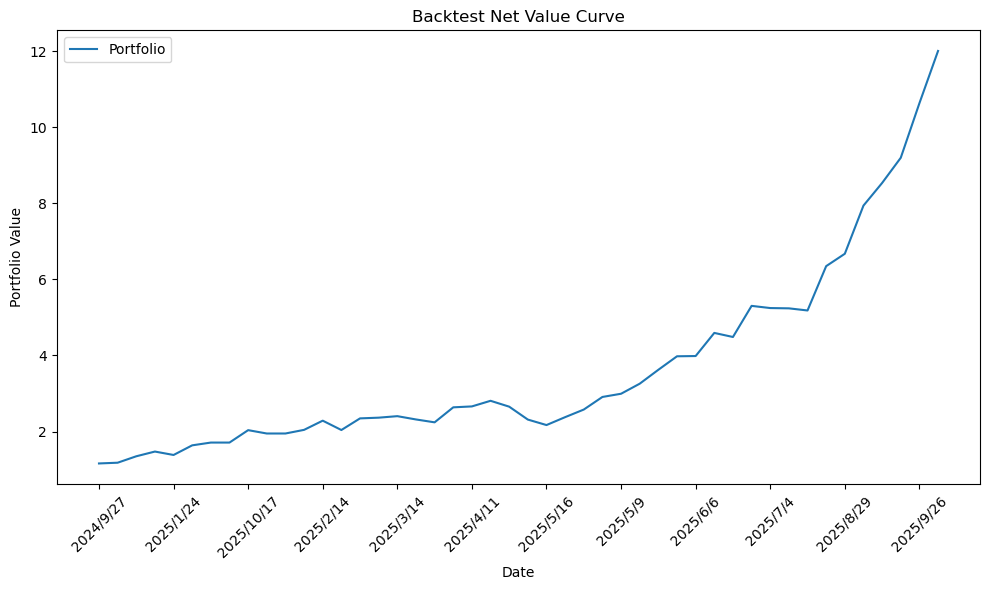


[Done] all outputs are saved：C:\Users\13105\for video\out_MLP


In [24]:
#%% md
# # Stock Price Prediction - MLP  (Path read from script directory + unify outputs to out_MLP)
warnings.filterwarnings('ignore')
plt.close('all')
print(torch.__version__)

# ---- Paths & output directory: same as script directory ----
ROOT = Path.cwd()
OUTDIR = ROOT / "out_MLP"
OUTDIR.mkdir(parents=True, exist_ok=True)

print(f"[PATH] ROOT  = {ROOT}")
print(f"[PATH] OUTDIR= {OUTDIR}")

#%% md
# ## Dataset Definition
#%%
class StockDataset(Dataset):
    def __init__(self, df, feature_cols, target_col):
        self.X = df[feature_cols].values.astype(np.float32)
        self.y = df[target_col].values.astype(np.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

#%% md
# ### Set computing device as CPU/GPU
#%%
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

#%% md
# ## Data loading and pre-processing (data file is in the same directory as the script)
#%%
# The data file is in the same directory as the script: MLP_data.csv
data_path = ROOT / "MLP_data.csv"
if not data_path.exists():
    raise FileNotFoundError(f"未找到数据文件：{data_path}")
df = pd.read_csv(data_path, header=0)

feature_cols = ['EP', 'BM', 'EV_EBITDA', 'FCF_Yield', 'ROE', 'Accruals', 'Asset_Growth', 'NBIS_W',
                'ATVR_5_20', 'REV1', 'MOM_2_20', 'IND_RS_5', 'VOL20', 'AMIHUD20', 'THEME_HEAT', 'RSI', 'MACD']

df = df.dropna(subset=['next_week_return'])

scaler = StandardScaler()
scaler.fit(df[feature_cols])
df[feature_cols] = scaler.transform(df[feature_cols])

# Factor correlation heatmap (saved to out_MLP)
plt.figure(figsize=(10,8))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Factor Correlation Heatmap (raw features)')
plt.tight_layout()
plt.savefig(OUTDIR / "corr_heatmap_raw.png", dpi=150)
plt.show()

# PCA dimensionality reduction and save visualization
pca = PCA(n_components=0.99)
X_pca = pca.fit_transform(df[feature_cols])
print(f"PCA降维后维度: {X_pca.shape[1]}")

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Ratio')
plt.tight_layout()
plt.savefig(OUTDIR / "pca_explained_variance.png", dpi=150)
plt.show()

feature_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=feature_cols)
df = pd.concat([df[['date', 'stock_code', 'next_week_return', *(['stock_name'] if 'stock_name' in df.columns else [])]], df_pca], axis=1)

# Factor correlation heatmap after PCA
plt.figure(figsize=(10,8))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Factor Correlation Heatmap (PCA features)')
plt.tight_layout()
plt.savefig(OUTDIR / "corr_heatmap_pca.png", dpi=150)
plt.show()

#%% md
# ## Split train/val/test (time-based split per stock)
#%%
train_list, val_list, test_list = [], [], []
for code, group in df.groupby('stock_code'):
    group = group.sort_values('date')
    train_part = group.iloc[:78]
    val_part   = group.iloc[78:111]
    test_part  = group.iloc[111:]
    train_list.append(train_part)
    val_list.append(val_part)
    test_list.append(test_part)

train_df = pd.concat(train_list, axis=0)
val_df   = pd.concat(val_list,   axis=0)
test_df  = pd.concat(test_list,  axis=0)

# Log split info
split_info = pd.DataFrame({
    "train_rows":[len(train_df)],
    "val_rows":[len(val_df)],
    "test_rows":[len(test_df)],
    "pca_dim":[len(feature_cols)]
})
split_info.to_csv(OUTDIR / "split_info.csv", index=False)

train_dataset = StockDataset(train_df, feature_cols, 'next_week_return')
val_dataset   = StockDataset(val_df,   feature_cols, 'next_week_return')
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader    = DataLoader(val_dataset, batch_size=32, shuffle=False)

#%% md
# ## Model
#%%
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 24),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(24, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.model(x)

model = MLP(len(feature_cols)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
criterion = nn.MSELoss()

#%% md
# ## Train (save the best RankIC model to out_MLP)
#%%
best_ic = -1
best_state = None
epochs = 600
log_rows = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    y_true, y_pred_list = [], []
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            y_hat = model(X_val)
            y_true.append(y_val.cpu().numpy())
            y_pred_list.append(y_hat.cpu().numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred_list)
    val_r2 = r2_score(y_true, y_pred)
    rank_ic, _ = spearmanr(y_true.flatten(), y_pred.flatten())

    log_rows.append({"epoch":epoch, "train_loss":train_loss, "val_r2":float(val_r2), "rank_ic":float(rank_ic)})

    if rank_ic > best_ic:
        best_ic = rank_ic
        best_state = model.state_dict()

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d} | Train Loss {train_loss:.6f} | Valid R2 {val_r2:.4f} | RankIC {rank_ic:.4f}')

# Save training log
pd.DataFrame(log_rows).to_csv(OUTDIR / "train_log.csv", index=False)

# Save the best model
torch.save(best_state, OUTDIR / 'best_model.pt')
print(f"Best validation RankIC: {best_ic:.4f}")

#%% md
# ## Backtest (save positions, charts, etc. to out_MLP)
#%%
def backtest(model, test_df, feature_cols, outdir: Path):
    outdir.mkdir(parents=True, exist_ok=True)
    model.eval()
    all_dates = sorted(test_df['date'].unique())
    portfolio_value = 1.0
    values = [1.0]
    dates_recorded = []
    positions = []
    empty_weeks = []

    has_stock_name = 'stock_name' in test_df.columns

    for date in all_dates:
        week_data = test_df[test_df['date'] == date].copy()
        X = torch.tensor(week_data[feature_cols].values, dtype=torch.float32).to(device)
        with torch.no_grad():
            preds = model(X).cpu().numpy().flatten()
        week_data['pred'] = preds

        week_data = week_data[week_data['pred'] > 0].sort_values('pred', ascending=False)

        if len(week_data) >= 3:
            weights = [0.5, 0.3, 0.2]
            week_data = week_data.iloc[:3].copy()
            week_data['w'] = weights
        elif len(week_data) == 2:
            week_data['w'] = [0.7, 0.3]
        elif len(week_data) == 1:
            week_data['w'] = [1.0]
        else:
            empty_weeks.append(date)
            values.append(portfolio_value)
            dates_recorded.append(date)
            continue

        for _, row in week_data.iterrows():
            positions.append({
                'date': date,
                'stock_code': row['stock_code'],
                'stock_name': row['stock_name'] if has_stock_name else row['stock_code'],
                'pred': row['pred'],
                'w': row['w'],
                'next_week_return': row['next_week_return']
            })

        week_ret = np.sum(week_data['next_week_return'].values * week_data['w'].values)
        portfolio_value *= (1 + week_ret)
        values.append(portfolio_value)
        dates_recorded.append(date)

    backtest_result = pd.DataFrame({'date': dates_recorded, 'net_value': values[1:]})
    positions_df = pd.DataFrame(positions)

    # Save positions and backtest curve
    positions_df.to_csv(outdir / 'positions_timeline.csv', index=False)
    backtest_result.to_csv(outdir / 'backtest_curve.csv', index=False)

    # Save empty-week info
    if empty_weeks:
        dd_series = (backtest_result['net_value'].cummax() - backtest_result['net_value']) / backtest_result['net_value'].cummax()
        dd_map = backtest_result.set_index('date')['net_value']
        pd.Series(empty_weeks, name="empty_weeks").to_csv(outdir / "empty_weeks.csv", index=False)

    # Portfolio weights area chart
    if not positions_df.empty:
        pivot = positions_df.pivot(index='date', columns='stock_name', values='w').fillna(0)
        ax = pivot.plot.area(figsize=(12,6), cmap='tab20')
        ax.set_title('Portfolio Weight Over Time')
        ax.set_xlabel('Date'); ax.set_ylabel('Weight')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Stock')
        plt.tight_layout()
        plt.savefig(outdir / "weights_area.png", dpi=150)
        plt.show()

    return backtest_result, positions_df

# Load the best model and run backtest
model.load_state_dict(torch.load(OUTDIR / 'best_model.pt', map_location=device))
backtest_result, positions_df = backtest(model, test_df, feature_cols, OUTDIR)

#%% md
# ## Performance summary (save metrics and NAV chart)
#%%
returns = backtest_result['net_value'].pct_change().dropna()
annual_ret = (backtest_result['net_value'].iloc[-1]) ** (52 / len(returns)) - 1 if len(returns) else np.nan
max_drawdown = ((backtest_result['net_value'].cummax() - backtest_result['net_value']) /
                backtest_result['net_value'].cummax()).max()
sharpe = (returns.mean() / returns.std() * np.sqrt(52)) if returns.std() else np.nan

print(f"Annualized Return: {annual_ret:.2%}")
print(f"Max Drawdown: {max_drawdown:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")

# Save performance metrics
pd.DataFrame([{
    "annual_return": annual_ret,
    "max_drawdown": max_drawdown,
    "sharpe": sharpe,
    "weeks": len(returns)+1
}]).to_csv(OUTDIR / "performance_summary.csv", index=False)

# Save NAV curve
plt.figure(figsize=(10,6))
plt.plot(backtest_result['date'], backtest_result['net_value'], label='Portfolio')
xticks = backtest_result['date'][::max(1, len(backtest_result)//10)]
plt.xticks(xticks, rotation=45)
plt.title('Backtest Net Value Curve')
plt.xlabel('Date'); plt.ylabel('Portfolio Value')
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "net_value_curve.png", dpi=150)
plt.show()

print(f"\n[Done] all outputs are saved：{OUTDIR}")


In [25]:
#%% md
# ## Export full test predictions (→ out_MLP/mlp_preds.csv)

# Use the trained PyTorch model to compute predictions for **all** rows in test_df
# and write a standardized CSV with columns: date, stock_code, pred[, actual].

# 1) Sanity checks
assert 'test_df' in globals(), "test_df is not defined."
assert 'feature_cols' in globals(), "feature_cols is not defined."
assert 'model' in globals(), "model is not defined."
OUTDIR.mkdir(parents=True, exist_ok=True)

# 2) Prepare features (drop rows with non-finite features)
df_pred = test_df.copy()
feat_mat = df_pred[feature_cols].apply(pd.to_numeric, errors="coerce").values
mask_ok = np.isfinite(feat_mat).all(axis=1)

n_total = len(df_pred)
n_kept  = int(mask_ok.sum())
if n_kept == 0:
    raise ValueError("No valid rows to predict: all rows contain NaN/Inf in features.")
if n_kept < n_total:
    print(f"[warn] Dropping {n_total - n_kept} rows with NaN/Inf features before prediction.")

X = torch.tensor(feat_mat[mask_ok], dtype=torch.float32).to(device)

# 3) Predict with the best model
model.eval()
with torch.no_grad():
    y_hat = model(X).cpu().numpy().reshape(-1)

# 4) Assemble output DataFrame
cols = ["date", "stock_code"]
need_cols = [c for c in cols if c in df_pred.columns]
if len(need_cols) < 2:
    raise KeyError(f"test_df must contain columns {cols}, found: {list(df_pred.columns)}")

out = df_pred.loc[mask_ok, need_cols].copy()
out["date"] = pd.to_datetime(out["date"], errors="coerce")
out["stock_code"] = out["stock_code"].astype(str)
out["pred"] = pd.to_numeric(y_hat, errors="coerce")

# Optional: include actual if present
if "next_week_return" in df_pred.columns:
    out["actual"] = pd.to_numeric(df_pred.loc[mask_ok, "next_week_return"], errors="coerce")

# 5) Clean, sort, save
out = out.dropna(subset=["date", "stock_code", "pred"]).sort_values(["date", "stock_code"])
save_path = OUTDIR / "mlp_preds.csv"
out.to_csv(save_path, index=False)
print(f"[export] Wrote {save_path} | rows={len(out)} | cols={list(out.columns)}")

# quick preview
display(out.head(8))


[warn] Dropping 5 rows with NaN/Inf features before prediction.
[export] Wrote C:\Users\13105\for video\out_MLP\mlp_preds.csv | rows=271 | cols=['date', 'stock_code', 'pred', 'actual']


,date,stock_code,pred,actual
96,2024-09-06,300308.0,-0.081313,0.152422
254,2024-09-06,300394.0,0.021906,0.079680
412,2024-09-06,300474.0,-0.033219,-0.037233
570,2024-09-06,300476.0,0.012266,0.032935
728,2024-09-06,300502.0,0.009151,0.123361
886,2024-09-06,301308.0,0.088827,-0.027324
99,2024-09-27,300308.0,0.020806,0.146734
257,2024-09-27,300394.0,-0.007830,0.151117



# Project 2 — Unified Forecasting Comparison & Backtesting (v2, Robust)

This version improves:
- **Smarter column detection** for prediction/actual fields in teammates' CSVs.
- **Helpful diagnostics** printing the detected columns and sample rows.
- **Benchmark fallback** now works from `data.csv` alone (equal-weight by date), even if no model loads.
- **Safe empty-summary handling** (no KeyError).
- **Optional per-model column overrides** if you want to be explicit.

**Place these files next to this notebook:**
- `pred_detail_test(Ridge).csv`
- `pred_detail_test(EN).csv`
- `MLP_data.csv` (truth: `date, stock_code, next_week_return`)
- *(optional)* `mlp_preds.csv`, `lasso_preds.csv`
- *(optional)* `bm_399006_weekly.csv` (`date,bm_ret`)

Run top-to-bottom.


In [26]:
# === Copy model output files into script folder (do NOT change your CONFIG) ===
import shutil
from pathlib import Path

BASE = Path.cwd()  # 脚本同目录

sources = {
    "pred_detail_test(Ridge).csv":  BASE / "out_ridge"        / "pred_detail_test(Ridge).csv",
    "pred_detail_test(EN).csv":     BASE / "reports_enet_all" / "pred_detail_test(EN).csv",
    "mlp_preds.csv":                BASE / "out_MLP"          / "mlp_preds.csv",  # 重命名为 CONFIG 里需要的 mlp_preds.csv
}

for target_name, src in sources.items():
    dst = BASE / target_name
    if not src.exists():
        print(f"[WARN] Missing source: {src}")
        continue
    # 若目标已存在则备份
    if dst.exists():
        bak = dst.with_suffix(dst.suffix + ".bak")
        shutil.move(dst, bak)
        print(f"[BACKUP] {dst.name} -> {bak.name}")
    shutil.copy2(src, dst)
    print(f"[COPY] {src} -> {dst}")

print("[DONE] Files are now in the script folder with names matching your CONFIG.")


[COPY] C:\Users\13105\for video\out_ridge\pred_detail_test(Ridge).csv -> C:\Users\13105\for video\pred_detail_test(Ridge).csv
[COPY] C:\Users\13105\for video\reports_enet_all\pred_detail_test(EN).csv -> C:\Users\13105\for video\pred_detail_test(EN).csv
[COPY] C:\Users\13105\for video\out_MLP\mlp_preds.csv -> C:\Users\13105\for video\mlp_preds.csv
[DONE] Files are now in the script folder with names matching your CONFIG.


In [27]:

# =========================
# 0) CONFIG
# =========================

MODEL_FILES = {
    "ridge":      "pred_detail_test(Ridge).csv",
    "elasticnet": "pred_detail_test(EN).csv",
    "mlp":      "mlp_preds.csv",
    # "lasso":    "lasso_preds.csv",
}

# Optional explicit per-model overrides (uncomment and fill if needed)
COLUMN_OVERRIDES = {
    # "ridge": {"date":"Date","stock_code":"ticker","pred":"yhat","actual":"next_week_return"},
    # "elasticnet": {"pred":"prediction"},
}

# Truth & benchmark
TRUTH_FILE   =  "factors_6stocks_weekly_20251107_013757.csv"
BENCHMARK_FN =  "bm_399006_weekly.csv"

COST_BPS     = 10
TOP_K        = 3
TOP_WEIGHTS  = np.array([0.5, 0.3, 0.2])
OUT_DIR      = Path("standardised_outputs"); OUT_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.figsize"] = (10,5)

# (Optional) resolve to Path objects if you load with Path later
MODEL_PATHS = {k: Path(v) for k, v in MODEL_FILES.items()}

print("[CONFIG] Models:", MODEL_FILES)
print("[CONFIG] Truth:", TRUTH_FILE)
print("[CONFIG] Benchmark:", BENCHMARK_FN)
print("[CONFIG] Out dir:", OUT_DIR.resolve())

[CONFIG] Models: {'ridge': 'pred_detail_test(Ridge).csv', 'elasticnet': 'pred_detail_test(EN).csv', 'mlp': 'mlp_preds.csv'}
[CONFIG] Truth: factors_6stocks_weekly_20251107_013757.csv
[CONFIG] Benchmark: bm_399006_weekly.csv
[CONFIG] Out dir: C:\Users\13105\for video\standardised_outputs


In [28]:

# =========================
# 1) LOADERS (robust detection)
# =========================
NUMERIC_PRED_HINTS = [
    "pred","yhat","prediction","forecast","score","signal",
    "ret_pred","pred_ret","next_week_pred","next_ret_pred",
    "proba_up","prob_up","proba","prob"
]
NUMERIC_ACTUAL_HINTS = [
    "actual","next_week_return","label","target","y","ret","next_ret","future_ret","realized","realised"
]

def _first_match(cols_map, candidates):
    for c in candidates:
        if c in cols_map:
            return cols_map[c]
    return None

def _best_numeric_guess(df, exclude):
    for c in df.columns:
        if c in exclude:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            return c
    return None

def read_truth(path=TRUTH_FILE):
    t = pd.read_csv(path)
    cmap = {c.lower(): c for c in t.columns}
    if "date" not in cmap or ("stock_code" not in cmap and "ticker" not in cmap):
        raise ValueError("[truth] Need columns like date, stock_code/ticker, next_week_return")
    date_col = cmap.get("date","date")
    code_col = cmap.get("stock_code") or cmap.get("ticker")
    act_col = _first_match(cmap, NUMERIC_ACTUAL_HINTS)
    if act_col is None:
        raise ValueError("[truth] Could not find actual/next_week_return column in truth file")
    t[date_col] = pd.to_datetime(t[date_col])
    t = t.rename(columns={date_col:"date", code_col:"stock_code", act_col:"actual"})
    return t[["date","stock_code","actual"]]

def load_model_csv(fname, model_key, truth_df=None, overrides=None):
    df = pd.read_csv(fname)
    print(f"\n--- Inspecting {model_key} from {fname} ---")
    print("Columns:", list(df.columns))

    # apply overrides first
    if overrides:
        df = df.rename(columns=overrides)

    lcmap = {c.lower(): c for c in df.columns}

    date_col  = lcmap.get("date")
    code_col  = lcmap.get("stock_code") or lcmap.get("ticker")

    pred_col  = _first_match(lcmap, NUMERIC_PRED_HINTS)
    if pred_col is None:
        exclude = set([date_col, code_col])
        act_guess = _first_match(lcmap, NUMERIC_ACTUAL_HINTS)
        if act_guess: exclude.add(act_guess)
        pred_col = _best_numeric_guess(df, exclude)
        print(f"[{model_key}] heuristic pred guess -> {pred_col}")

    actual_col= _first_match(lcmap, NUMERIC_ACTUAL_HINTS)

    if date_col is None or code_col is None:
        raise ValueError(f"[{model_key}] Missing date/stock_code columns")
    if pred_col is None:
        raise ValueError(f"[{model_key}] Missing prediction column (tried hints and numeric guess).")

    df[date_col] = pd.to_datetime(df[date_col])
    out = df.rename(columns={date_col:"date", code_col:"stock_code", pred_col:"pred"})

    if any(k in pred_col.lower() for k in ["proba","prob"]):
        out["pred"] = out["pred"] - 0.5

    if actual_col is None:
        if truth_df is None or truth_df.empty:
            raise ValueError(f"[{model_key}] 'actual' missing and no truth file available to merge.")
        out = out.merge(truth_df, on=["date","stock_code"], how="left")
    else:
        out = out.rename(columns={actual_col:"actual"})

    out = out[["date","stock_code","pred","actual"]].dropna().sort_values(["date","stock_code"])
    out["model"] = model_key

    print(out.head(3))
    return out

def load_benchmark_from_file(path=BENCHMARK_FN):
    try:
        bm = pd.read_csv(path)
        bm["date"] = pd.to_datetime(bm["date"])
        return bm[["date","bm_ret"]].dropna().drop_duplicates("date").sort_values("date")
    except Exception:
        return pd.DataFrame(columns=["date","bm_ret"])

def build_eq_weight_benchmark_from_truth(truth_df):
    if truth_df is None or truth_df.empty:
        return pd.DataFrame(columns=["date","bm_ret"])
    tmp = (truth_df.groupby("date")["actual"].mean()
           .rename("bm_ret").reset_index())
    return tmp

In [29]:
# =========================
# 2) LOAD EVERYTHING — robust (auto-derive 'actual' if missing) + safe benchmark
# =========================

OUT_DIR = Path("./_out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- REQUIRED inputs you already configured earlier ----
# TRUTH_FILE: e.g. "data.csv" (ideally has: date, stock_code, actual)
# MODEL_FILES: dict like {"ridge":"pred_detail_test(Ridge).csv", "elasticnet":"...", "mlp":"mlp_preds.csv"}
# COLUMN_OVERRIDES: optional per-model overrides for columns
WEEK_END = "FRI"  # align truth to weekly if we have to derive returns

def _to_week_end(series_like):
    s = pd.to_datetime(series_like, errors="coerce")
    s = s.to_series(index=s) if isinstance(s, pd.DatetimeIndex) else s
    return s.dt.to_period(f"W-{WEEK_END}").dt.to_timestamp(how="end").dt.floor("D")

def _norm_codes(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.replace(r"[^\d]", "", regex=True)
    s = s.str.replace(r"^0+", "", regex=True)
    return s.where(s.eq(""), s.str.zfill(6))

PRICE_CANDIDATES = ["close_hfq","adj_close","close","price","px","px_close"]

def _derive_fwd_ret(df, date_col="date", code_col="stock_code", out_col="ret_fwd_1w"):
    df = df.copy()
    df[date_col]  = _to_week_end(df[date_col])
    df[code_col]  = _norm_codes(df[code_col])
    # if an actual/return exists, reuse it; else compute from price-like columns
    lc = {c.lower(): c for c in df.columns}
    if "actual" in df.columns:
        df[out_col] = pd.to_numeric(df["actual"], errors="coerce")
        return df
    price_cols = [c for c in ["close_hfq","adj_close","close","price","px","px_close"] if c in df.columns]
    if not price_cols:
        raise RuntimeError("No 'actual' and no price column found to derive forward returns.")
    px = price_cols[0]
    df = df.sort_values([code_col, date_col])
    pxv = pd.to_numeric(df[px], errors="coerce")
    df[out_col] = df.groupby(code_col)[px].apply(lambda s: pd.to_numeric(s, errors="coerce").shift(-1)/pd.to_numeric(s, errors="coerce") - 1.0).values
    return df

def read_truth(path):
    p = Path(path) if path else None
    if not p or not p.exists():
        print(f"[truth] Not found: {p if p else '(None)'} — continuing with empty truth.")
        return pd.DataFrame(columns=["date","stock_code","actual"])

    t = pd.read_csv(p)
    if t.empty:
        print("[truth] File is empty — continuing with empty truth.")
        return pd.DataFrame(columns=["date","stock_code","actual"])

    # normalize names
    lc = {c.lower(): c for c in t.columns}
    # find date & code columns
    date_col = lc.get("date")
    code_col = lc.get("stock_code") or lc.get("ticker") or lc.get("code")
    if not date_col or not code_col:
        # best-effort guess
        candidates_date = [c for c in t.columns if "date" in c.lower()]
        candidates_code = [c for c in t.columns if "code" in c.lower() or "ticker" in c.lower()]
        date_col = date_col or (candidates_date[0] if candidates_date else None)
        code_col = code_col or (candidates_code[0] if candidates_code else None)
    if not date_col or not code_col:
        print(f"[truth] No usable date/stock_code columns in {list(t.columns)} — using empty truth.")
        return pd.DataFrame(columns=["date","stock_code","actual"])

    # try to find target column directly
    actual_col = None
    for cand in ["actual","next_week_return","ret_next","ret","target","y","label"]:
        if cand in lc:
            actual_col = lc[cand]; break

    # base table
    base = t.rename(columns={date_col:"date", code_col:"stock_code"}).copy()

    # if missing target: try to derive using prices
    if actual_col is None:
        price_col = None
        for pc in ["close_hfq","close","adj_close","price","px","px_close"]:
            if pc in lc: price_col = lc[pc]; break

        if price_col is not None:
            # derive next-period weekly return per stock
            tmp = base[["date","stock_code", price_col]].dropna().copy()
            tmp["date"] = _to_week_end(tmp["date"])
            tmp["stock_code"] = _norm_codes(tmp["stock_code"])
            tmp = tmp.sort_values(["stock_code","date"])
            tmp["actual"] = tmp.groupby("stock_code")[price_col].apply(
                lambda s: s.shift(-1) / s - 1.0
            ).values
            truth = tmp[["date","stock_code","actual"]].dropna().drop_duplicates()
            print(f"[truth] Derived 'actual' from {price_col}: rows={len(truth)}")
            return truth

        print("[truth] No 'actual' and no price column to derive from — using empty truth.")
        return pd.DataFrame(columns=["date","stock_code","actual"])

    # we have target directly
    base = base.rename(columns={actual_col:"actual"})
    base = base[["date","stock_code","actual"]].copy()
    print(f"[truth] Loaded with explicit target: rows={len(base)}")
    return base

def load_model_csv(path, key, truth_df=None, overrides=None):
    df = pd.read_csv(path)
    cmap = {c.lower(): c for c in df.columns}
    # minimal columns: date, stock_code, pred
    date_col = overrides.get("date") if overrides else None
    code_col = overrides.get("code") if overrides else None
    pred_col = overrides.get("pred") if overrides else None

    if not date_col: date_col = cmap.get("date")
    if not code_col: code_col = cmap.get("stock_code") or cmap.get("ticker") or cmap.get("code")
    if not pred_col:
        for cand in ["pred","yhat","proba_up","score","signal"]:
            if cand in cmap: pred_col = cmap[cand]; break

    if not date_col or not code_col or not pred_col:
        raise RuntimeError(f"[{key}] Missing date/stock_code/pred. Columns: {list(df.columns)}")

    out = df.rename(columns={date_col:"date", code_col:"stock_code", pred_col:"pred"})[["date","stock_code","pred"]].copy()

    # if model file itself contains realized returns, keep them
    for cand in ["actual","next_week_return","ret_next","ret","target","y","label"]:
        if cand in cmap:
            out["actual"] = pd.to_numeric(df[cmap[cand]], errors="coerce")
            break

    return out

# ---- do the loads ----
truth = read_truth(globals().get("TRUTH_FILE", None))

pred_frames = {}
missing = []
for key, fn in MODEL_FILES.items():
    pth = Path(fn)
    if not pth.exists():
        print(f"[WARN] {key}: file not found -> {fn}")
        missing.append(key)
        continue
    try:
        overrides = COLUMN_OVERRIDES.get(key, None) if 'COLUMN_OVERRIDES' in globals() else None
        pred_frames[key] = load_model_csv(pth, key, truth_df=truth, overrides=overrides)
        print(f"[OK] Loaded {key}: {fn} -> {len(pred_frames[key])} rows")
    except Exception as e:
        print(f"[ERROR] {key}: {e}")

if missing:
    print("[WARN] Missing model files:", missing)

# ---- Benchmark (robust) ----
def load_benchmark_from_file(path_like):
    """Return DataFrame(date, bm_ret) from a CSV *file*.
    If path is missing, a directory, or unreadable, return empty DF and explain."""
    cols = ["date", "bm_ret"]
    empty = pd.DataFrame(columns=cols)
    try:
        if not path_like:
            print("[benchmark] No path provided → skip file.")
            return empty
        p = Path(path_like)
        if not p.exists():
            print(f"[benchmark] Not found: {p} → skip file.")
            return empty
        if not p.is_file():
            print(f"[benchmark] Path is not a file (likely a directory): {p} → skip file.")
            return empty

        b = pd.read_csv(p)
        lc = {c.lower(): c for c in b.columns}
        if {"date","bm_ret"}.issubset(lc):
            b = b.rename(columns={lc["date"]:"date", lc["bm_ret"]:"bm_ret"})
        else:
            # try common alternatives for return column
            date_col = lc.get("date")
            ret_col  = lc.get("ret") or lc.get("return") or lc.get("benchmark_ret") or lc.get("bmret")
            if not (date_col and ret_col):
                print(f"[benchmark] File lacks required columns. Found: {list(b.columns)} → skip file.")
                return empty
            b = b.rename(columns={date_col: "date", ret_col: "bm_ret"})
        out = b[["date","bm_ret"]].copy()
        print(f"[benchmark] Loaded from file: rows={len(out)}")
        return out
    except PermissionError:
        print(f"[benchmark] Permission denied reading: {path_like} → skip file.")
        return empty
    except Exception as e:
        print(f"[benchmark] Failed to load from file ({path_like}) → {e} → skip file.")
        return empty

def build_eq_weight_benchmark_from_truth(truth_df: pd.DataFrame) -> pd.DataFrame:
    """Equal-weight benchmark from truth: average 'actual' by date."""
    cols = ["date", "bm_ret"]
    if truth_df is None or truth_df.empty or "actual" not in truth_df.columns:
        print("[benchmark] Cannot build from truth (missing/empty or no 'actual').")
        return pd.DataFrame(columns=cols)
    tmp = truth_df.copy()
    tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce").dt.normalize()
    out = (tmp.dropna(subset=["date", "actual"])
               .groupby("date", as_index=False)["actual"].mean()
               .rename(columns={"actual": "bm_ret"}))
    print(f"[benchmark] Built equal-weight benchmark from truth: rows={len(out)}")
    return out[cols]

# Instantiate benchmark safely
bm_file = load_benchmark_from_file(globals().get("BENCHMARK_FN", None))
benchmark = bm_file if len(bm_file) else build_eq_weight_benchmark_from_truth(truth)
print(f"[INFO] Benchmark rows: {len(benchmark)}")

# -- 2.1.a PANEL with weekly forward return (ret_fwd_1w)
if isinstance(truth, pd.DataFrame) and not truth.empty:
    panel = truth.rename(columns={"actual": "ret_fwd_1w"}).copy()
    panel["date"] = _to_week_end(panel["date"])
    panel["stock_code"] = _norm_codes(panel["stock_code"])
else:
    # derive from any model CSVs if truth is empty
    if not pred_frames:
        raise RuntimeError("[2.1] No truth and no pred_frames to derive from.")
    cat = pd.concat(list(pred_frames.values()), ignore_index=True)
    # try to derive forward return from any price-like column
    panel = _derive_fwd_ret(cat, date_col="date", code_col="stock_code", out_col="ret_fwd_1w")[["date","stock_code","ret_fwd_1w"]]

# -- 2.1.b DATA MultiIndex (date, stock_code)
# join features from the richest pred_frame so models have inputs
if pred_frames:
    # pick the frame with the most columns
    richest_key = max(pred_frames, key=lambda k: pred_frames[k].shape[1])
    feats_df = pred_frames[richest_key].copy()
    feats_df["date"] = _to_week_end(feats_df["date"])
    feats_df["stock_code"] = _norm_codes(feats_df["stock_code"])
    # merge features onto panel
    panel_full = (panel.merge(feats_df.drop(columns=[c for c in ["pred","actual"] if c in feats_df.columns]),
                              on=["date","stock_code"], how="left"))
else:
    panel_full = panel.copy()

DATA = (
    panel_full
      .dropna(subset=["date","stock_code"])
      .set_index(["date","stock_code"])
      .sort_index()
)

# -- 2.1.c FEAT_COLS (with robust fallback if none exist)
preferred = ["EP","BM","EV_EBITDA","FCF_Yield","ROE","Accruals","Asset_Growth",
             "NBIS_W","ATVR_5_20","REV1","MOM_2_20","IND_RS_5","VOL20",
             "AMIHUD20","THEME_HEAT","RSI","MACD"]
FEAT_COLS = [c for c in preferred if c in DATA.columns]

if not FEAT_COLS:
    # === Fallback: engineer baseline features from ret_fwd_1w ===
    pf = (
        panel_full[["date","stock_code","ret_fwd_1w"]]
        .dropna(subset=["date","stock_code"])
        .sort_values(["stock_code","date"])
        .copy()
    )

    def _feat_from_rets(g: pd.DataFrame) -> pd.DataFrame:
        r = g["ret_fwd_1w"].astype(float)
        out = pd.DataFrame(index=g.index)
        # lags
        out["ret_lag1"] = r.shift(1)
        out["ret_lag2"] = r.shift(2)
        out["ret_lag4"] = r.shift(4)
        out["ret_lag12"] = r.shift(12)
        # rolling stats
        out["ret_ma4"]  = r.rolling(4, min_periods=2).mean()
        out["ret_ma12"] = r.rolling(12, min_periods=4).mean()
        out["ret_vol4"] = r.rolling(4, min_periods=2).std(ddof=1)
        out["ret_vol12"]= r.rolling(12, min_periods=4).std(ddof=1)
        # momentum proxy (compounded)
        out["mom4"]  = (1.0 + r).rolling(4,  min_periods=3).apply(lambda x: float(np.prod(x)) - 1.0, raw=True)
        out["mom12"] = (1.0 + r).rolling(12, min_periods=6).apply(lambda x: float(np.prod(x)) - 1.0, raw=True)
        # z-score of recent returns
        mu4  = r.rolling(4,  min_periods=2).mean()
        sd4  = r.rolling(4,  min_periods=2).std(ddof=1)
        out["z4"] = (r - mu4) / sd4.replace(0, np.nan)

        return out

    feats = (
        pf.groupby("stock_code", group_keys=False)
          .apply(_feat_from_rets)
          .reset_index(drop=True)
    )

    # stitch engineered features back
    engineered = pd.concat([pf[["date","stock_code"]], feats], axis=1)
    panel_full = (
        panel_full.merge(engineered, on=["date","stock_code"], how="left")
    )

    # rebuild DATA to include the new columns
    DATA = (
        panel_full
          .dropna(subset=["date","stock_code"])
          .set_index(["date","stock_code"])
          .sort_index()
    )

    # define FEAT_COLS = all newly created numeric columns (exclude target)
    numeric = DATA.select_dtypes(include=[np.number]).columns.tolist()
    FEAT_COLS = [c for c in numeric if c != "ret_fwd_1w"]

# -- 2.1.d BENCH_RET_1W (Series indexed by date)
if isinstance(benchmark, pd.DataFrame) and not benchmark.empty:
    b = benchmark.copy()
    b["date"] = _to_week_end(b["date"])
    BENCH_RET_1W = pd.Series(pd.to_numeric(b["bm_ret"], errors="coerce").values,
                              index=b["date"]).sort_index()
else:
    # equal-weight fallback from truth/panel
    BENCH_RET_1W = (DATA["ret_fwd_1w"]
                    .groupby(level=0)
                    .mean()
                    .sort_index())

# -- 2.1.e Sanity prints
_dates = sorted(set(DATA.index.get_level_values(0)))
print(f"[2.1] DATA shape: {DATA.shape}")
print(f"[2.1] Weeks: {len(_dates)} | Tickers: {DATA.index.get_level_values(1).nunique()}")
print(f"[2.1] FEAT_COLS ({len(FEAT_COLS)}): {FEAT_COLS[:8]}{' ...' if len(FEAT_COLS)>8 else ''}")
print(f"[2.1] BENCH_RET_1W rows: {len(BENCH_RET_1W)}")
assert DATA["ret_fwd_1w"].notna().any(), "[2.1] ret_fwd_1w all NaN — check price/actual derivation."
assert len(FEAT_COLS) > 0,            "[2.1] No features detected — check column names/types."

[truth] Derived 'actual' from close_hfq: rows=972
[OK] Loaded ridge: pred_detail_test(Ridge).csv -> 192 rows
[OK] Loaded elasticnet: pred_detail_test(EN).csv -> 192 rows
[OK] Loaded mlp: mlp_preds.csv -> 271 rows
[benchmark] File lacks required columns. Found: ['date', 'open', 'high', 'low', 'close', 'volume', 'bm_ret_week'] → skip file.
[benchmark] Built equal-weight benchmark from truth: rows=162
[INFO] Benchmark rows: 162
[2.1] DATA shape: (972, 12)
[2.1] Weeks: 162 | Tickers: 6
[2.1] FEAT_COLS (11): ['ret_lag1', 'ret_lag2', 'ret_lag4', 'ret_lag12', 'ret_ma4', 'ret_ma12', 'ret_vol4', 'ret_vol12'] ...
[2.1] BENCH_RET_1W rows: 162


[ridge] OOS periods: 109
[elasticnet] OOS periods: 109
[mlp] OOS periods: 109

=== Post-cost OOS Metrics (weekly→annualized) ===
            ann_return  ann_vol  sharpe  max_dd  avg_turnover
model                                                        
benchmark       0.9417   0.4953  1.9014     NaN           NaN
mlp             0.3906   0.5320  0.7343 -0.2958        1.2523
ridge           0.0966   0.4774  0.2023 -0.5190        1.2890
elasticnet      0.0868   0.4774  0.1817 -0.5286        1.2982


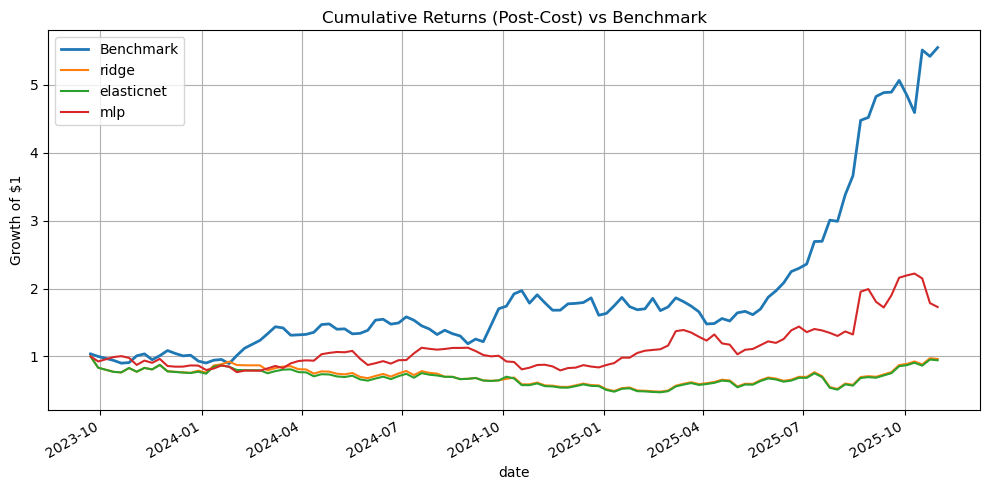

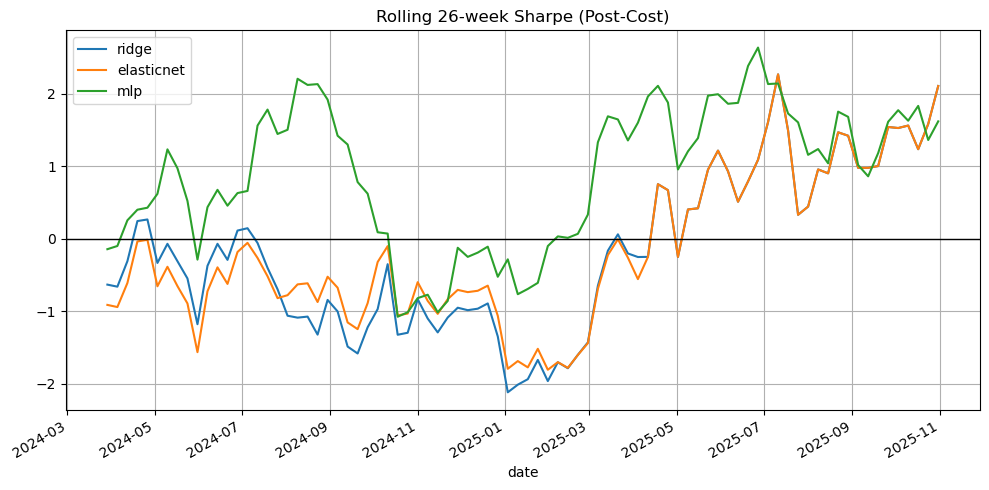

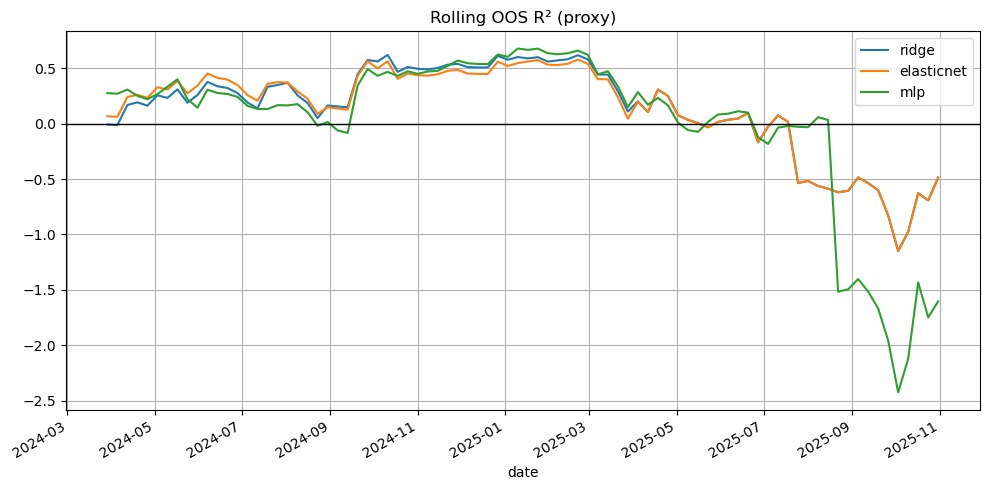

In [30]:
# =========================
# 3) WALK-FORWARD on DATA (ridge / elasticnet / mlp) — enhanced & separate WF outputs
# =========================

OUT_DIR = Path("./_out"); OUT_DIR.mkdir(parents=True, exist_ok=True)

WF_PRED_FILES = {
    "ridge":      str(OUT_DIR / "ridge_wf_preds.csv"),
    "elasticnet": str(OUT_DIR / "elasticnet_wf_preds.csv"),
    "mlp":        str(OUT_DIR / "mlp_wf_preds.csv"),
}
WF_NAV_FILES = {
    "ridge":      str(OUT_DIR / "ridge_wf_nav.csv"),
    "elasticnet": str(OUT_DIR / "elasticnet_wf_nav.csv"),
    "mlp":        str(OUT_DIR / "mlp_wf_nav.csv"),
}

# --- models ---
def _ridge():
    return RidgeCV(alphas=np.logspace(-4, 3, 20), fit_intercept=True)

def _elasticnet():
    return ElasticNetCV(
        l1_ratio=[0.1,0.3,0.5,0.7,0.9],
        alphas=np.logspace(-4,2,16),
        max_iter=20000
    )

def _mlp():
    return MLPRegressor(
        hidden_layer_sizes=(64,32),
        activation="relu",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=800,
        random_state=42
    )

ESTIMATORS = {"ridge": _ridge, "elasticnet": _elasticnet, "mlp": _mlp}

def make_nan_safe_pipeline(estimator_ctor):
    # Imputer + scaler fitted ONLY on each train window → no leakage
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler(with_mean=True)),
        ("model",   estimator_ctor()),
    ])

# --- helpers/metrics (same logic as your original) ---
def _zscore_safe(s: pd.Series) -> pd.Series:
    mu, sd = s.mean(), s.std(ddof=0)
    if sd is None or np.isnan(sd) or sd == 0:
        return pd.Series(0.0, index=s.index)
    return (s - mu) / sd

def annualize_mean(ret, periods=52):
    return periods * pd.Series(ret).mean()

def annualize_vol(ret, periods=52):
    return np.sqrt(periods) * pd.Series(ret).std(ddof=1)

def sharpe(ret, rf=0.0, periods=52):
    ex = pd.Series(ret) - rf
    vol = annualize_vol(ex, periods)
    if (vol is None) or (not np.isfinite(vol)) or vol <= 0:
        return np.nan
    return annualize_mean(ex, periods) / vol

def max_drawdown(cum):
    roll_max = cum.cummax()
    return (cum / roll_max - 1.0).min()

# --- walk-forward setup ---
WINDOW_T = 52          # training window (weeks)
ROUND_TRIP_BPS = 10    # 10 bps round-trip cost
dates = sorted(DATA.index.get_level_values(0).unique())

def run_walkforward_for_model(model_name: str):
    """Run expanding-window walk-forward, build L/S portfolio, save WF preds & NAV."""
    pipe = make_nan_safe_pipeline(ESTIMATORS[model_name])

    oos_rows  = []  # weekly portfolio results
    pred_rows = []  # per-stock predictions for standardized CSV
    prev_weights = None

    for i in range(WINDOW_T, len(dates)-1):
        train_dates = dates[i-WINDOW_T:i]
        test_date   = dates[i]
        exec_date   = dates[i+1]

        trn = DATA.loc[train_dates]
        tst = DATA.loc[test_date]

        # features/target
        Xtr_raw = trn[FEAT_COLS].replace([np.inf, -np.inf], np.nan)
        y_tr    = trn["ret_fwd_1w"].values

        # need at least some info in this window
        good_cols = Xtr_raw.columns[Xtr_raw.notna().sum() > 1]
        if len(good_cols) == 0:
            continue

        pipe.fit(Xtr_raw[good_cols].values, y_tr)

        # predict cross-section at t
        df_t = tst.reset_index().copy()  # has date + stock_code as columns (from MultiIndex)
        X_te = df_t[good_cols].replace([np.inf, -np.inf], np.nan).values
        yhat = pipe.predict(X_te)

        df_t["pred"] = yhat
        df_t["z"]    = _zscore_safe(df_t["pred"])

        # realize at t+1 (merge on stock_code)
        real = (
            DATA.xs(exec_date, level=0)[["ret_fwd_1w"]]
            .reset_index()
            .rename(columns={"ret_fwd_1w": "actual"})
        )
        df_t["stock_code"] = df_t["stock_code"].astype(str)
        real["stock_code"] = real["stock_code"].astype(str)
        df_t = df_t.merge(real[["stock_code","actual"]], on="stock_code", how="left")

        # record standardized per-stock preds (we set date explicitly -> no KeyError)
        pred_rows.append(pd.DataFrame({
            "date":       pd.to_datetime(test_date),
            "stock_code": df_t["stock_code"].astype(str).values,
            "pred":       df_t["pred"].values,
            "actual":     pd.to_numeric(df_t["actual"], errors="coerce").values,
        }))

        # long/short: top 30% / bottom 30%
        qL, qS   = df_t["z"].quantile(0.70), df_t["z"].quantile(0.30)
        longs    = df_t["z"] >= qL
        shorts   = df_t["z"] <= qS
        nL, nS   = max(int(longs.sum()), 1), max(int(shorts.sum()), 1)

        df_t["w"] = 0.0
        df_t.loc[longs,  "w"] =  1.0 / nL
        df_t.loc[shorts, "w"] = -1.0 / nS

        # turnover & cost
        realized = pd.to_numeric(df_t["actual"], errors="coerce").fillna(0.0)
        if prev_weights is None:
            turnover, cost = 0.0, 0.0
        else:
            aligned = prev_weights.join(df_t.set_index("stock_code")[["w"]], how="outer").fillna(0.0)
            turnover = np.abs(aligned["w_prev"] - aligned["w"]).sum() / 2.0
            cost = (ROUND_TRIP_BPS / 10000.0) * turnover

        port_ret = float((df_t["w"] * realized).sum() - cost)
        oos_rows.append({"date": exec_date, "port_ret": port_ret, "turnover": turnover})

        prev_weights = df_t.set_index("stock_code")[["w"]].rename(columns={"w": "w_prev"})

    if not oos_rows:
        raise RuntimeError(f"[{model_name}] produced no OOS rows.")

    # ----- OOS time series (weekly) -----
    oos = pd.DataFrame(oos_rows).set_index("date").sort_index()
    oos["bench_ret"] = BENCH_RET_1W.reindex(oos.index).astype(float)
    oos["cum"]   = (1 + oos["port_ret"]).cumprod()
    oos["cum_b"] = (1 + oos["bench_ret"]).cumprod()

    # ----- STANDARD WF OUTPUTS for later sections -----
    preds_df = pd.concat(pred_rows, ignore_index=True).sort_values(["date","stock_code"])
    preds_df.to_csv(WF_PRED_FILES[model_name], index=False)

    nav_df = oos.reset_index()[["date","port_ret"]].copy()
    nav_df["nav"] = (1 + nav_df["port_ret"]).cumprod()
    nav_df.rename(columns={"port_ret": "ret"}, inplace=True)
    nav_df.to_csv(WF_NAV_FILES[model_name], index=False)

    return oos, preds_df

# --- run models ---
oos_by   = {}
preds_by = {}
for name in ["ridge","elasticnet","mlp"]:
    try:
        oos, preds_df = run_walkforward_for_model(name)
        oos_by[name]   = oos
        preds_by[name] = preds_df
        print(f"[{name}] OOS periods: {len(oos_by[name])}")
    except Exception as e:
        print(f"[{name}] skipped: {e}")

# --- metrics ---
rows = []
for name, df in oos_by.items():
    mu   = annualize_mean(df["port_ret"])
    sig  = annualize_vol(df["port_ret"])
    sr   = sharpe(df["port_ret"])
    mdd  = max_drawdown(df["cum"])
    to   = df["turnover"].mean()
    rows.append([name, mu, sig, sr, mdd, to])

metrics_df = pd.DataFrame(
    rows,
    columns=["model","ann_return","ann_vol","sharpe","max_dd","avg_turnover"]
).set_index("model")

print("\n=== Post-cost OOS Metrics (weekly→annualized) ===")
if len(metrics_df):
    # add benchmark row aligned to any model’s index
    idx0  = next(iter(oos_by.values())).index
    bench = BENCH_RET_1W.reindex(idx0).dropna()
    mu_b, sig_b, sr_b = annualize_mean(bench), annualize_vol(bench), sharpe(bench)
    metrics_df.loc["benchmark", ["ann_return","ann_vol","sharpe"]] = [mu_b, sig_b, sr_b]
    print(metrics_df.sort_values("sharpe", ascending=False).to_string(float_format=lambda x: f"{x:.4f}"))
else:
    print("[empty] No models produced OOS results.")

# Expose WF preds to Step 4 via pred_frames (in memory ONLY; no touching MODEL_FILES)
if "pred_frames" not in globals():
    pred_frames = {}
for k, dfp in preds_by.items():
    pred_frames[k] = dfp[["date","stock_code","pred","actual"]].copy()

# --- plots (guarded) ---
if len(oos_by) > 0:
    # cumulative
    idx0 = next(iter(oos_by.values())).index
    fig, ax = plt.subplots()
    (1.0 + BENCH_RET_1W.reindex(idx0).fillna(0)).cumprod().plot(
        ax=ax, label="Benchmark", linewidth=2
    )
    for name, df in oos_by.items():
        df["cum"].plot(ax=ax, label=f"{name}")
    ax.set_title("Cumulative Returns (Post-Cost) vs Benchmark")
    ax.set_ylabel("Growth of $1")
    ax.legend(loc="best"); ax.grid(True); plt.tight_layout()

    # rolling sharpe
    win = 26
    fig, ax = plt.subplots()
    for name, df in oos_by.items():
        roll_sr = df["port_ret"].rolling(win).apply(
            lambda x: sharpe(pd.Series(x).dropna()), raw=False
        )
        roll_sr.plot(ax=ax, label=f"{name}")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Rolling 26-week Sharpe (Post-Cost)")
    ax.legend(loc="best"); ax.grid(True); plt.tight_layout()

    # rolling R² proxy
    fig, ax = plt.subplots()
    for name, df in oos_by.items():
        num = df["port_ret"].rolling(win).apply(
            lambda x: ((x - x.mean())**2).sum(), raw=True
        )
        den = df["bench_ret"].rolling(win).apply(
            lambda x: ((x - x.mean())**2).sum(), raw=True
        )
        (1 - (num/den)).plot(ax=ax, label=f"{name}")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Rolling OOS R² (proxy)")
    ax.legend(loc="best"); ax.grid(True); plt.tight_layout()
else:
    print("[plot] Skipped plots — no OOS results.")

[4] TRUTH rows=972 | used_price_col=None
[INFO] Models: ['ridge', 'elasticnet', 'mlp']
[DIAG] ridge: {'rows': 654, 'dates': 109, 'tickers': 6, 'has_actual': True, 'pred_unique_max': 6}
[DIAG] elasticnet: {'rows': 654, 'dates': 109, 'tickers': 6, 'has_actual': True, 'pred_unique_max': 6}
[DIAG] mlp: {'rows': 654, 'dates': 109, 'tickers': 6, 'has_actual': True, 'pred_unique_max': 6}


,model,weeks,ann_return,ann_vol,sharpe,max_dd,hit_rate,mean_rankIC,turn_events,alpha_ann,IR,TE_ann,status
1,elasticnet,NaN,5.5765,0.5287,10.5477,-0.0345,0.9541,0.7803,142.5,4.6053,8.3850,0.5492,backtested
2,mlp,NaN,3.7311,0.5765,6.4721,-0.1108,0.8440,0.4506,137.5,2.7599,4.7223,0.5844,backtested
0,ridge,NaN,5.5673,0.5289,10.5253,-0.0345,0.9541,0.7819,141.5,4.5961,8.3421,0.5510,backtested


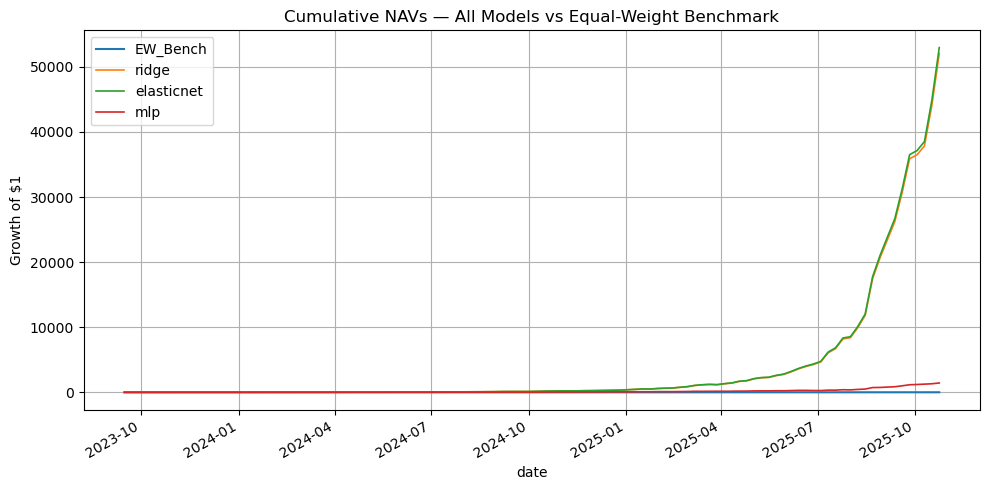

In [31]:
# =========================
# STEP 4 — UNIFIED (Build ACTUAL → Backtest all models → Benchmark → Summary → Plots)
# =========================

# ----- Tunables -----
WEEK_END     = "FRI"     # align to week end
PRICE_CANDIDATES = ["close_hfq","adj_close","close","price","px","px_close"]
TOP_PCT      = 0.30      # top 30% long
BOT_PCT      = 0.30      # bottom 30% short
ROUND_TRIP_BPS = 10      # transaction cost
PER_YEAR     = 52        # weekly
OUT_DIR      = Path("./_out"); OUT_DIR.mkdir(parents=True, exist_ok=True)

# ----- Helpers -----
def _to_week_end(series_like):
    s = pd.to_datetime(series_like, errors="coerce")
    s = s.to_series(index=s) if isinstance(s, pd.DatetimeIndex) else s
    return s.dt.to_period(f"W-{WEEK_END}").dt.to_timestamp(how="end").dt.floor("D")

def _norm_codes(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.replace(r"[^\d]", "", regex=True)
    s = s.str.replace(r"^0+", "", regex=True)
    return s.where(s.eq(""), s.str.zfill(6))

def _derive_actual_from_price(df, date_col="date", code_col="stock_code"):
    """Create 'actual' as next-week forward return from any price column present."""
    if df is None or df.empty:
        return df, None
    out = df.copy()
    out[date_col] = _to_week_end(out[date_col])
    out[code_col] = _norm_codes(out[code_col])
    px_col = next((c for c in PRICE_CANDIDATES if c in out.columns), None)
    if px_col is None:
        return out, None  # nothing to derive from
    out = out.sort_values([code_col, date_col]).reset_index(drop=True)
    out["__px__"] = pd.to_numeric(out[px_col], errors="coerce")
    # next-week forward return per stock
    out["actual"] = out.groupby(code_col)["__px__"].apply(lambda s: s.shift(-1) / s - 1.0).values
    out.drop(columns=["__px__"], inplace=True)
    return out, px_col

def _ann_mean(x): return PER_YEAR * np.nanmean(pd.Series(x))
def _ann_vol(x):
    x = pd.Series(x).dropna()
    if len(x) < 2: return np.nan
    return np.sqrt(PER_YEAR) * x.std(ddof=1)
def _sharpe(x):
    vol = _ann_vol(x)
    return (_ann_mean(x) / vol) if (vol and np.isfinite(vol) and vol>0) else np.nan
def _max_dd(cum):
    if len(cum) == 0: return np.nan
    roll = np.maximum.accumulate(cum)
    dd = cum/roll - 1.0
    return np.nanmin(dd)

def _rankIC_by_date(df: pd.DataFrame) -> float:
    """Mean cross-sectional rank-IC per date; guaranteed 1-D arrays to spearmanr."""
    ics = []
    for d, g in df.groupby("date", sort=True):
        p = pd.to_numeric(g["pred"], errors="coerce")
        a = pd.to_numeric(g["actual"], errors="coerce")
        mask = p.notna() & a.notna()
        if mask.sum() < 3: 
            continue
        pz = np.asarray(p[mask]).ravel()
        az = np.asarray(a[mask]).ravel()
        if np.unique(pz).size <= 1 or np.unique(az).size <= 1:
            continue
        try:
            ic = spearmanr(pz, az).correlation
            if np.isfinite(ic): ics.append(float(ic))
        except Exception:
            pass
    return float(np.nanmean(ics)) if ics else np.nan

def backtest_topbot(df: pd.DataFrame,
                    top_pct=TOP_PCT, bot_pct=BOT_PCT, round_trip_bps=ROUND_TRIP_BPS):
    """
    Long/short backtest using top/bottom quantiles of 'pred'.
    df must have: date, stock_code, pred, actual (weekly-aligned).
    """
    z = df.dropna(subset=["date","stock_code"]).copy()
    z["date"] = _to_week_end(z["date"])
    z["stock_code"] = _norm_codes(z["stock_code"])
    z["pred"] = pd.to_numeric(z["pred"], errors="coerce")
    z["actual"] = pd.to_numeric(z["actual"], errors="coerce")

    dates = sorted(z["date"].dropna().unique())
    rets, tos, hit = [], [], []
    prev_w = pd.Series(dtype=float)  # index = stock_code, values = weight

    for d in dates:
        g = z.loc[z["date"].eq(d), ["stock_code","pred","actual"]].dropna(subset=["pred","actual"])
        if g.empty:
            rets.append(np.nan); tos.append(0.0); hit.append(np.nan)
            prev_w = pd.Series(dtype=float); 
            continue

        qL = g["pred"].quantile(1.0 - top_pct)
        qS = g["pred"].quantile(bot_pct)
        idx_long  = g.index[g["pred"] >= qL]
        idx_short = g.index[g["pred"] <= qS]

        w_row = pd.Series(0.0, index=g.index, dtype=float)
        if len(idx_long):  w_row.loc[idx_long]  =  1.0 / len(idx_long)
        if len(idx_short): w_row.loc[idx_short] = -1.0 / len(idx_short)

        realized = g["actual"].values
        w_now = pd.Series(w_row.values, index=g["stock_code"].values, dtype=float)  # key by code
        aligned_prev = prev_w.reindex(w_now.index).fillna(0.0)

        turnover = float(np.abs(aligned_prev.values - w_now.values).sum() / 2.0)
        cost = (round_trip_bps / 10000.0) * turnover
        port_ret = float(np.dot(w_row.values, realized) - cost)

        rets.append(port_ret); tos.append(turnover); hit.append(port_ret > 0)
        prev_w = w_now.copy()

    rets = pd.Series(rets, index=pd.Index(dates, name="date"))
    nav  = (1 + rets.fillna(0.0)).cumprod()
    core = {
        "ann_return": _ann_mean(rets),
        "ann_vol": _ann_vol(rets),
        "sharpe": _sharpe(rets),
        "max_dd": _max_dd(nav.values),
        "hit_rate": float(np.nanmean(hit)),
        "mean_rankIC": _rankIC_by_date(z),
        "turn_events": float(np.nansum(tos)),
    }
    return nav, rets, core

def _diag_panel(k, p):
    d = {"rows": len(p),
         "dates": p["date"].nunique() if "date" in p else np.nan,
         "tickers": p["stock_code"].nunique() if "stock_code" in p else np.nan,
         "has_actual": ("actual" in p.columns and p["actual"].notna().any()),
         "pred_unique_max": p.groupby("date")["pred"].nunique().max() if "pred" in p else 0}
    print(f"[DIAG] {k}: {d}")
    return d

# ----- 4.1 Build TRUTH of realized returns -----
if "truth" in globals() and isinstance(truth, pd.DataFrame) and not truth.empty:
    t = truth.copy()
    t["date"] = _to_week_end(t["date"]); t["stock_code"] = _norm_codes(t["stock_code"])
    if ("actual" not in t.columns) or t["actual"].isna().all() or (pd.to_numeric(t["actual"], errors="coerce").abs().sum() == 0):
        t, used_px = _derive_actual_from_price(t)
    else:
        used_px = None
    _truth = t[["date","stock_code","actual"]].dropna(subset=["date","stock_code"])
else:
    # derive from price columns inside pred_frames if possible
    concat_pf = pd.concat([df.copy() for df in pred_frames.values()], ignore_index=True)
    concat_pf["date"] = _to_week_end(concat_pf["date"]); concat_pf["stock_code"] = _norm_codes(concat_pf["stock_code"])
    concat_pf, used_px = _derive_actual_from_price(concat_pf)
    _truth = concat_pf[["date","stock_code","actual"]].dropna(subset=["date","stock_code"])

print(f"[4] TRUTH rows={len(_truth)} | used_price_col={used_px}")

# ----- 4.2 Repair every model panel and backtest -----
summ_rows, navs_plot = [], {}
model_order = list(pred_frames.keys())
print("[INFO] Models:", model_order)

for key in model_order:
    df = pred_frames[key].copy()
    df["date"] = _to_week_end(df["date"]); df["stock_code"] = _norm_codes(df["stock_code"])

    # Make sure there's a single 'pred' column
    if "pred" not in df.columns:
        for alt in ["pred_x","pred_y","prediction","yhat"]:
            if alt in df.columns:
                df["pred"] = df[alt]; break
    df["pred"] = pd.to_numeric(df["pred"], errors="coerce")

    # Attach authoritative 'actual' from _truth
    df = df.merge(_truth, on=["date","stock_code"], how="left", suffixes=("","_truth"))
    if "actual_truth" in df.columns:
        df["actual"] = df["actual_truth"]; df.drop(columns=["actual_truth"], inplace=True)
    df["actual"] = pd.to_numeric(df["actual"], errors="coerce")

    _diag_panel(key, df)

    base = dict(model=key,
                weeks=df["date"].nunique(),
                ann_return=np.nan, ann_vol=np.nan, sharpe=np.nan, max_dd=np.nan,
                hit_rate=np.nan, mean_rankIC=np.nan, turn_events=np.nan,
                alpha_ann=np.nan, IR=np.nan, TE_ann=np.nan, status="ok")

    # Guards
    if "actual" not in df.columns or df["actual"].isna().all():
        base["status"] = "no_actual"; summ_rows.append(base)
        df.to_csv(OUT_DIR/f"{key}_pred_panel.csv", index=False); continue
    if df.groupby("date")["pred"].nunique().max() <= 1:
        base["status"] = "constant_pred"; summ_rows.append(base)
        df.to_csv(OUT_DIR/f"{key}_pred_panel.csv", index=False); continue

    # Backtest
    try:
        nav, rets, core = backtest_topbot(df)
        nav.index  = _to_week_end(nav.index); rets.index = _to_week_end(rets.index)

        # Equal-weight weekly benchmark from _truth
        bench = (_truth[_truth["date"].isin(rets.index)]
                 .groupby("date")["actual"].mean()
                 .reindex(rets.index)
                 .fillna(0.0))
        active = rets - bench
        te_ann = _ann_vol(active); alpha_ann = _ann_mean(active)
        ir = alpha_ann / te_ann if (te_ann and np.isfinite(te_ann) and te_ann>0) else np.nan

        row = {"model": key, **core,
               "alpha_ann": alpha_ann, "IR": ir, "TE_ann": te_ann,
               "status": "backtested"}
        summ_rows.append(row)

        navs_plot[key] = nav.sort_index()
        nav.to_frame("nav").to_csv(OUT_DIR/f"{key}_nav.csv")
        df.to_csv(OUT_DIR/f"{key}_pred_panel.csv", index=False)
    except Exception as e:
        print(f"[WARN] {key}: backtest failed → {e}")
        base["status"] = f"backtest_error: {e}"; summ_rows.append(base)
        df.to_csv(OUT_DIR/f"{key}_pred_panel.csv", index=False)

# ----- 4.3 Summary table -----
summary = pd.DataFrame(summ_rows)
cols = ["model","weeks","ann_return","ann_vol","sharpe","max_dd",
        "hit_rate","mean_rankIC","turn_events","alpha_ann","IR","TE_ann","status"]
for c in cols:
    if c not in summary.columns: summary[c] = np.nan
summary = summary[cols].sort_values("model")
summary.to_csv(OUT_DIR/"model_comparison_summary.csv", index=False)
display(summary.round(4))

# ----- 4.4 Plot cumulative NAVs for ALL models + EW benchmark -----
if len(navs_plot):
    # Build EW benchmark NAV from _truth on union of all dates we have
    all_dates = sorted(set().union(*[s.index for s in navs_plot.values()]))
    bench_ret = (_truth[_truth["date"].isin(all_dates)]
                 .groupby("date")["actual"].mean()
                 .reindex(all_dates)
                 .fillna(0.0))
    bench_nav = (1 + bench_ret).cumprod()
    bench_nav.name = "EW_Bench"

    fig, ax = plt.subplots()
    bench_nav.plot(ax=ax, linewidth=1.5)
    for k, nav in navs_plot.items():
        nav.reindex(bench_nav.index).plot(ax=ax, linewidth=1.2)
    ax.set_title("Cumulative NAVs — All Models vs Equal-Weight Benchmark")
    ax.set_ylabel("Growth of $1")
    ax.legend(["EW_Bench"] + list(navs_plot.keys()), loc="best")
    ax.grid(True)
    plt.tight_layout()
else:
    print("[PLOT] No NAVs to plot.")



[DIAGNOSTICS — model windows after daily-ffill]


,model,start,end,days,nan,included
0,BENCH,2022-09-02,2025-10-31,1156,0,True
1,ELASTICNET,2023-09-15,2025-10-24,771,0,True
2,MLP,2023-09-15,2025-10-24,771,0,True
3,RIDGE,2023-09-15,2025-10-24,771,0,True


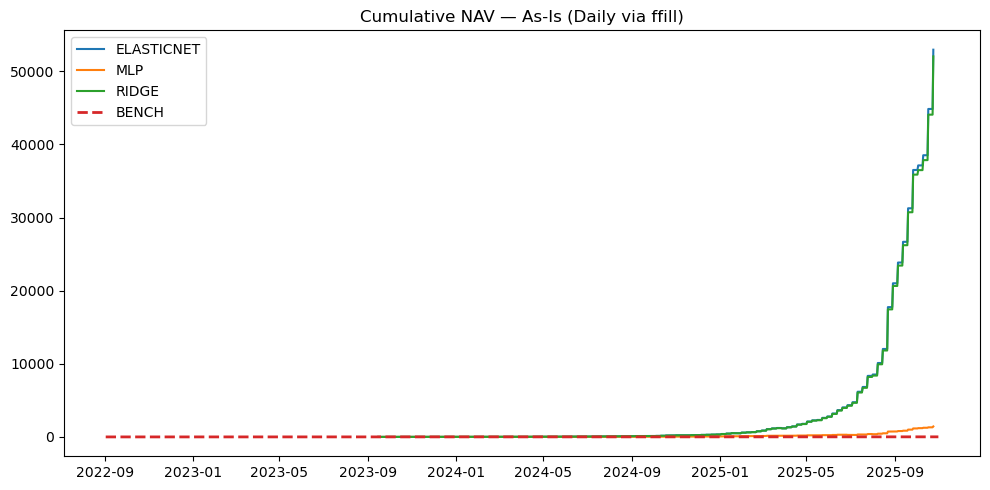

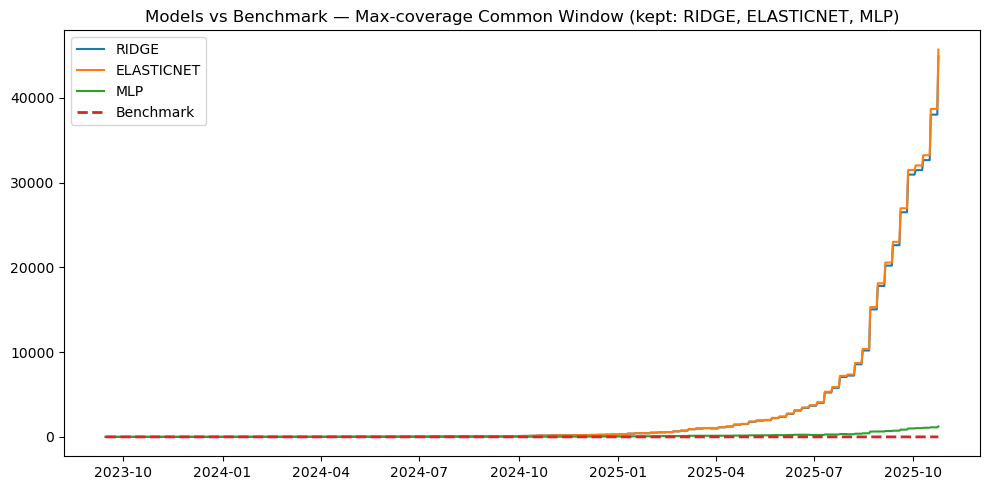

[Overlay diagnostics] All models kept.

[DATE WINDOWS — summary]


,model,start,end,days
0,BENCH,2022-09-02,2025-10-31,1156
1,ELASTICNET,2023-09-15,2025-10-24,771
2,MLP,2023-09-15,2025-10-24,771
3,RIDGE,2023-09-15,2025-10-24,771


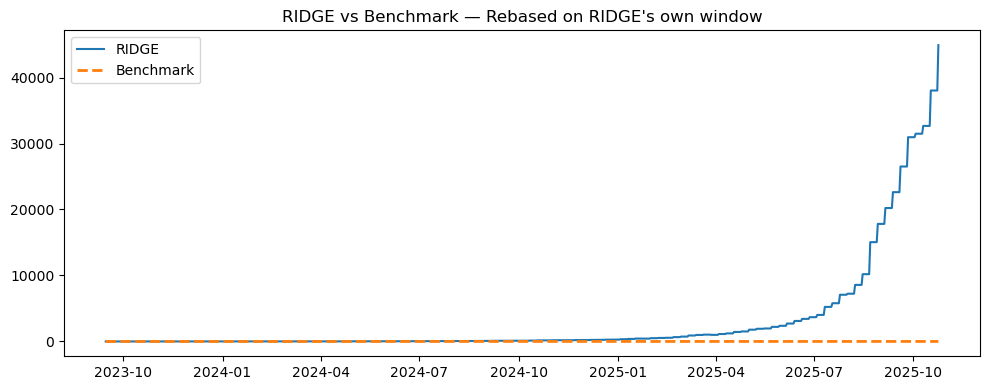

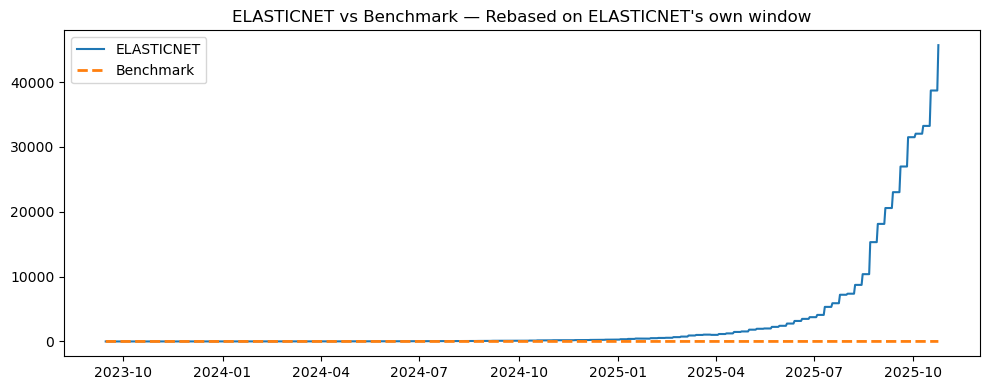

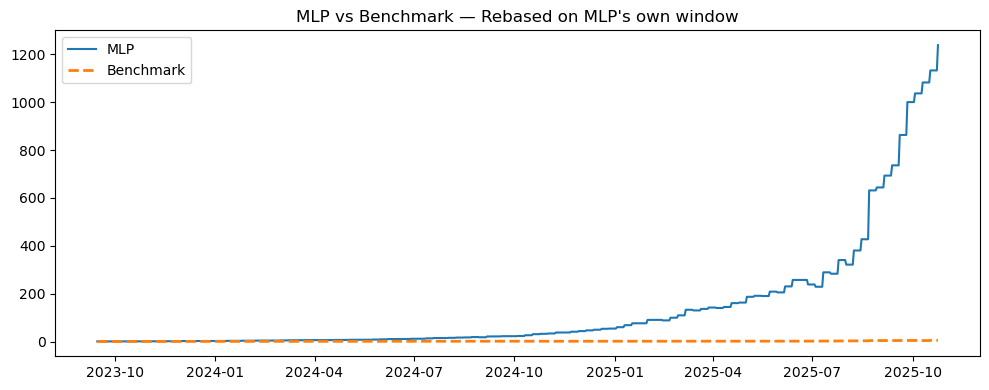

In [32]:
# =========================
# 5) PLOTS — robust loader, diagnostics, overlays (force-include MLP if possible)
# =========================

# ---------- helpers ----------
def _as_series(x):
    if x is None: return pd.Series(dtype=float)
    s = x.copy()
    if isinstance(s, pd.DataFrame):
        # pick first numeric column if index is date-like
        nc = [c for c in s.columns if pd.api.types.is_numeric_dtype(s[c])]
        if nc: s = s[nc[0]]
        else:  s = s.iloc[:,0]
    return s

def _to_daily(nav: pd.Series) -> pd.Series:
    s = _as_series(nav)
    if s.empty: return s
    s.index = pd.to_datetime(s.index, errors="coerce").floor("D")
    s = s[~s.index.isna()].sort_index()
    if s.empty: return s
    rng = pd.date_range(s.index.min(), s.index.max(), freq="D")
    s = s.reindex(rng).ffill()
    s.name = getattr(nav, "name", "NAV")
    return s

def _rebase(s: pd.Series) -> pd.Series:
    if s is None or len(s)==0: return s
    s = s.replace([np.inf,-np.inf], np.nan).dropna()
    if len(s)==0: return s
    return s / float(s.iloc[0])

def _build_bench_daily(benchmark_df):
    if benchmark_df is None or len(benchmark_df)==0: return pd.Series(dtype=float)
    b = benchmark_df.copy()
    if "date" not in b.columns or "bm_ret" not in b.columns: return pd.Series(dtype=float)
    b["date"] = pd.to_datetime(b["date"], errors="coerce").dt.floor("D")
    b = b.dropna(subset=["date","bm_ret"]).sort_values("date")
    if b.empty: return pd.Series(dtype=float)
    s = (1.0 + b.set_index("date")["bm_ret"].astype(float).fillna(0)).cumprod()
    s.name = "BENCH"
    return _to_daily(s)

def _span(s): 
    return (s.index.min(), s.index.max(), len(s), int(s.isna().sum()))

def _intersection_window(d):
    if not d: return (None, None)
    starts = [v.index.min() for v in d.values() if len(v)]
    ends   = [v.index.max() for v in d.values() if len(v)]
    if not starts or not ends: return (None, None)
    a, b = max(starts), min(ends)
    if a is None or b is None or not (a < b): return (None, None)
    return (a, b)

def _load_from_csv_if_missing(current):
    OUT = Path("./_out")
    mf = {
        "RIDGE": OUT/"ridge_preds.csv",
        "ELASTICNET": OUT/"elasticnet_preds.csv",
        "MLP": OUT/"mlp_preds.csv",
    }
    out = dict(current)
    for name, path in mf.items():
        if name in out and len(out[name]): 
            continue
        if not path.exists(): 
            continue
        try:
            df = pd.read_csv(path)
            # standardize
            if "date" not in df.columns:
                cand = [c for c in df.columns if c.lower() in ("dt","time","timestamp")]
                if cand: df = df.rename(columns={cand[0]:"date"})
            if "date" not in df.columns: 
                print(f"[CSV skip] {name}: no date column in {path.name}")
                continue
            df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.floor("D")
            df = df.dropna(subset=["date"]).sort_values("date")
            # prefer nav; else build from returns/preds
            nav_col = next((c for c in ["nav","cum_nav","cumret","cum_ret","cum_return"] if c in df.columns), None)
            if nav_col is None:
                ret_col = next((c for c in ["ret","strategy_ret","y_pred_ret","pred_ret","signal_ret","y_pred"] if c in df.columns), None)
                if ret_col is None:
                    print(f"[CSV skip] {name}: no nav/return column in {path.name}")
                    continue
                s = (1 + df[ret_col].astype(float).fillna(0)).cumprod()
            else:
                s = df[nav_col].astype(float)
            s.index = df["date"].values
            s.name = name
            out[name] = s
        except Exception as e:
            print(f"[CSV error] {name}: {e}")
    return out

# ---------- gather sources ----------
source = {}
if 'navs_plot' in globals() and navs_plot:
    source = {str(k).upper(): _as_series(v) for k,v in navs_plot.items() if v is not None}
elif 'bt_navs_cache' in globals() and bt_navs_cache:
    source = {str(k).upper(): _as_series(v) for k,v in bt_navs_cache.items() if v is not None}

# backfill from CSV for any missing model (esp. MLP)
source = _load_from_csv_if_missing(source)

# expand → daily & clean
daily = {k: _to_daily(v) for k,v in source.items()}
daily = {k: s for k,s in daily.items() if len(s)}

# benchmark
bench_nav = _build_bench_daily(benchmark if 'benchmark' in globals() else None)

# ---------- DIAGNOSTICS ----------
diag_rows = []
all_keys = sorted(set(list(daily.keys()) + (["MLP"] if "MLP" in source else [])))
for k in sorted(daily.keys()):
    a,b,L,nan = _span(daily[k])
    diag_rows.append({"model":k, "start":a, "end":b, "days":L, "nan":nan, "included":True})
for k in all_keys:
    if k not in daily:
        diag_rows.append({"model":k, "start":None, "end":None, "days":0, "nan":None, "included":False})
if bench_nav is not None and len(bench_nav):
    a,b,L,nan = _span(bench_nav)
    diag_rows.append({"model":"BENCH", "start":a, "end":b, "days":L, "nan":nan, "included":True})

diag = pd.DataFrame(diag_rows).sort_values(["included","model"], ascending=[False,True]).reset_index(drop=True)
print("\n[DIAGNOSTICS — model windows after daily-ffill]")
display(diag)

# ---------- (A) As-is lines (every model on its own span) ----------
if daily:
    plt.figure(figsize=(10,5))
    for k,s in sorted(daily.items()):
        plt.plot(s.index, s.values, label=k)
    if bench_nav is not None and len(bench_nav):
        plt.plot(bench_nav.index, bench_nav.values, "--", lw=2, label="BENCH")
    plt.title("Cumulative NAV — As-Is (Daily via ffill)"); plt.legend(); plt.tight_layout(); plt.show()

# ---------- (B) Common-window overlay — prefer subsets that INCLUDE MLP ----------
models = list(daily.keys())
best_subset, best_window, best_days = None, (None,None), -1

def _pick_best_subset(models, prefer="MLP"):
    best = None; best_w = (None,None); best_days = -1
    for r in range(len(models), 1, -1):
        for sub in combinations(models, r):
            if prefer in models and prefer not in sub:
                # skip subsets that exclude MLP when MLP exists
                continue
            start,end = _intersection_window({k:daily[k] for k in sub})
            if start is None: 
                continue
            days = (end-start).days
            if days > best_days:
                best, best_w, best_days = sub, (start,end), days
        if best is not None:
            break
    # if nothing with MLP worked, allow any subset
    if best is None:
        for r in range(len(models), 1, -1):
            for sub in combinations(models, r):
                start,end = _intersection_window({k:daily[k] for k in sub})
                if start is None: 
                    continue
                days = (end-start).days
                if days > best_days:
                    best, best_w, best_days = sub, (start,end), days
            if best is not None: break
    return best, best_w, best_days

best_subset, best_window, best_days = _pick_best_subset(models, prefer="MLP")

if best_subset is None:
    print("No overlapping window across any pair of models — cannot plot overlay.")
else:
    start_max, end_min = best_window
    idx = pd.date_range(start_max, end_min, freq="D")
    df = pd.DataFrame({k: daily[k].reindex(idx).ffill() for k in best_subset})
    # add benchmark only if it overlaps
    include_bench = bench_nav is not None and len(bench_nav) and \
                    (bench_nav.index.min() <= end_min) and (bench_nav.index.max() >= start_max)
    if include_bench:
        df["BENCH"] = bench_nav.reindex(idx).ffill()
    # rebase
    df = df.apply(_rebase)
    plt.figure(figsize=(10,5))
    for col in df.columns:
        if col == "BENCH":
            plt.plot(idx, df[col], "--", lw=2, label="Benchmark")
        else:
            plt.plot(idx, df[col], label=col)
    kept = ", ".join([c for c in df.columns if c != "BENCH"])
    plt.title(f"Models vs Benchmark — Max-coverage Common Window (kept: {kept})")
    plt.legend(); plt.tight_layout(); plt.show()

    dropped = [m for m in models if m not in best_subset]
    if dropped:
        print("[Overlay diagnostics] Dropped (no overlap with chosen window):", dropped)
    else:
        print("[Overlay diagnostics] All models kept.")

# ---------- (C) Per-model fair overlay vs benchmark ----------
rows = []
for k,s in daily.items():
    a,b,L,nan = _span(s); rows.append({"model":k, "start":a.date(), "end":b.date(), "days":L})
if bench_nav is not None and len(bench_nav):
    a,b,L,nan = _span(bench_nav); rows.append({"model":"BENCH","start":a.date(),"end":b.date(),"days":L})
print("\n[DATE WINDOWS — summary]")
display(pd.DataFrame(rows).sort_values("model").reset_index(drop=True))

for k,s in daily.items():
    idx = pd.date_range(s.index.min(), s.index.max(), freq="D")
    mline = _rebase(s.reindex(idx).ffill())
    plt.figure(figsize=(10,4))
    plt.plot(idx, mline, label=k)
    if bench_nav is not None and len(bench_nav):
        bseg = bench_nav.reindex(idx).ffill()
        if bseg.notna().any():
            plt.plot(idx, _rebase(bseg), "--", lw=2, label="Benchmark")
    plt.title(f"{k} vs Benchmark — Rebased on {k}'s own window"); plt.legend(); plt.tight_layout(); plt.show()
